In [2]:
import yfinance as yf
import numpy as np
import pandas as pd

import scipy.stats as stats

import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [3]:
# Codigo yfinance

# descarrgamos los precios históricos de las acciones utilizando yfinance

# nombre acciones 
# OMAB.MX, COST.MX, JNJ.MX, NFLX.MX, LIVERPOLC-1.MX, BABAN.MX, MEGACPO.MX, KOFUBL.MX, KIMBERA.MX, BIDUN.MX
nombre_acciones = ["GFNORTEO.MX", "WALMEX.MX", "GMEXICOB.MX", "CEMEXCPO.MX", "MSFT.MX", "AAPL.MX", "AMZN.MX", "GENTERA.MX", "GOOGL.MX", "NVDA.MX"]
#nombre_acciones = ["AAPL","MSFT","GOOGL","TSLA","AMZN"]
 
#Creamos una "cajita" para almacenar los datos
recolector = []
for nemo in nombre_acciones:
    #Obtenemos el ticker utilizando yfinance
    ticker = yf.Ticker(nemo)
    
    #Obtenemos los datos/precio de cierre a 2 años
    px = ticker.history(start = "2024-05-07", end="2026-05-07")["Close"]
    px.name = nemo
    #Agregamos a la "lista"
    recolector.append(px)

precios = pd.concat(recolector, axis=1)

precios = precios.ffill()

### Informacion inicial del portafolio

In [4]:
# Cuanto vamos a invertir
monto_inversion = 1_000_000
# Cambiamos formato
monto_inversion2= "${:,.2f}".format(monto_inversion)

# "${:,.2f}" --> Define como vamos a "presentar" nuestro numero
# --> $/% simbolo (fuera de las llaves)
#{:} --> introduce/inicia el formato
# , --> separar por miles
# .2f --> 2f, 3f ...num de decimales que quiero mostrar

# Nivel de confianza

nivel_de_confianza = 95
nivel_de_confianza_porcentaje = "{:.0f}%".format(nivel_de_confianza)


#precio actual
#regresa el ultimo valor de nuestro DataFrame
precio_activos = precios.iloc[-1]

#.iloc --> selecciona filas y columnas (empezamos desde cero)

# si "K" es un num de fila y "r" es el num de la columna r
# .iloc[k,r] --> valor fila k y columna r
# .iloc[:,r] --> columna r
# .iloc[k , :] --> fila k

# .loc[:15, :3] --> las primeras 15 filas y las primeras 3 columnas
# .iloc[17:n , :3] --> todas las filas desde la poss 17 hasta el final de las 3 primeras columnas
precio_activos

#Cambiemos el formato
precio_activos_dinero = precio_activos.apply("${:,.2f}".format)

alpha = 1 - (nivel_de_confianza / 100)

z_alpha = stats.norm.ppf(alpha)


### Rendimientos Ln()

In [5]:
rendimientos = np.log(precios).diff().dropna()
# numero de dias cotizados y num de activos
num_filas = len(rendimientos.axes[0]) # --> Num de dias cotizados
num_columnas = len(rendimientos.axes[1]) # --> Num de activos

## Matriz principal

In [6]:
# matriz principal 
matriz_var_principal = np.cov(rendimientos, y = None, rowvar = 0, bias = False, ddof = None)

# y = None --> no hay una segunda matriz
# rowvar = 0 --> cada columna es una variable, cada fila es una observación
# bias = False --> normalización por n-1 (muestra)
# ddof = None --> grados de libertad (default es 0, pero para muestra se recomienda usar n-1)

## Pesos del portafolio seleccionado

In [7]:
# pesos del portafolio de mínimo riesgo (MR) a fecha 08/05/26

wi = np.array([
    0.10381276513881546,
    0.22999291617379863,
    0.055014784089853774,
    0.05137316220227757,
    0.28036824233618607,
    0.1317095477058898,
    -0.010536418190877573,
    0.07664729394956345,
    0.12626430271620323,
    -0.04464659612171062
], dtype=float)

# Información de los activos

In [8]:
# obtenemos el promedio
esperanza_activos = rendimientos.mean()
# lo convertimos a porcentaje
esperanza_activos_porcentaje = esperanza_activos * 100
esperanza_activos_porcentaje = esperanza_activos_porcentaje.apply('{:.5f}%'.format)

# riesgo del activo
riesgo_activos = rendimientos.std(ddof=1)
# sacamos la desviación estándar
# ddof=1 --- desv est muestral
# ddof=0 --- desv est poblacional
# lo convertimos en porcentaje
riesgo_activos_porcentaje = riesgo_activos * 100
riesgo_activos_porcentaje = riesgo_activos_porcentaje.apply('{:.5f}%'.format)

# Monto asignado a cada activo
asignacion_activos = abs(wi * monto_inversion)
asignacion_activos_dinero = ['${:,.2f}'.format(i) for i in asignacion_activos]

# posición de los activos
posicion_activos = np.floor(asignacion_activos / precio_activos)

# valuación de los activos
valuacion_activos = posicion_activos * precio_activos
valuacion_activos_dinero = ['${:,.2f}'.format(i) for i in valuacion_activos]

# Información del portafolio

In [9]:
# vemos el rendimiento del portafolio seleccionado
esp_port = wi @ esperanza_activos
# lo convertimos a porcentaje
esp_port_porcentaje = esp_port * 100
esp_port_porcentaje = '{:.5f}%'.format(esp_port_porcentaje)

# vemos el riesgo del portafolio seleccionado
riesgo_port = np.sqrt(wi @ matriz_var_principal @ wi)
# lo convertimos a porcentaje
riesgo_port_porcentaje = riesgo_port * 100
riesgo_port_porcentaje = '{:.5f}%'.format(riesgo_port_porcentaje)

# pos y val del portafolio respecto a los wi anteriores

# Posición del portafolio
posicion_port = sum(posicion_activos)

# valuación del portafolio
valuacion_port = sum(posicion_activos * precio_activos)
valuacion_port_dinero = '${:,.2f}'.format(valuacion_port)

In [10]:
valuacion_port_dinero, esp_port*252, riesgo_port*np.sqrt(252)

('$1,099,460.04',
 np.float64(0.13639815302871594),
 np.float64(0.1462366562724974))

In [11]:
riesgo_port*100

np.float64(0.9212043453777664)

# P&L y Valuación del portafolio

In [12]:
# Obtenemos el profit loss del portafolio
# Obtenemos la Val de los activos

PnL_port = rendimientos @ wi

In [13]:
# calculamos la Val de los activos

valuacion_historica_activos = valuacion_activos * rendimientos

# calculamos la Val del port
valuacion_historica_port = valuacion_port * PnL_port

# cambiamos el nombre de la columna de val del port
valuacion_historica_port = valuacion_historica_port.rename("Portafolio")

# Concatemaos y obtenemos un DataFrame
df_valuacion_historica = pd.concat([valuacion_historica_activos, valuacion_historica_port], axis=1)

# Valores atípicos de la valuación histórica

In [14]:
#son los puntos que difieren sustancialmente de los demás
# 1) datos < Q1 - 1.5 * IQR
# 2) datos > Q3 + 1.5 * IQR


# Calculamos los componentes del Rango Intercuartílico (IQR)
Q1_activos = valuacion_historica_activos.quantile(0.25)
Q3_activos = valuacion_historica_activos.quantile(0.75)
IQR_activos = Q3_activos - Q1_activos

# Definimos los límites inferior y superior
limite_inferior_activos = Q1_activos - 3 * IQR_activos
limite_superior_activos = Q3_activos + 3 * IQR_activos

# Identificamos los valores atípicos (Devuelve un DataFrame de True/False)
outliers_mas_bajos_activos = valuacion_historica_activos < limite_inferior_activos
outliers_mas_altos_activos = valuacion_historica_activos > limite_superior_activos

# Combinamos ambos para obtener todos los atípicos
# | ---> operador lógico OR /// Ó
# True or True ---> True
# True or False ---> True
# False or True ---> True
# False or False ---> False
todos_los_outliers_activos = outliers_mas_bajos_activos | outliers_mas_altos_activos


# Resumen de inf conteo por activo
# map() ---> repite este proceso en cada fila de la columna
conteo_outliers_activos = pd.DataFrame({
    'Atípicos Inferiores': outliers_mas_bajos_activos.sum(),
    '% Atípicos Inferiores': (outliers_mas_bajos_activos.sum()/ len(valuacion_historica_activos) * 100).map('{:.2f}%'.format),
    'Atípicos Superiores': outliers_mas_altos_activos.sum(),
    '% Atípicos Superiores': (outliers_mas_altos_activos.sum()/ len(valuacion_historica_activos) * 100).map('{:.2f}%'.format),
    'Total Atípicos': todos_los_outliers_activos.sum(),
    '% del Total': (todos_los_outliers_activos.sum() / len(valuacion_historica_activos) * 100).map('{:.2f}%'.format),
})

## Portafolio

In [15]:
#valores atipicos

#son los puntos que difieren sustancialmente de los demás
# 1) datos < Q1 - 1.5 * IQR
# 2) datos > Q3 + 1.5 * IQR


# Calculamos los componentes del Rango Intercuartílico (IQR)
Q1_port = valuacion_historica_port.quantile(0.25)
Q3_port = valuacion_historica_port.quantile(0.75)
IQR_port = Q3_port - Q1_port

# Definimos los límites inferior y superior
limite_inferior_port = Q1_port - 3 * IQR_port
limite_superior_port = Q3_port + 3 * IQR_port

# Identificamos los valores atípicos (Devuelve un DataFrame de True/False)
outliers_mas_bajos_port = valuacion_historica_port < limite_inferior_port
outliers_mas_altos_port = valuacion_historica_port > limite_superior_port

# Combinamos ambos para obtener todos los atípicos
# | ---> operador lógico OR /// Ó
# True or True ---> True
# True or False ---> True
# False or True ---> True
# False or False ---> False
todos_los_outliers_port = outliers_mas_bajos_port | outliers_mas_altos_port


# Resumen de inf conteo por activo
# map() ---> repite este proceso en cada fila de la columna
conteo_outliers_port = pd.DataFrame({
    'Atípicos Inferiores': outliers_mas_bajos_port.sum(),
    '% Atípicos Inferiores': '{:.2f}%'.format(outliers_mas_bajos_port.sum()/ len(valuacion_historica_port) * 100),
    'Atípicos Superiores': outliers_mas_altos_port.sum(),
    '% Atípicos Superiores': '{:.2f}%'.format(outliers_mas_altos_port.sum()/ len(valuacion_historica_port) * 100),
    'Total Atípicos': todos_los_outliers_port.sum(),
    '% del Total': '{:.2f}%'.format(todos_los_outliers_port.sum() / len(valuacion_historica_port) * 100)
}, index=['Portafolio'])


In [16]:
conteo_outliers_port

,Atípicos Inferiores,% Atípicos Inferiores,Atípicos Superiores,% Atípicos Superiores,Total Atípicos,% del Total
Portafolio,0,0.00%,1,0.20%,1,0.20%


# VaR Paramétrico

In [17]:
## Calculamso el VaR 
## --> Z_alpha * desv estandar * monto_inversion

# VaR de los activos

VaR_P_activos = z_alpha * riesgo_activos * valuacion_activos

#cambiamos el pormatop a diner
VaR_P_activos_dinero = (-VaR_P_activos).apply("${:,.2f}".format)

# VaR del portafolio
VaR_P_port = z_alpha * riesgo_port * valuacion_port

VaR_P_port_dinero = "${:,.2f}".format(-VaR_P_port)

In [18]:
# Imprimimos
print("Valor en Riesgo (VaR) de los Activos:")
print(VaR_P_activos_dinero)
print("\nValor en Riesgo (VaR) del Portafolio:")
print(VaR_P_port_dinero)

Valor en Riesgo (VaR) de los Activos:
GFNORTEO.MX    $3,301.48
WALMEX.MX      $6,396.66
GMEXICOB.MX    $2,038.12
CEMEXCPO.MX    $1,817.75
MSFT.MX        $7,575.84
AAPL.MX        $3,866.09
AMZN.MX          $314.36
GENTERA.MX     $2,987.22
GOOGL.MX       $3,794.36
NVDA.MX        $2,088.96
dtype: object

Valor en Riesgo (VaR) del Portafolio:
$16,659.53


## Uso de VaR

In [19]:
# Uso de VaR
# --> VaR_nominal ($$$) / Monto

# uso de VaR activos
uso_VaR_P_activos = VaR_P_activos / valuacion_activos

# cambiamos los valores NaN por 0
# ffill() --> rellena los valores NaN con el último valor no nulo encontrado hacia adelante
uso_VaR_P_activos = uso_VaR_P_activos.fillna(-0)

# Convertimos a porcentaje
uso_VaR_P_activos_porcentaje = -uso_VaR_P_activos*100
uso_VaR_P_activos_porcentaje = uso_VaR_P_activos_porcentaje.apply("{:.2f}%".format)

#uso de VaR del portafolio
uso_VaR_P_port = VaR_P_port / valuacion_port
uso_VaR_P_port_porcentaje = -uso_VaR_P_port*100
#uso de VaR del portafolio
uso_VaR_P_port = VaR_P_port / valuacion_port
uso_VaR_P_port_porcentaje = -uso_VaR_P_port * 100
uso_VaR_P_port_porcentaje = "{:.2f}%".format(uso_VaR_P_port_porcentaje)

In [20]:
# Imprimimos 
print("Uso del Valor en Riesgo (VaR) Paramétrico de los Activos:")
print(uso_VaR_P_activos_porcentaje)
print("\nUso del Valor en Riesgo (VaR) Paramétrico del Portafolio:")
print(uso_VaR_P_port_porcentaje)

Uso del Valor en Riesgo (VaR) Paramétrico de los Activos:
GFNORTEO.MX    3.19%
WALMEX.MX      2.78%
GMEXICOB.MX    3.71%
CEMEXCPO.MX    3.54%
MSFT.MX        2.72%
AAPL.MX        3.00%
AMZN.MX        3.30%
GENTERA.MX     3.90%
GOOGL.MX       3.08%
NVDA.MX        4.86%
dtype: object

Uso del Valor en Riesgo (VaR) Paramétrico del Portafolio:
1.52%


## CVaR

### CVaR puro

In [21]:
# CVaR --> Si mi perdida supera al VaR... que tanto pierdo en promedio?

# CVaR de los activos
# Iniciamos con un Pandas Series Vacio para almacenar nuestros datos obtenidos

CVaR_P_activos = pd.Series(dtype="float")

for col in valuacion_historica_activos.columns:
    # Obtenemos el VaR para el activo actual
    lim_VaR = VaR_P_activos[col]
    
    # Filtramos las perdidas que superan el VaR
    valores_filtrados = valuacion_historica_activos[col][
        # valuacion_historica_activos(Neg) y lim_VaR(Neg)
        (valuacion_historica_activos[col] < lim_VaR)]
    
    # Calculamos el CVaR como el promedio de las perdidas superiores al VaR
    CVaR_P_activos[col] = np.nan_to_num(valores_filtrados.mean(), nan = -0.0)

# Cambiamos el formato a dinero
CVaR_P_activos_dinero = (-CVaR_P_activos).map("${:,.2f}".format)

#Calculamos el CVaR del portafolio

CVaR_P_port = (valuacion_historica_port[
    (valuacion_historica_port < VaR_P_port)]).mean()
# Cambiamos el formato a dinero
CVaR_P_port_dinero = "${:,.2f}".format(-CVaR_P_port)

# CVaR Rapido______________________________

CVaR_P_port_rapido = (uso_VaR_P_activos + uso_VaR_P_port) / (num_columnas + 1) * valuacion_port
# Cambiamos formato
CVaR_P_port_rapido_dinero = (-CVaR_P_port_rapido).map("${:,.2f}".format)


In [22]:
# Imprimimos el CVaR puro
print("CVaR Puro de los Activos:")
print(CVaR_P_activos_dinero)
print("\nCVaR Puro del Portafolio:")
print(CVaR_P_port_dinero)

CVaR Puro de los Activos:
GFNORTEO.MX     $4,945.05
WALMEX.MX       $9,464.06
GMEXICOB.MX     $3,175.66
CEMEXCPO.MX     $2,479.02
MSFT.MX        $12,427.97
AAPL.MX         $5,583.74
AMZN.MX           $478.35
GENTERA.MX      $4,207.91
GOOGL.MX        $5,750.32
NVDA.MX         $3,073.91
dtype: object

CVaR Puro del Portafolio:
$24,428.83


### CVaR ajustado

In [23]:
# CVaR --> Si mi perdida supera al VaR... que tanto pierdo en promedio?

# CVaR de los activos
# Iniciamos con un Pandas Series Vacio para almacenar nuestros datos obtenidos

CVaR_P_ajustado_activos = pd.Series(dtype="float")

for col in valuacion_historica_activos.columns:
    # Obtenemos el VaR para el activo actual
    lim_VaR = VaR_P_activos[col]
    lim_atipico_inf = limite_inferior_activos[col]
    
    # Filtramos las perdidas que superan el VaR
    valores_filtrados = valuacion_historica_activos[col][
        (valuacion_historica_activos[col] > lim_atipico_inf) &
        (valuacion_historica_activos[col] < lim_VaR)]
    
    # Calculamos el CVaR como el promedio de las perdidas superiores al VaR
    CVaR_P_ajustado_activos[col] = np.nan_to_num(valores_filtrados.mean(), nan = -0.0)

# Cambiamos el formato a dinero
CVaR_P_ajustado_activos_dinero = (-CVaR_P_ajustado_activos).map("${:,.2f}".format)

#Calculamos el CVaR del portafolio

CVaR_P_ajustado_port = (valuacion_historica_port[
    (valuacion_historica_port > limite_inferior_port) &
    (valuacion_historica_port < VaR_P_port)]).mean()

# Cambiamos el formato a dinero
CVaR_P_ajustado_port_dinero = "${:,.2f}".format(-CVaR_P_ajustado_port)

In [24]:
# Imprimimos el CVaR ajustado
print("CVaR Ajustado de los Activos:")
print(CVaR_P_ajustado_activos_dinero)
print("\nCVaR Ajustado del Portafolio:")
print(CVaR_P_ajustado_port_dinero)

CVaR Ajustado de los Activos:
GFNORTEO.MX     $4,482.06
WALMEX.MX       $9,464.06
GMEXICOB.MX     $2,815.88
CEMEXCPO.MX     $2,377.57
MSFT.MX        $10,104.68
AAPL.MX         $5,077.83
AMZN.MX           $405.44
GENTERA.MX      $3,818.18
GOOGL.MX        $5,098.25
NVDA.MX         $2,777.92
dtype: object

CVaR Ajustado del Portafolio:
$24,428.83


# VaR histórico

In [25]:
# utilizamos .quantile() para obtener los datos dado mi alpha
# obtenemos los datos correspondientes al 5% (de la cola izq /// peores pérdidas)

VaR_H_activos = (valuacion_historica_activos).quantile(alpha, interpolation="higher")
VaR_H_activos_dinero = (-VaR_H_activos).apply('${:,.2f}'.format)

# "higher" --> Si el valor exacto de alpha no existe, se toma el siguiente valor más alto (más negativo en este caso)
# "lower" --> Si el valor exacto de alpha no existe, se toma el siguiente valor más bajo (menos negativo en este caso)
# "midpoint" --> Si el valor exacto de alpha no existe, se toma el promedio de los dos valores más cercanos (más negativo y menos negativo)

# ___ Para 501 _____
# "higher" --> toma 26 datos bajo VaR
# "lower" --> toma 25 datos bajo VaR
# "midpoint" --> toma el promedio de los 25 y 26 datos bajo VaR


VaR_H_port = (valuacion_historica_port).quantile(alpha, interpolation="higher")
VaR_H_port_dinero = '${:,.2f}'.format(-VaR_H_port)

In [26]:
# Imprimimos VaR histórico
print("Valor en Riesgo Histórico (VaR) de los Activos:")
print(VaR_H_activos_dinero)
print("\nValor en Riesgo Histórico (VaR) del Portafolio:")
print(VaR_H_port_dinero)

Valor en Riesgo Histórico (VaR) de los Activos:
GFNORTEO.MX    $3,003.43
WALMEX.MX      $5,473.59
GMEXICOB.MX    $1,769.14
CEMEXCPO.MX    $1,646.39
MSFT.MX        $6,849.77
AAPL.MX        $3,390.02
AMZN.MX          $252.32
GENTERA.MX     $2,545.88
GOOGL.MX       $3,264.82
NVDA.MX        $2,100.82
Name: 0.050000000000000044, dtype: object

Valor en Riesgo Histórico (VaR) del Portafolio:
$14,238.08


In [27]:
# Seleccionamos un actibo a graficar
a = 8

# Obtenemos el nombre del activo a graficar utilizando la variable "a" como índice para acceder a las columnas del DataFrame "precios"
nombre_activo = precios.columns[a]

#obtenemos la esperanza del activo a graficar utilizando la variable "a" como índice para acceder a las columnas del DataFrame "esperanza_activos"
esp = esperanza_activos.iloc[a]
riesgo = riesgo_activos.iloc[a]

fig = go.Figure()

# datos a graficar

fig.add_trace(go.Scatter(
    x = valuacion_historica_activos.index,  # Eje X con las fechas
    y = valuacion_historica_activos[nombre_activo],  # Eje Y con los precios del activo seleccionado
    mode = 'markers',  # Modo de visualización (puntos)
    name = nombre_activo,  # Nombre del activo para la leyenda
    line = dict(color = 'gray'),  # Color de la línea del gráfico
    hovertemplate = "Fecha: %{x|%Y-%m-%d}<br>Rendimiento: %{y:.2%}<extra></extra>",
))

# Agregmos líneas horizontales para la esperanza y el riesgo del activo seleccionado
fig.add_hline(y=VaR_P_activos[a],
              line_dash = "dash",  # Estilo de la línea (en este caso, línea discontinua)
              line_color = "red",  # Color de la línea
              annotation_text = f"VaR puro (negativo): {VaR_P_activos[a]:,.2f}",  # Texto de la anotación que muestra el valor de la esperanza
              annotation_position = "bottom right"  # Posición de la anotación en el gráfico
              )  

fig.add_hline(y=-VaR_P_activos[a],
              line_dash = "dash",  # Estilo de la línea (en este caso, línea discontinua)
              line_color = "red",  # Color de la línea
              annotation_text = f"VaR (positivo): {VaR_P_activos[a]:,.2f}",  # Texto de la anotación que muestra el valor del riesgo
              annotation_position = "top left"  # Posición de la anotación en el gráfico
              )

# añadimos 

# Calculamos los componentes necesarios
Q1 = rendimientos.quantile(0.25)
Q3 = rendimientos.quantile(0.75)
IQR = Q3 - Q1

# Definimos los límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

fig.add_hline(y=limite_inferior[nombre_activo],
              line_dash = "dash",  # Estilo de la línea (en este caso, línea discontinua)
              line_color = "purple",  # Color de la línea
              annotation_text = f"Lim inferior (Outliers): {limite_inferior[nombre_activo]:,.2f}",  # Texto de la anotación que muestra el valor del riesgo
              annotation_position = "top left"  # Posición de la anotación en el gráfico
              )
fig.add_hline(y=limite_superior[nombre_activo],
              line_dash = "dash",  # Estilo de la línea (en este caso, línea discontinua)
              line_color = "purple",  # Color de la línea
              annotation_text = f"Lim superior (Outliers): {limite_superior[nombre_activo]:,.2f}",  # Texto de la anotación que muestra el valor del riesgo
              annotation_position = "bottom left" # Posición de la anotación en el gráfico
              )



# Configuración del diseño del gráfico
fig.update_layout(
    title = f"Análisis de rendimientos del activo {nombre_activo}",  # Título del gráfico
    title_font_size = 20,  # Tamaño de la fuente del título
    xaxis_title = "Fecha",  # Etiqueta del eje X
    yaxis_title = "Rendimiento logarítmico",  # Etiqueta del eje Y
    legend_title = "Activo",  # Título de la leyenda
    showlegend = True,
    template = "plotly_white",  # Diseño del fondo del gráfico
    width = 1200,  # Ancho del gráfico en píxeles
    height = 800,  # Alto del gráfico en píxeles
    hovermode = "x unified",  # Modo de visualización de la información al pasar el cursor sobre el gráfico
    dragmode = "zoom"  # Permite hacer zoom en el gráfico al arrastrar el cursor
)

# Eje X
fig.update_xaxes(
    showgrid = True,  # Muestra la cuadrícula en el eje X
    gridwidth = 1,  # Ancho de las líneas de la cuadrícula
    gridcolor = 'LightGray',  # Color de las líneas de la cuadrícula
    tickformat = "%Y-%m",  # Formato de las fechas en el eje
)

# Eje Y
fig.update_yaxes(
    showgrid = True,  # Muestra la cuadrícula en el eje Y
    gridwidth = 1,  # Ancho de las líneas de la cuadrícula
    gridcolor = 'LightGray',  # Color de las líneas de la cuadrícula
    tickformat = ".2%",  # Formato de los valores en el eje Y (número con cinco decimales)
    fixedrange = False  # Permite ajustar automáticamente el rango del eje Y según los datos (False) o mantener un rango fijo (True)
)



C:\Users\jon\AppData\Local\Temp\ipykernel_1360\1851705793.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fig.add_hline(y=VaR_P_activos[a],
C:\Users\jon\AppData\Local\Temp\ipykernel_1360\1851705793.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  annotation_text = f"VaR puro (negativo): {VaR_P_activos[a]:,.2f}",  # Texto de la anotación que muestra el valor de la esperanza
C:\Users\jon\AppData\Local\Temp\ipykernel_1360\1851705793.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame beha

## Uso de VaR histórico

In [28]:
# Uso de VaR
# --> VaR_nominal ($$$) / Monto

# uso de VaR activos
uso_VaR_H_activos = VaR_H_activos / valuacion_activos

# cambiamos los valores NaN por 0
# ffill() --> rellena los valores NaN con el último valor no nulo encontrado hacia adelante
uso_VaR_H_activos = uso_VaR_H_activos.fillna(-0)

# Convertimos a porcentaje
uso_VaR_H_activos_porcentaje = -uso_VaR_H_activos*100
uso_VaR_H_activos_porcentaje = uso_VaR_H_activos_porcentaje.apply("{:.2f}%".format)

#uso de VaR del portafolio
uso_VaR_H_port = VaR_H_port / valuacion_port
uso_VaR_H_port_porcentaje = -uso_VaR_H_port*100
#uso de VaR del portafolio
uso_VaR_H_port = VaR_H_port / valuacion_port
uso_VaR_H_port_porcentaje = -uso_VaR_H_port * 100
uso_VaR_H_port_porcentaje = "{:.2f}%".format(uso_VaR_H_port_porcentaje)

In [29]:
# Imprimimos el uso de VaR histórico
print("Uso del Valor en Riesgo Histórico (VaR) de los Activos:")
print(uso_VaR_H_activos_porcentaje)
print("\nUso del Valor en Riesgo Histórico (VaR) del Portafolio:")
print(uso_VaR_H_port_porcentaje)

Uso del Valor en Riesgo Histórico (VaR) de los Activos:
GFNORTEO.MX    2.90%
WALMEX.MX      2.38%
GMEXICOB.MX    3.22%
CEMEXCPO.MX    3.21%
MSFT.MX        2.46%
AAPL.MX        2.63%
AMZN.MX        2.65%
GENTERA.MX     3.32%
GOOGL.MX       2.65%
NVDA.MX        4.89%
dtype: object

Uso del Valor en Riesgo Histórico (VaR) del Portafolio:
1.30%


## CVaR

### CVaR puro

In [30]:
# CVaR --> Si mi perdida supera al VaR... que tanto pierdo en promedio?

# CVaR de los activos
# Iniciamos con un Pandas Series Vacio para almacenar nuestros datos obtenidos

CVaR_H_activos = pd.Series(dtype="float")

for col in valuacion_historica_activos.columns:
    # Obtenemos el VaR para el activo actual
    lim_VaR = VaR_H_activos[col]
    
    # Filtramos las perdidas que superan el VaR
    valores_filtrados = valuacion_historica_activos[col][
        # valuacion_historica_activos(Neg) y lim_VaR(Neg)
        (valuacion_historica_activos[col] < lim_VaR)]
    
    # Calculamos el CVaR como el promedio de las perdidas superiores al VaR
    CVaR_H_activos[col] = np.nan_to_num(valores_filtrados.mean(), nan = -0.0)

# Cambiamos el formato a dinero
CVaR_H_activos_dinero = (-CVaR_H_activos).map("${:,.2f}".format)

#Calculamos el CVaR del portafolio

CVaR_H_port = (valuacion_historica_port[
    (valuacion_historica_port < VaR_H_port)]).mean()
# Cambiamos el formato a dinero
CVaR_H_port_dinero = "${:,.2f}".format(-CVaR_H_port)

# CVaR Rapido______________________________

CVaR_H_activos_rapido = (uso_VaR_H_activos + uso_VaR_H_port) / (num_columnas + 1) * valuacion_port
# Cambiamos formato
CVaR_H_activos_rapido_dinero = (-CVaR_H_activos_rapido).map("${:,.2f}".format)


In [31]:
# Imprimimos el CVaR puro Histórico
print("CVaR Puro Histórico de los Activos:")
print(CVaR_H_activos_dinero)
print("\nCVaR Puro Histórico del Portafolio:")
print(CVaR_H_port_dinero)

CVaR Puro Histórico de los Activos:
GFNORTEO.MX     $4,366.83
WALMEX.MX       $8,421.86
GMEXICOB.MX     $2,756.40
CEMEXCPO.MX     $2,297.55
MSFT.MX        $10,991.41
AAPL.MX         $5,343.82
AMZN.MX           $440.04
GENTERA.MX      $3,746.82
GOOGL.MX        $4,860.59
NVDA.MX         $3,112.84
dtype: object

CVaR Puro Histórico del Portafolio:
$21,182.89


### CVaR ajustado

In [32]:
# CVaR ---> si mi perdida suera al VaR... ---> qué tanto mas podría perderte (en promedio)

# CVaR de los activos___________________________________________________________
# iniciamos con una Pandas Series Vacio para almacenar nuestros datos obtenidos
CVaR_H_ajustado_activos = pd.Series(dtype=float)

# Iteramos sobre las columnas (con su respectivo nombre)
for col in valuacion_historica_activos.columns:

  # Obtenemos el VaR de cada activo (de manera individual)
  lim_VaR = VaR_H_activos[col]
  lim_atipico_inf = limite_inferior_activos[col]

  # Filtramos la Valuacion historica de los activos, obteniedo los valores bajo VaR
  # Selccionamos dichos valores (datos < VaR) y obtener su promedio
  valores_filtrados = valuacion_historica_activos[col][
      (valuacion_historica_activos[col] > lim_atipico_inf) &
      #(valuacion_historica_activos(Neg) < lim_VaR (Neg)
      # Datos < ($) -670 (Neg)
      (valuacion_historica_activos[col] < lim_VaR)]

  # Calculamos el promedio de los valores filtrados remplzamos los NaN por 0
  CVaR_H_ajustado_activos[col] = np.nan_to_num(valores_filtrados.mean(), nan=-0.0)

# Cambiamos a formato de dinero
CVaR_H_ajustado_activos_dinero = (-CVaR_H_ajustado_activos).map('${:,.2f}'.format)

# Calculamos el CVaR del portafolio
CVaR_H_ajustado_port = (valuacion_historica_port[
              (valuacion_historica_port > limite_inferior_port) &
              (valuacion_historica_port < VaR_H_port)]).mean()

#cabiamos a formato de dinero
CVaR_H_ajustado_port_dinero = '${:,.2f}'.format(-CVaR_H_ajustado_port)

# VaR MonteCarlo

In [33]:
# definimos una función que simula el profit & loss del portafolio utilizando Monte Carlo

def profit_and_loss(Valuacion, esperanza, riesgo, z_score, dias):
    return Valuacion * (esperanza * dias + riesgo * z_score * np.sqrt(dias))


# f(x, y, z) --> (2x + y/z * z+6)

In [34]:
# definimos una funcion que genera k - valores random
def rand_z_score(k):
    return np.random.normal(0, 1, k)

In [35]:
# definimos nuestros parametros
# calculamos el VaR // simulamos al día siguiente i.e t = 1 /// dias = 1

dias = 1
num_simulaciones = 10_000


In [36]:
# creamos una lista para guardar la inf simulada
escenario_port = []

# iteramos sobre...
# usamos "_" para indicar que no nos interesa el valor de la variable de iteración
# es decir, en este caso se itera tantas veces como el num_simulaciones, pero no necesitamos el valor de la iteración (0, 1, 2, ..., num_simulaciones-1)
for _ in range(num_simulaciones):
    # aplicamos la fórmula definida anteriormente
    escenario = profit_and_loss(valuacion_port, esp_port, riesgo_port, rand_z_score(1), dias)
    
    # añadimos valores obtenidos a la lista
    escenario_port.append(escenario)

escenario_port = pd.Series(escenario_port, dtype="float")

# calculamos el VaR a partir de la simulación

VaR_M_port = (escenario_port).quantile(alpha, interpolation="higher")
VaR_M_port_dinero = '${:,.2f}'.format(-VaR_M_port[0])

## VaR Monte Carlo (Cholesky) por activo

In [37]:
# Obtenemos la matriz de correlación
matriz_correlacion = rendimientos.corr()

# Ocupamos Cholesky
# Obtenemos la matriz L (triangular inferior) de la matriz de correlación 
# tal que M_corr = L * L.T

L = np.linalg.cholesky(matriz_correlacion)

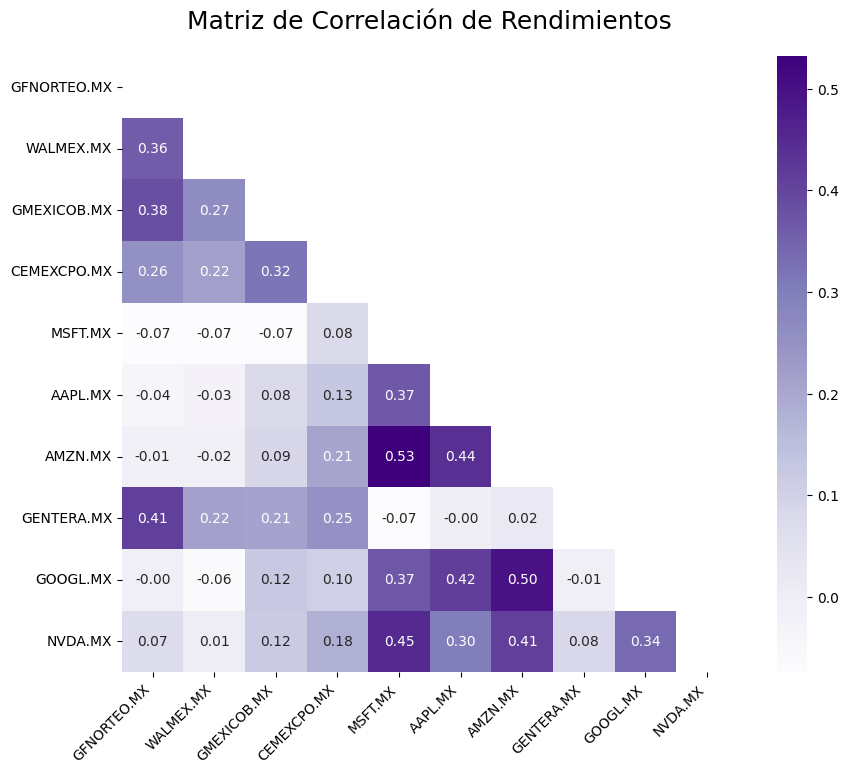

In [38]:
# Vamos a filtrar los datos con una mascara 
# np.ones_like --> Crea una matriz del mismo tamaño de rendimiento_corr
# dtype = bool --> La matriz creada tendrá valores booleanos (True/False)
# np.triu --> Convierte los valores inferiores a la diagonal superior en Falso
mask = np.triu(np.ones_like(matriz_correlacion, dtype=bool))


# graficamos 
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion,
            mask = mask,  # Aplica la máscara para ocultar los valores inferiores a la diagonal
            annot = True,  # Muestra los valores de correlación en cada celda
            cmap = 'Purples', # Colores para la escala de correlación
            cbar=True,       # Colores para la escala de correlación 
            fmt=".2f",       # Formato de los valores de correlación (2 decimales)
            square=True,    # Hace que las celdas sean cuadradas  
            annot_kws={"size": 10}  # Tamaño de la fuente de los valores de correlación
            )
# Título del gráfico
# (pad) entre el título y el gráfico
plt.title("Matriz de Correlación de Rendimientos", fontsize=18, pad=20)  # Título del gráfico con un espacio adicional 

# ejes

plt.xticks(rotation=45, ha="right")  # Rota las etiquetas del eje X 45 grados y las alinea a la derecha (si es left entonces se alinea a la izquierda)
plt.yticks(rotation=0)  # Mantiene las etiquetas del eje Y sin rotar
plt.show()

In [39]:
a = L @ L.T
a

# hacemos que se vea en formato tabla

tabla_L = pd.DataFrame(L, index=matriz_correlacion.index, columns=matriz_correlacion.columns)

In [40]:
L @ L.T == matriz_correlacion

,GFNORTEO.MX,WALMEX.MX,GMEXICOB.MX,CEMEXCPO.MX,MSFT.MX,AAPL.MX,AMZN.MX,GENTERA.MX,GOOGL.MX,NVDA.MX
GFNORTEO.MX,True,True,True,True,True,True,True,True,True,True
WALMEX.MX,True,True,True,True,True,True,True,True,False,False
GMEXICOB.MX,True,True,True,True,True,True,True,True,True,False
CEMEXCPO.MX,True,True,True,False,False,True,True,False,True,False
MSFT.MX,True,True,True,False,True,False,True,True,False,False
AAPL.MX,True,True,True,True,False,True,True,True,False,True
AMZN.MX,True,True,True,True,True,True,True,True,True,True
GENTERA.MX,True,True,True,False,True,True,True,False,False,True
GOOGL.MX,True,False,True,True,False,False,True,False,False,True
NVDA.MX,True,False,False,False,False,True,True,True,True,False


## VaR Monte Carlo con Cholesky

In [41]:
# Paso 1) ---------------------------------
#obtenemos la matriz de correlacion
matriz_correlacion = rendimientos.corr()

# Paso 2) ---------------------------------
# Ocupamos Cholesky
# Obtenemos la matriz L (triangular inferior) de la matriz de correlacion
# tal que M_corr = L * L.T

## Es importante mencionar que al ser una matriz simetrica pasa que...
###  ----->  L.T @ z_independientes == z_independientes @ L   <-----
L = np.linalg.cholesky(matriz_correlacion)

# Paso 3) ---------------------------------
# --- SIMULACIÓN MULTIVARIADA DE MONTECARLO ---

# Recordemos que SIEMPRE definimos una cajita vacía para almacenar los resultados de la simulación
# Diccionarios para almacenar resultados
# nombre: [] ---> Por cada nombre (cada activo) de la lista crea una nueva entrada en el diccionario. La clave de esta entrada será el nombre
# En otras palabras creamos una cajita vacía por cada activo y el nombre de esa cajita será el nombre del Activo
# "BBVA" ---> Cajita vacía llamada "BBVA"
escenarios_por_activo = {nombre: [] for nombre in nombre_acciones}

# Hcemos exactamente lo mismo salvo que estas serán de tipo pd.Series(dtype=float)
# Creamos una Serie de Pandas para almacenar los resutados
VaR_M_activos = pd.Series(dtype=float)
VaR_M_activos_dinero = pd.Series(dtype=float)


# Iniciamos las simulaciones!
# recordemos que no iteramos sobre una variable "i"
# Iteramos sobre el numero de simulaciones "num_simulaciones", por eso ponemos "_" /// guión bajo
for _ in range(num_simulaciones):

    # Generamos un vector de números aleatorios independientes
    # estos números random NO tienen correlación. Los llamamos Z independientes de una N(0,1)
    # Como su nombre lo indica NO siguen una correlación definida
    z_independientes = rand_z_score(len(nombre_acciones))

    # multiplicamos L.T * Z - independientes
    # (matriz L inferior) * (vector de num aleatorios indepedientes)
    # Al multiplicar L.T por los Z - NO correlacionados obtenemos valores Z los cuales SI siguien la correlacion definida
    # Es decir, transformamos ruidos independientes en Z-scores correlacionados
    z_correlacionados = L.T @ z_independientes

    # asignamos la información de cada activo para iterar dada una variable "i" o por el nombre del activo
    for i, nombre in enumerate(nombre_acciones):
        # asiganmos cada Z-score correlacionado a su activo correspondiente
        # "BBVA" ---> Z-correlacionado[1]
        # "NETFLIX" ---> Z-correlacionado[2]
        # ...
        # # "ALSEA" ---> Z-correlacionado[n]
        z_score_especifico = z_correlacionados[i]

        # Obtenemos esperanza, riesgo y valuación del activo a iterar
        # "BBVA" ---> esperanza // riesgo // valuación del activo "BBVA"
        # "NETFLIX" ---> esperanza // riesgo // valuación del activo "NETFLIX"
        # ...
        # "ALSEA" ---> esperanza // riesgo // valuación del activo "ALSEA"
        mu = esperanza_activos[nombre]
        sigma = riesgo_activos[nombre]
        val = valuacion_activos[nombre]

        # Calculamos los escenarios con la funcion definida anteriormente y con los parametros definidos anteriormente
        escenario = profit_and_loss(val, mu, sigma, z_score_especifico, dias)

        #agregamos los resultados iterados a su respectiva cajita
        escenarios_por_activo[nombre].append(escenario)

# Paso 4) ---------------------------------
# Calculamos el VaR de cada activo
# iteramos sobre el nombre de nuestros activos
for nombre in nombre_acciones:
    # Al igual que en el VaR histórico btenemos el cuantil sobre los escenarios ya correlacionados
    # np.quantile nos da el valor de la pérdida/ganancia en el peor alpha%
    VaR_activo = np.quantile(escenarios_por_activo[nombre], alpha)
    # Cambiamos los 0.0 en -0.0 para modificar el signo posteriormente
    if VaR_activo == 0.0:
        VaR_activo = -0.0

    # Guardamos los valores calculados de forma pura y modificado su formato $$$
    VaR_M_activos[nombre] = VaR_activo
    # cambiamos el formato a pesos y el signo
    # Recordemos que al presentar el VaR en un informe, este tiene que ser positivo pues ya es considerad una pérdida
    VaR_M_activos_dinero[nombre] = '${:,.2f}'.format(-VaR_activo)

## Uso de VaR

In [42]:
#uso de VaR
#obtenemos el uso de VaR
uso_VaR_M_activos = VaR_M_activos/valuacion_activos
#cambiamos los valores NaN por 0
uso_VaR_M_activos = uso_VaR_M_activos.fillna(0)
#convertimos a porcentaje
uso_VaR_M_activos_porcentaje = -uso_VaR_M_activos*100
uso_VaR_M_activos_porcentaje = uso_VaR_M_activos_porcentaje.apply('{:,.2f}%'.format)


#uso VaR portafolio
#obtenemos el uso del VaR
uso_VaR_M_port = VaR_M_port[0]/valuacion_port
#lo convertimos a porcentaje
uso_VaR_M_port_porcentaje = -uso_VaR_M_port*100
uso_VaR_M_port_porcentaje = '{:,.2f}%'.format(uso_VaR_M_port_porcentaje)

C

In [43]:
#VaR ---> pérdida  maxima en un periodo de tiempo dado el nivel de confianza

#CVaR ---> si mi perdida super el VaR que tanto?
#promedio del uso del VaR
#se puede tener en porcentaje o en dinero
#en este caso obtendremos el dinero

#CVaR de los activos____________________________________________________________
CVaR_M_activos = pd.Series(dtype=float)

for col in valuacion_historica_activos.columns:
    # Obtenemos el VaR_param_activos para el activo actual
    lim_VaR = VaR_M_activos[col]

    # Filtramos valuacion_historica_activos para el activo actual que estén por debajo del umbral de VaR
    valores_filtrados_activos = valuacion_historica_activos[col][
            (valuacion_historica_activos[col] < VaR_M_activos[col])]

    # Calculamos el promedio de los valores filtrados y reemplazamos NaN con 0
    CVaR_M_activos[col] = np.nan_to_num(valores_filtrados_activos.mean(), nan=-0.0)

CVaR_M_activos_dinero = (-CVaR_M_activos).map('${:,.2f}'.format)


#CVaR del portafolio____________________________________________________________
# Filtramos valuacion_historica_port que estén por debajo del umbral de VaR
CVaR_M_port = (valuacion_historica_port[
            (valuacion_historica_port < VaR_M_port)]).mean()

# Calculamos el promedio de los valores filtrados y reemplazamos NaN con 0
#CVaR_H_port = valores_filtrados_port.mean()
CVaR_M_port_dinero = '${:,.2f}'.format(-CVaR_M_port)


#CVaR rápido____________________________________________________________________
CVaR_M_port_rapido = sum(uso_VaR_M_activos , uso_VaR_M_port)/(num_columnas+1) * valuacion_port
CVaR_M_port_rapido_dinero = '${:,.2f}'.format(-CVaR_M_port_rapido)


## CVaR Ajustado

In [44]:
#VaR ---> pérdida  maxima en un periodo de tiempo dado el nivel de confianza

#CVaR ---> si mi perdida super el VaR que tanto?
#promedio del uso del VaR
#se puede tener en porcentaje o en dinero
#en este caso obtendremos el dinero

#CVaR de los activos____________________________________________________________
CVaR_M_ajustado_activos = pd.Series(dtype=float)
for col in valuacion_historica_activos.columns:

    # Obtenemos el VaR_param_activos para el activo actual
    lim_VaR = VaR_M_activos[col]
    Lim_atípico_inf = limite_inferior_activos[col]

    # Filtramos valuacion_historica_activos para el activo actual que estén por debajo del umbral de VaR
    valores_filtrados_activos = valuacion_historica_activos[col][
            (valuacion_historica_activos[col] > limite_inferior_activos[col]) &
            (valuacion_historica_activos[col] < VaR_M_activos[col])]

    # Calculamos el promedio de los valores filtrados y reemplazamos NaN con 0
    CVaR_M_ajustado_activos[col] = np.nan_to_num(valores_filtrados_activos.mean(), nan=-0.0)
#ajustamos el formato
CVaR_M_ajustado_activos_dinero = (-CVaR_M_ajustado_activos).map('${:,.2f}'.format)


#CVaR del portafolio____________________________________________________________
# Filtramos valuacion_historica_port que estén por debajo del umbral de VaR
CVaR_M_ajustado_port = (valuacion_historica_port[
            (valuacion_historica_port > limite_inferior_port) &
            (valuacion_historica_port < VaR_M_port)]).mean()
# Calculamos el promedio de los valores filtrados y reemplazamos NaN con 0
#CVaR_P_ajustado_port = valores_filtrados_port.mean()
CVaR_M_ajustado_port_dinero = '${:,.2f}'.format(-CVaR_M_ajustado_port)


# Tabla de información

In [45]:
#Creamos una lista con los nombres de los activos y el nombre "Portafolio"
# Es decir. Vamos a hacer una tabla unica que contenga la inf de los activos y del portafolio.
nombre_activos_port = nombre_acciones + ["Portafolio"]

#asignamos la inf respectiva de los activos y del portafolio
# ya que anteriormente guardamos los resultados como pd.Series(dtype=float)
# convertimos a una lista para concatenar la inf del portafiolio
#__________Inf inicial __________________________________
esperanza_porcentaje = list(esperanza_activos_porcentaje) + [esp_port_porcentaje]
riesgo_porcentaje = list(riesgo_activos_porcentaje) + [riesgo_port_porcentaje]
posicion_list = list(posicion_activos) + [posicion_port]
valuacion_dinero = list(valuacion_activos_dinero) + [valuacion_port_dinero]
#__________ VaR 3 metodologías __________________________________
VaR_P_dinero = list(VaR_P_activos_dinero) + [VaR_P_port_dinero]
VaR_H_dinero = list(VaR_H_activos_dinero) + [VaR_H_port_dinero]
VaR_M_dinero = list(VaR_M_activos_dinero) + [VaR_M_port_dinero]
#__________ Uso de VaR 3 metodologías __________________________________
Uso_VaR_P_porcentaje = list(uso_VaR_P_activos_porcentaje) + [uso_VaR_P_port_porcentaje]
Uso_VaR_H_porcentaje = list(uso_VaR_H_activos_porcentaje) + [uso_VaR_H_port_porcentaje]
Uso_VaR_M_porcentaje = list(uso_VaR_M_activos_porcentaje) + [uso_VaR_M_port_porcentaje]
#__________ CVaR puro 3 metodologías __________________________________
CVaR_P_dinero = list(CVaR_P_activos_dinero) + [CVaR_P_port_dinero]
CVaR_H_dinero = list(CVaR_H_activos_dinero) + [CVaR_H_port_dinero]
CVaR_M_dinero = list(CVaR_M_activos_dinero) + [CVaR_M_port_dinero]
#__________ CVaR ajustado 3 metodologías __________________________________
CVaR_P_aj_dinero = list(CVaR_P_ajustado_activos_dinero) + [CVaR_P_ajustado_port_dinero]
CVaR_H_aj_dinero = list(CVaR_H_ajustado_activos_dinero) + [CVaR_H_ajustado_port_dinero]
CVaR_M_aj_dinero = list(CVaR_M_ajustado_activos_dinero) + [CVaR_M_ajustado_port_dinero]


#Creamos un diccionario de datos para el DataFrame
datos_de_lista = {
    "Esperanza ": esperanza_porcentaje,
    "Riesgo ": riesgo_porcentaje,
    "Posición ": posicion_list,
    "Valuación ": valuacion_dinero,
    "VaR paramétrico ": VaR_P_dinero,
    "VaR histórico ": VaR_H_dinero,
    "VaR Montecarlo ": VaR_M_dinero,
    "Uso VaR Param ": Uso_VaR_P_porcentaje,
    "Uso VaR Hist ": Uso_VaR_H_porcentaje,
    "Uso VaR Mont ": Uso_VaR_M_porcentaje,
    "CVaR puro Param ": CVaR_P_dinero,
    "CVaR puro Hist ": CVaR_H_dinero,
    "CVaR puro Mont ": CVaR_M_dinero,
    "CVaR ajustado param ": CVaR_P_aj_dinero,
    "CVaR ajustado hist ": CVaR_H_aj_dinero,
    "CVaR ajustado Mont ": CVaR_M_aj_dinero
}

# Creamos el Dataframe con los datos de la lista
df_Wi = pd.DataFrame(datos_de_lista, index=nombre_activos_port)

df_Wi

,Esperanza,Riesgo,Posición,Valuación,VaR paramétrico,VaR histórico,VaR Montecarlo,Uso VaR Param,Uso VaR Hist,Uso VaR Mont,CVaR puro Param,CVaR puro Hist,CVaR puro Mont,CVaR ajustado param,CVaR ajustado hist,CVaR ajustado Mont
GFNORTEO.MX,0.05959%,1.93676%,538.0,"$103,634.94","$3,301.48","$3,003.43","$3,942.94",3.19%,2.90%,3.80%,"$4,945.05","$4,366.83","$5,466.43","$4,482.06","$4,034.08","$4,840.40"
WALMEX.MX,-0.01848%,1.69098%,4120.0,"$229,978.40","$6,396.66","$5,473.59","$6,153.53",2.78%,2.38%,2.68%,"$9,464.06","$8,421.86","$9,294.08","$9,464.06","$8,421.86","$9,294.08"
GMEXICOB.MX,0.14850%,2.25274%,272.0,"$55,003.84","$2,038.12","$1,769.14","$1,904.12",3.71%,3.22%,3.46%,"$3,175.66","$2,756.40","$3,049.83","$2,815.88","$2,499.08","$2,723.03"
CEMEXCPO.MX,0.11681%,2.15158%,2195.0,"$51,363.00","$1,817.75","$1,646.39","$1,757.24",3.54%,3.21%,3.42%,"$2,479.02","$2,297.55","$2,445.83","$2,377.57","$2,213.90","$2,347.97"
MSFT.MX,0.00604%,1.65499%,39.0,"$278,297.70","$7,575.84","$6,849.77","$9,651.99",2.72%,2.46%,3.47%,"$12,427.97","$10,991.41","$14,968.53","$10,104.68","$9,168.92","$11,773.71"
AAPL.MX,0.09503%,1.82528%,26.0,"$128,769.82","$3,866.09","$3,390.02","$3,761.64",3.00%,2.63%,2.92%,"$5,583.74","$5,343.82","$5,583.74","$5,077.83","$4,891.15","$5,077.83"
AMZN.MX,0.08070%,2.00598%,2.0,"$9,527.26",$314.36,$252.32,$255.23,3.30%,2.65%,2.68%,$478.35,$440.04,$440.04,$405.44,$378.47,$378.47
GENTERA.MX,0.13599%,2.37046%,1628.0,"$76,613.68","$2,987.22","$2,545.88","$2,554.32",3.90%,3.32%,3.33%,"$4,207.91","$3,746.82","$3,746.82","$3,818.18","$3,467.79","$3,467.79"
GOOGL.MX,0.17296%,1.87074%,18.0,"$123,309.72","$3,794.36","$3,264.82","$2,954.37",3.08%,2.65%,2.40%,"$5,750.32","$4,860.59","$4,210.69","$5,098.25","$4,414.66","$3,906.58"
NVDA.MX,0.17022%,2.95612%,12.0,"$42,961.68","$2,088.96","$2,100.82","$1,659.71",4.86%,4.89%,3.86%,"$3,073.91","$3,112.84","$2,729.99","$2,777.92","$2,808.70","$2,492.43"


In [46]:
# float(np.squeeze(s)) --> Convierte el valor de "s" a un número de punto flotante (float) 
# y elimina cualquier dimensión adicional que pueda tener (si es un array de una sola dimensión,
# se convierte en un escalar)
# for s in escenario_port --> Itera sobre cada elemento "s" en la Serie "escenario_port"
escenario_port_MC = pd.Series([float(np.squeeze(s)) for s in escenario_port], dtype=float)

# Histograma de la distribucion Monte Carlo Cholesky
fig_mc = go.Figure()
fig_mc.add_trace(go.Histogram(
    x=escenario_port_MC, # Eje X con los valores simulados del P&L del portafolio
    nbinsx=80, # Número de bins para el histograma
    marker_color="steelblue", 
    opacity=0.75,
    name="P&L Simulado (MC Cholesky)",
    hovertemplate="P&L: %{x:,.2f}<br>Frecuencia: %{y}<extra></extra>",
))

# Agregamos una línea vertical para el VaR Monte Carlo Cholesky
fig_mc.add_vline(
    x=VaR_M_port[0], # Posición de la línea vertical en el eje X (VaR Monte Carlo Cholesky)
    line_dash="dash", # Estilo de la línea (en este caso, línea discontinua)
    line_color="red", # Color de la línea
    annotation_text=f"VaR MC ({nivel_de_confianza_porcentaje}): {VaR_M_port_dinero}", # Texto de la anotación que muestra el valor del VaR Monte Carlo Cholesky
    annotation_position="top right", # Posición de la anotación
)

# Agregamos una línea vertical para el CVaR Monte Carlo Cholesky
fig_mc.add_vline(
    x=CVaR_M_port,
    line_dash="dot", 
    line_color="darkred",
    annotation_text=f"CVaR MC: {CVaR_M_port_dinero}", # Texto de la anotación que muestra el valor del CVaR Monte Carlo Cholesky
    annotation_position="top left",
)



# Configuración del diseño del gráfico
fig_mc.update_layout(
    title="Distribucion Monte Carlo (Cholesky) del P&L del Portafolio", # Título del gráfico
    xaxis_title="P&L ($)", # Etiqueta del eje X
    yaxis_title="Frecuencia", # Etiqueta del eje Y
    bargap=0.05, # Espacio entre las barras del histograma
    legend_title_text="Serie", # Título de la leyenda
    hovermode="x unified", # Modo de visualización de la información al pasar el cursor sobre el gráfico
    width=1100, # Ancho del gráfico en píxeles
    height=600,
)
fig_mc.show()

In [47]:
# Guardamos en salidas/
fig_mc.write_image("salidas/var_cvar.png")

# Histograma del P&L histórico del portafolio

In [48]:
# Distribucion historica del P&L del portafolio con lineas de VaR
fig_pnl = go.Figure()
fig_pnl.add_trace(go.Histogram(
    x=valuacion_historica_port,
    nbinsx=80,
    marker_color="steelblue",
    opacity=0.75,
    name="P&L Historico",
    hovertemplate="P&L: %{x:,.2f}<br>Frecuencia: %{y}<extra></extra>",
))
fig_pnl.add_vline(
    x=VaR_P_port,
    line_dash="dash",
    line_color="red",
    annotation_text=f"VaR Parametrico  {VaR_P_port_dinero}",
    annotation_position="top left",
    annotation_font_color="red",
    line_width=1.5
)
fig_pnl.add_vline(
    x=VaR_H_port,
    line_dash="dash",
    line_color="green",
    annotation_text=f"VaR Historico    {VaR_H_port_dinero}",
    annotation_position="top right",
    annotation_font_color="green",
    line_width=1.5
)
fig_pnl.add_vline(
    x=VaR_M_port[0],
    line_dash="dash",
    line_color="purple",
    annotation_text=f"VaR MC {VaR_M_port_dinero}",
    annotation_position="bottom right",
    #subimos la anotación para que no se superponga con las otras dos (top right y top left)
    annotation_yshift=350,
    # ponemos el color de la anotación en púrpura para que se relacione con la línea del mismo color (purple)
    annotation_font_color="purple",
    line_width=1.5
)
fig_pnl.update_layout(
    title="Distribucion historica del P&L del Portafolio",
    xaxis_title="P&L ($)",
    yaxis_title="Frecuencia",
    bargap=0.05,
    legend_title_text="Serie",
    hovermode="x unified",
    width=1100,
    height=600,
)
fig_pnl.show()

In [49]:
# Guardamos en salidas/
fig_pnl.write_image("salidas/distribucion_rendimientos.png")

# Análisis de Límites — Tabla Resumen

Comparación de los tres métodos de VaR con NC = 95% sobre el portafolio óptimo.

In [50]:
# VaR Monte Carlo simple (sin correlaciones): aseguramos valor escalar
VaR_M_port_val = float(np.ravel(VaR_M_port)[0]) if hasattr(VaR_M_port, '__len__') else float(VaR_M_port)
VaR_M_port_dinero_fmt = '${:,.2f}'.format(-VaR_M_port_val)
uso_VaR_M_pct = '{:.2f}%'.format(-VaR_M_port_val / valuacion_port * 100)

tabla_resumen = pd.DataFrame({
    'VaR Diario ($)': [
        VaR_P_port_dinero, VaR_H_port_dinero, VaR_M_port_dinero
    ],
    'VaR (%)': [
        uso_VaR_P_port_porcentaje, uso_VaR_H_port_porcentaje, uso_VaR_M_port_porcentaje
    ],
    'CVaR ($)': [
        CVaR_P_port_dinero, CVaR_H_port_dinero, CVaR_M_port_dinero
    ],
    'Nivel confianza': [nivel_de_confianza_porcentaje] * 3,
    'Inversión ($)':   [valuacion_port_dinero] * 3,
}, index=['Paramétrico', 'Histórico', 'Monte Carlo'])

tabla_resumen.index.name = 'Método'
tabla_resumen

,VaR Diario ($),VaR (%),CVaR ($),Nivel confianza,Inversión ($)
Método,,,,,
Paramétrico,"$16,659.53",1.52%,"$24,428.83",95%,"$1,099,460.04"
Histórico,"$14,238.08",1.30%,"$21,182.89",95%,"$1,099,460.04"
Monte Carlo,"$16,165.74",1.47%,"$23,546.14",95%,"$1,099,460.04"


# Validación — Backtesting

El backtesting compara las **pérdidas reales observadas** contra el VaR estimado.  
Una **violación** ocurre cuando el P&L real es menor que el VaR (la pérdida superó el límite).  
Para NC = 95% se espera ~5% de violaciones. El **test de Kupiec (POF)** verifica formalmente si
la proporción observada es estadísticamente compatible con el nivel declarado.

## Violaciones al VaR

In [51]:
# Al igual que en la tabla de inf obtenemos los valores calculados del VaR con su metodología
VaR_P = list(VaR_P_activos) + [VaR_P_port.item()]
VaR_H = list(VaR_H_activos) + [VaR_H_port.item()]
VaR_M = list(VaR_M_activos) + [VaR_M_port[0].item()]

# Creamos el DataFrame con la inf obtenida del VaR
# Asignamos su respectivo nombre
# para este caso ocupamos nombre_activos_port)
# el cual ya contiene el nombre de los activos y "Portafolio"
df_VaR_Resumen = pd.DataFrame({
    "VaR Paramétrico": VaR_P,
    "VaR Histórico": VaR_H,
    "VaR Montecarlo": VaR_M
}, index=nombre_activos_port)


In [52]:
# Violaciones VaR Paramétrico
# Nuestra "cajita vacía" par aalmacenar los resultados no debe faltar
violaciones_VaR_P = []
#iteramos sobre una variable "i" o sobre el nombre de la columna
for i, col in enumerate(nombre_activos_port):
    # realizamos el calculo de las violaciones y añadimos a la lista (cajita vacía)
    # (df_valuacion_historica[col] < VaR_P[i]) ---> filtra TODOS los valores de la
    # valuacion historica que esten por debajo del respectivo VaR
    # Esta comparacion devuelve una Serie de valores booleanos
    # True si la valuación es menor que el VaR ---> indica una violación
    # False si la valuación es mayor que el VaR
    # Podemos traducirlo como...
    # 1 si la valuación es menor que el VaR ---> indica una violación
    # 0 si la valuación es mayor que el VaR
    # Por loq ue basta con sumar esos "1" para obtener el numero de violaciones
    # eso lo hacemos con .sum()
    violaciones_VaR_P.append((df_valuacion_historica[col] < VaR_P[i]).sum())


# Violaciones VaR Histórico
# Nuestra "cajita vacía" par aalmacenar los resultados no debe faltar
violaciones_VaR_H = []
for i, col in enumerate(nombre_activos_port):
    violaciones_VaR_H.append((df_valuacion_historica[col] < VaR_H[i]).sum())

# Violaciones VaR Montecarlo
# Nuestra "cajita vacía" par aalmacenar los resultados no debe faltar
violaciones_VaR_M = []
for i, col in enumerate(nombre_activos_port):
    violaciones_VaR_M.append((df_valuacion_historica[col] < VaR_M[i]).sum())

# Creamos el DF con las violaciones del VaR y su respectivo nombre
df_violaciones_VaR = pd.DataFrame({
    "Violaciones VaR P": violaciones_VaR_P,
    "Violaciones VaR H": violaciones_VaR_H,
    "Violaciones VaR M": violaciones_VaR_M
}, index=nombre_activos_port)

df_violaciones_VaR

,Violaciones VaR P,Violaciones VaR H,Violaciones VaR M
GFNORTEO.MX,17,25,12
WALMEX.MX,18,25,19
GMEXICOB.MX,17,25,19
CEMEXCPO.MX,19,25,20
MSFT.MX,18,25,11
AAPL.MX,22,25,22
AMZN.MX,20,25,25
GENTERA.MX,17,25,25
GOOGL.MX,15,25,40
NVDA.MX,26,25,36


In [53]:
# Creamos una lista con el nombre de los metodos que estamos ocupando
metodos = ['Paramétrico', 'Histórico', 'Montecarlo']

# Obtenemos los nombres de las columnas de df_violaciones_VaR
columnas_violaciones_VaR = df_violaciones_VaR.columns

# Num total de observaciones (días) para el cálculo de proporciones
# Para este caso tomamos el num de filas de la valuación histórica
# Son 499/500/501 ---> 2 años
num_observaciones = len(df_valuacion_historica)

# Aun cuando ya tenemos alpha = 5%, ese alpha es para el VaR
# Definimos un nuevo nivel de significancia para las pruebas de kupiec
# normalmente se toma 5%
nivel_significancia_kupiec = 0.05

# Indice (nombre) de los activos/portafolio para los resultados
indice_resultados = df_violaciones_VaR.index

# Cajita vacía
# Lista para almacenar los resultados de cada metodo
resultados_kupiec_por_metodo = []

# Bucle para procesar cada metodo de VaR individualmente
# Queremos realizar las pruebas de kupiec de cada activo y portafolio
# Y también queremos que las pruebas se realicen en las tres metodologías
# Iteramos sobr las columnas de df_violaciones_VaR
for i, nombre_columna_violacion in enumerate(columnas_violaciones_VaR):
    # Obtenemos el nombre del metodo de la lista definida al inicio
    nombre_metodo_actual = metodos[i]

    # Extraemos el num de violaciones del método actual
    violaciones_observadas = df_violaciones_VaR[nombre_columna_violacion]




    # ------------------ FORMILA DE KUPIEC ------------------
    # Proporción observada de violaciones
    proporcion_observada = violaciones_observadas / num_observaciones

    # Para evitar logaritmos de cero (si NO hay violaciones)
    # establecemos (sumamos) una proporción muy pequeña.
    # Usamos una copia para no modificar el DataFrame original de proporciones
    p_obs_ajustada = proporcion_observada.copy()
    p_obs_ajustada[p_obs_ajustada == 0] = 1e-6 # ---> Valor muy pequeñito

    # La proporción esperada es el nivel de significancia del VaR
    p_esperada = alpha

    # Ocupamos la formulita log(esperado/observado)
    # De nuevo se añade un epsilon pequeñito para evitar divisiones o logaritmos de cero
    epsilon_log = 1e-300 # ---> num extremadamente pequeñito

    #aplicacion de la formula (Numerado y Denominador)
    verosimilitud_esperada = ((1 - p_esperada)**(num_observaciones - violaciones_observadas)) * (p_esperada**violaciones_observadas)
    verosimilitud_observada = ((1 - p_obs_ajustada)**(num_observaciones - violaciones_observadas)) * (p_obs_ajustada**violaciones_observadas)

    # Cálculo de Kupiec
    # aquí añadimos epsilon_log
    estadistico_kupiec = -2 * np.log((verosimilitud_esperada + epsilon_log) / (verosimilitud_observada + epsilon_log))



    # ------------------ Verificamos los valores ------------------


    # En caso de que los valores pequeñitos fallen podemos añadir un filtro mas...
    # Los valores infinitos que puedan surgir los remplazamos por 0
    estadistico_kupiec = estadistico_kupiec.replace([np.inf, -np.inf], 0)

    # Definimos el Estadistico de Kupiec
    # Y rellenamos cualquier NaN por si hubo problemas de conversión a 0
    # errors='coerce' ---> si la función encuentra algun valor en "estadistico_kupiec"
    # que no puede ser convertido a un número (hubiera un texto o una cadena vacía)
    # en lugar de generar un error, ese valor será reemplazado por NaN
    # .fillna(0) ---> Cambia los valores NaN por 0
    estadistico_kupiec = pd.to_numeric(estadistico_kupiec, errors='coerce').fillna(0)



    # ------------------ P - Value ------------------

    # Calculamos el p-value usando la funcion de supervivencia (cola derecha) de chi-cuadrado
    # Con grado de libertad
    p_valores_kupiec = stats.chi2.sf(estadistico_kupiec, 1)



    # ------------------ Decisión y recopilación de inf ------------------

    # Decisión sobre la Hip Nula (H0)
    # H0 ---> El modelo de VaR es "correcto"
    # Si p-value > nivel_significancia_kupiec ---> NO se rechaza H0
    # np.where ---> similar a if/else
    # np.where(condición, x, y)
    # Si la condition es True para un elemento, toma el valor correspondiente de x.
    # Si la condition es False para un elemento, toma el valor correspondiente de y
    decisiones_h0 = np.where(p_valores_kupiec > nivel_significancia_kupiec,
                             "No se rechaza H0", "Se rechaza H0")

    # Creamos un Df con los resultados y su decisión
    df_metodo_resultado = pd.DataFrame({
        f'Violaciones ({nombre_metodo_actual})': violaciones_observadas,
        f'P-Valor ({nombre_metodo_actual} %)': p_valores_kupiec * 100,
        f'Decisión H0 ({nombre_metodo_actual})': decisiones_h0
    }, index=indice_resultados)
    resultados_kupiec_por_metodo.append(df_metodo_resultado)


# Recordemos que etsabamos iterando ent...
# unimos los DataFrames de cada metodo horizontalmente (axis=1)
tabla_resultados_kupiec = pd.concat(resultados_kupiec_por_metodo, axis=1)

# Aplicamos formato a 5 decimales
pd.options.display.float_format = '{:,.5f}'.format

# Mostrar la tabla final de resultados
tabla_resultados_kupiec

,Violaciones (Paramétrico),P-Valor (Paramétrico %),Decisión H0 (Paramétrico),Violaciones (Histórico),P-Valor (Histórico %),Decisión H0 (Histórico),Violaciones (Montecarlo),P-Valor (Montecarlo %),Decisión H0 (Montecarlo)
GFNORTEO.MX,17,8.21693,No se rechaza H0,25,100.00000,No se rechaza H0,12,0.31176,Se rechaza H0
WALMEX.MX,18,13.13473,No se rechaza H0,25,100.00000,No se rechaza H0,19,19.93852,No se rechaza H0
GMEXICOB.MX,17,8.21693,No se rechaza H0,25,100.00000,No se rechaza H0,19,19.93852,No se rechaza H0
CEMEXCPO.MX,19,19.93852,No se rechaza H0,25,100.00000,No se rechaza H0,20,28.84791,No se rechaza H0
MSFT.MX,18,13.13473,No se rechaza H0,25,100.00000,No se rechaza H0,11,0.12968,Se rechaza H0
AAPL.MX,22,53.00794,No se rechaza H0,25,100.00000,No se rechaza H0,22,53.00794,No se rechaza H0
AMZN.MX,20,28.84791,No se rechaza H0,25,100.00000,No se rechaza H0,25,100.00000,No se rechaza H0
GENTERA.MX,17,8.21693,No se rechaza H0,25,100.00000,No se rechaza H0,25,100.00000,No se rechaza H0
GOOGL.MX,15,2.71021,Se rechaza H0,25,100.00000,No se rechaza H0,40,0.44780,Se rechaza H0
NVDA.MX,26,83.84151,No se rechaza H0,25,100.00000,No se rechaza H0,36,3.36769,Se rechaza H0


In [54]:
# ── Gráfica de backtesting: P&L real vs límites VaR ──────────────────────────
# Superpone la serie histórica de P&L del portafolio con los umbrales de VaR
# estimados y el límite de valores atípicos, destacando visualmente las fechas
# en que el P&L real atravesó cada umbral de pérdida.

# valuacion_historica_port.index ---> Nos da el índice de la Serie, que en este caso son las fechas de cada observación del P&L del portafolio.
idx_bt     = valuacion_historica_port.index
idx_bt_str = idx_bt.strftime("%Y-%m-%d")

fig_bt = go.Figure()

# ── Serie principal: P&L diario del portafolio ───────────────────────────────
fig_bt.add_trace(go.Scatter(
    x=idx_bt_str,
    y=valuacion_historica_port.values,
    mode="markers",
    name="P&L del Portafolio",
    line=dict(color="steelblue", width=1),
    hovertemplate="Fecha: %{x}<br>P&L: %{y:,.2f}<extra></extra>",
))

# ── Línea horizontal: VaR Paramétrico ────────────────────────────────────────
fig_bt.add_trace(go.Scatter(
    x=idx_bt_str,
    y=[VaR_P_port] * len(idx_bt_str),
    mode="lines",
    name=f"VaR Parametrico  {VaR_P_port_dinero}",
    line=dict(color="red", dash="dash"),
    hovertemplate=f"VaR Parametrico: {VaR_P_port_dinero}<extra></extra>",
))

# ── Línea horizontal: VaR Histórico ──────────────────────────────────────────
fig_bt.add_trace(go.Scatter(
    x=idx_bt_str,
    y=[VaR_H_port] * len(idx_bt_str),
    mode="lines",
    name=f"VaR Historico    {VaR_H_port_dinero}",
    line=dict(color="green", dash="dash"),
    hovertemplate=f"VaR Historico: {VaR_H_port_dinero}<extra></extra>",
))

# ── Línea horizontal: VaR Monte Carlo ────────────────────────────────────────
fig_bt.add_trace(go.Scatter(
    x=idx_bt_str,
    y=[VaR_M_port[0]] * len(idx_bt_str),
    mode="lines",
    name=f"VaR MC      {VaR_M_port_dinero}",
    line=dict(color="purple", dash="dash"),
    hovertemplate=f"VaR MC: {VaR_M_port_dinero}<extra></extra>",
))

# ── Línea horizontal: límite atípico negativo ─────────────────────────────────
# El límite atípico negativo es un umbral estadístico (típicamente calculado
# como media − k*IQR o un percentil extremo) que identifica pérdidas fuera
# del rango esperado incluso bajo condiciones de estrés. Se traza con línea
# punteada para distinguirlo visualmente de los VaR (línea discontinua).
limite_inferior_port_dinero = "${:,.2f}".format(limite_inferior_port)
fig_bt.add_trace(go.Scatter(
    x=idx_bt_str,
    y=[limite_inferior_port] * len(idx_bt_str),
    mode="lines",
    name=f"Atípico negativo {limite_inferior_port_dinero}",
    line=dict(color="darkmagenta", dash="dot"),
    hovertemplate=f"Atípico negativo: {limite_inferior_port_dinero}<extra></extra>",
))

# ── Marcadores: observaciones atípicas negativas ──────────────────────────────
# outliers_mas_bajos_port es una máscara booleana que identifica las fechas
# donde el P&L cayó por debajo del límite atípico. Se aplica directamente
# sobre valuacion_historica_port para filtrar esas observaciones.
# Se grafican en morado para asociarlos visualmente con la línea del límite
# atípico y distinguirlos de las violaciones al VaR (crimson).
outliers_neg         = valuacion_historica_port[outliers_mas_bajos_port]
outliers_neg_idx_str = outliers_neg.index.strftime("%Y-%m-%d")
fig_bt.add_trace(go.Scatter(
    x=outliers_neg_idx_str,
    y=outliers_neg.values,
    mode="markers",
    name=f"Atípicos negativos ({len(outliers_neg)} veces)",
    marker=dict(color="purple", size=7),
    hovertemplate="Fecha: %{x}<br>P&L: %{y:,.2f}<extra></extra>",
))

# ── Marcadores: violaciones al VaR Monte Carlo ───────────────────────────────
viol_idx     = valuacion_historica_port[valuacion_historica_port < VaR_M_port[0]].index
viol_idx_str = viol_idx.strftime("%Y-%m-%d")
viol_y       = valuacion_historica_port.loc[viol_idx].values
fig_bt.add_trace(go.Scatter(
    x=viol_idx_str,
    y=viol_y,
    mode="markers",
    name=f"Violaciones VaR Montecarlo ({len(viol_idx)} veces)",
    marker=dict(color="crimson", size=6),
    hovertemplate="Fecha: %{x}<br>P&L: %{y:,.2f}<extra></extra>",
))

# ── Layout ────────────────────────────────────────────────────────────────────
fig_bt.update_layout(
    title="Backtesting: P&L del Portafolio vs VaR Estimados",
    xaxis_title="Fecha",
    yaxis_title="P&L ($)",
    legend=dict(orientation="v", yanchor="top", y=1, xanchor="left", x=1.02),
    legend_title_text="Serie",
    hovermode="x unified",
    width=1200,
    height=650,
    margin=dict(r=200),
)

fig_bt.show()

In [55]:
# Guardamos la foto en formato png
output_dir = "salidas"
fig_bt.write_image(f"{output_dir}/backtesting.png", scale=3)

In [56]:
# ── Paquetería ────────────────────────────────────────────────────────────────
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import math


# ── Selección de metodología ──────────────────────────────────────────────────
# Variable de control que determina qué conjunto de límites (VaR y CVaR)
# se usa en toda la gráfica. Descomentar la línea deseada y comentar las demás.
### metodologia_VaR = 'VaR Paramétrico'
### metodologia_VaR = 'VaR Histórico'
metodologia_VaR = 'VaR Montecarlo'


# ── Límites según metodología ─────────────────────────────────────────────────
# Se asignan las Series de VaR y CVaR por activo, así como los escalares del
# portafolio, según la metodología seleccionada. El bloque else captura
# Montecarlo como caso por defecto.

if metodologia_VaR == 'VaR Paramétrico':
    _var_activos  = VaR_P_activos
    _var_port     = float(VaR_P_port)
    _cvar_activos = CVaR_P_activos
    _cvar_port    = float(CVaR_P_port)

elif metodologia_VaR == 'VaR Histórico':
    _var_activos  = VaR_H_activos
    _var_port     = float(VaR_H_port)
    _cvar_activos = CVaR_H_activos
    _cvar_port    = float(CVaR_H_port)

else:  # Montecarlo
    _var_activos  = VaR_M_activos
    # hasattr(VaR_M_port, '__getitem__') ---> Verifica si VaR_M_port es
    # indexable (lista, array, Series), en cuyo caso se extrae el primer
    # elemento con [0]. Si es un escalar simple, se convierte directamente
    # a float. Esto hace el código robusto ante distintos formatos de salida
    # del módulo de simulación Monte Carlo.
    _var_port     = float(VaR_M_port[0]) if hasattr(VaR_M_port, '__getitem__') else float(VaR_M_port)
    _cvar_activos = CVaR_M_ajustado_activos
    # .item() ---> Extrae el valor escalar de un array o Series de un solo
    # elemento, convirtiéndolo a un tipo nativo de Python (float). Equivale
    # a float() pero semánticamente más explícito cuando se sabe que el
    # objeto contiene exactamente un valor.
    _cvar_port    = CVaR_M_ajustado_port.item()


# pd.concat() ---> Une las Series de límites por activo con el escalar del
# portafolio, envolviéndolo en pd.Series({'Portafolio': valor}) para que
# quede indexado con la misma etiqueta que el resto de columnas de
# df_valuacion_historica. El resultado es una Serie con un límite por columna.
limites_VaR = pd.concat([
    _var_activos,
    pd.Series({'Portafolio': _var_port}),
])
limites_CVaR = pd.concat([
    _cvar_activos,
    pd.Series({'Portafolio': _cvar_port}),
])
valores_atipicos = pd.concat([
    limite_inferior_activos,
    pd.Series({'Portafolio': float(limite_inferior_port)}),
])


# ── Layout: grilla de subgráficas 3 columnas × N filas ───────────────────────

columnas = list(df_valuacion_historica.columns)  # Un panel por cada activo + portafolio.
n_cols   = 3
# math.ceil() ---> Redondeo hacia arriba del número de filas necesarias para
# acomodar todas las columnas en una grilla de 3 columnas. Por ejemplo,
# 5 activos → ceil(5/3) = 2 filas (la última fila queda con un panel vacío).
n_rows   = math.ceil(len(columnas) / n_cols)

# Prepara títulos con conteos de violaciones por panel.
subplot_titles = []
for nombre in columnas:
    serie    = df_valuacion_historica[nombre]
    lim_var  = limites_VaR[nombre]
    lim_atip = valores_atipicos[nombre]
    n_var    = int((serie < lim_var).sum())
    n_atip   = int((serie < lim_atip).sum())
    subplot_titles.append(
        f"{nombre}<br><span style='font-size:9px;color:#555'>VaR:{n_var} | Atip:{n_atip}</span>"
    )

# make_subplots() ---> Crea una figura de Plotly con una grilla de subgráficas
# de n_rows × n_cols paneles independientes que comparten estilo pero tienen
# sus propios ejes.
#   subplot_titles    : lista de títulos, uno por panel, en orden de izquierda
#                       a derecha y de arriba hacia abajo.
#   vertical_spacing  : fracción de la altura total reservada como espacio
#                       vertical entre filas de paneles.
#   horizontal_spacing: fracción del ancho total reservada entre columnas.
fig = make_subplots(
    rows=n_rows, cols=n_cols,
    subplot_titles=subplot_titles,
    vertical_spacing=0.06,
    horizontal_spacing=0.10,
)


# ── Trazos por subgráfica ─────────────────────────────────────────────────────

for i, nombre in enumerate(columnas):
    # Calcula la fila y columna de la subgráfica actual a partir del índice i.
    r, c    = i // n_cols + 1, i % n_cols + 1
    # Solo la primera subgráfica aporta entradas a la leyenda global para
    # evitar que cada panel duplique las mismas etiquetas.
    primera = (i == 0)

    lim_var  = limites_VaR[nombre]
    lim_cvar = limites_CVaR[nombre]
    lim_atip = valores_atipicos[nombre]
    serie    = df_valuacion_historica[nombre]

    # .to_pydatetime() ---> Convierte el DatetimeIndex de pandas a una lista
    # de objetos datetime nativos de Python. Plotly los renderiza de forma más
    # consistente que los Timestamps de pandas, especialmente al formatear el
    # eje x con la directiva %{x|%Y-%m-%d} en hovertemplate.
    x_vals   = serie.index.to_pydatetime()

    # ── Valuación histórica (dispersión) ─────────────────────────────────────
    # legendgroup ---> Agrupa trazos bajo una misma etiqueta de leyenda. Todos
    # los paneles con legendgroup='pl' comparten la entrada "Valuación P&L",
    # de modo que activar o desactivar esa entrada en la leyenda afecta a todos
    # los paneles simultáneamente.
    # showlegend=primera ---> Solo el primer panel registra la entrada en la
    # leyenda; los demás usan el mismo grupo pero no añaden duplicados.
    fig.add_trace(go.Scatter(
        x=x_vals, y=serie.values,
        mode='markers',
        name='Valuación P&L',
        marker=dict(color='#1f77b4', size=3),
        opacity=0.85,
        legendgroup='pl', showlegend=primera,
        hovertemplate='%{x|%Y-%m-%d}<br>$%{y:,.2f}<extra>P&L</extra>',
    ), row=r, col=c)

    if primera:
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode='lines',
            name='Límite VaR (roja)',
            line=dict(color='red', dash='dash', width=1),
            legendgroup='lim_var', showlegend=True,
            hoverinfo='skip',
        ), row=r, col=c)
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode='lines',
            name='Límite CVaR (naranja)',
            line=dict(color='darkorange', dash='dash', width=1),
            legendgroup='lim_cvar', showlegend=True,
            hoverinfo='skip',
        ), row=r, col=c)
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode='lines',
            name='Límite atípico (morada)',
            line=dict(color='purple', dash='dot', width=1),
            legendgroup='lim_atip', showlegend=True,
            hoverinfo='skip',
        ), row=r, col=c)

    # ── Violaciones al VaR ────────────────────────────────────────────────────
    # Se filtran solo las observaciones donde el P&L cayó por debajo del límite
    # de VaR; si no hay ninguna, se omite el trazo para no agregar una entrada
    # vacía a la leyenda.
    viol_var = serie[serie < lim_var]
    if not viol_var.empty:
        fig.add_trace(go.Scatter(
            x=viol_var.index.to_pydatetime(), y=viol_var.values,
            mode='markers',
            name=f'Violación {metodologia_VaR}',
            marker=dict(color='red', symbol='diamond', size=5),
            legendgroup='viol_var', showlegend=primera,
            hovertemplate='%{x|%Y-%m-%d}<br>$%{y:,.2f}<extra>Violación VaR</extra>',
        ), row=r, col=c)

    # ── Violaciones a valores atípicos ────────────────────────────────────────
    viol_atip = serie[serie < lim_atip]
    if not viol_atip.empty:
        fig.add_trace(go.Scatter(
            x=viol_atip.index.to_pydatetime(), y=viol_atip.values,
            mode='markers',
            name='Violación Atípico',
            marker=dict(color='purple', symbol='diamond', size=5),
            legendgroup='viol_atip', showlegend=primera,
            hovertemplate='%{x|%Y-%m-%d}<br>$%{y:,.2f}<extra>Val. Atípico</extra>',
        ), row=r, col=c)

    # ── Líneas horizontales de límite ─────────────────────────────────────────
    # fig.add_hline() ---> Añade una línea horizontal constante al nivel y
    # especificado en la subgráfica indicada por row y col. A diferencia de
    # add_trace(), no requiere construir un array de valores repetidos; Plotly
    # extiende la línea automáticamente a lo largo de todo el eje x.
    #   annotation_text     : etiqueta flotante sobre la línea.
    #   annotation_position : esquina de la subgráfica donde se ancla la etiqueta.
    fig.add_hline(
        y=lim_var,
        line_color='red', line_dash='dash', line_width=1,
        annotation_text=f'VaR: ${abs(lim_var):,.2f}',
        annotation_font_size=6,
        annotation_font_color='red',
        annotation_position='top left',
        row=r, col=c,
    )
    fig.add_hline(
        y=lim_cvar,
        line_color='darkorange', line_dash='dash', line_width=1,
        annotation_text=f'CVaR: ${abs(lim_cvar):,.2f}',
        annotation_font_size=6,
        annotation_font_color='darkorange',
        annotation_position='bottom right',
        row=r, col=c,
    )
    fig.add_hline(
        y=lim_atip,
        line_color='purple', line_dash='dot', line_width=1,
        row=r, col=c,
    )


# ── Estilo A4 portrait (794 × 1122 px a 96 DPI) ──────────────────────────────
# Las dimensiones replican una hoja A4 en orientación vertical para facilitar
# la exportación directa a PDF o impresión sin reescalado.

fig.update_layout(
    width=794,
    height=1122,
    margin=dict(t=55, b=65, l=50, r=15),
    # Leyenda horizontal debajo de la figura para no competir con los paneles.
    legend=dict(
        orientation='h', x=0, y=-0.04,
        font_size=8,
    ),
    font_size=8,
    plot_bgcolor='white',
    paper_bgcolor='white',
)

# update_yaxes / update_xaxes ---> Aplican los atributos de estilo a TODOS
# los ejes y o x de la figura simultáneamente, sin necesidad de iterar
# panel por panel.
#   tickprefix='$'    : antepone "$" a cada marca del eje y.
#   tickformat=',.0f' : entero con separador de miles, sin decimales.
#   gridcolor/gridwidth: color y grosor de las líneas de la cuadrícula.
fig.update_yaxes(
    tickprefix='$', tickformat=',.0f', tickfont_size=7,
    gridcolor='#e0e0e0', gridwidth=0.5,
)
fig.update_xaxes(
    tickfont_size=6, tickangle=30,
    gridcolor='#e0e0e0', gridwidth=0.5,
)

fig.show()

In [57]:
# Exporta a PNG en alta calidad (usa kaleido)
output_png = "prueba/backtesting_activos.png"
fig.write_image(output_png, width=794, height=1122, scale=5)
print(f"Guardado: {output_png}")


Guardado: prueba/backtesting_activos.png


Para el Backtesting consideramos crear una variable **Metodo del VaR**. Ya que el VaR es un número "fijo" no podemos graficar su trayectoria como se graficó directamente el el PnL del portafolio, para poder graficar la trayectoria del VaR ocuparemos el VaR porcentual ya calculado anteriormente.
Antes de definir el factor de crecimiento vamos a definir en este caso una variable "V" en la cual vamos a seleccionar la metodología que queremos ocupar.

Para este punto ya calculamos la pruebas de Kupiec. (sí, antes del backtesting, pues ya tenemos calculadas las violaciones al VaR del PnL) Por lo que ya podemos utilizar una metodología que SÍ sea matemáticamente consistente.


Factor de crecimiento:


*   El factor de crecimiento para la trayectoria de nuestro portafolio sera considerada como:

```
1 + PnL_port
```

*   De manera muy similar el factor de crecimiento para la trayectoria del VaR será considerada como ⁉



```
1 + metodo_uso_VaR[V]
```





In [58]:
### creamos una lista con los valores del Uso de VaR con las 3 metodologías
metodo_uso_VaR = [uso_VaR_P_port, uso_VaR_H_port, uso_VaR_M_port]

# seleccionamos con que metodología queremos trabajar para el Backtestig
# 0 ---> Paramétrico
# 1 ---> Histórico
# 2 ---> Montecarlo

V = 2

# --- CONSTRUCCIÓN DE LA TRAYECTORIA ---
# Ya tenemos el Profit and loss del portafolio (rendimiento del portafolio dado Wi)
# Ahora vamos a construir la trayectoria historia con base al PnL del portafolio
# (1 + PnL_port) ---> convertimos a un factor de crecimiento
# Por ejemplo .005 ---> 1.005 ---> (1 + r)
# cumprod() ---> Calcula el producto acumulado ---> (1 + r_1) * (1 + r_2) ... (1 + r_n)
factores_crecimiento = (1 + PnL_port).cumprod()
# para que nuestro grafo no se vea acumulado poemos añadir un dia adicional al inicio
# es decir, empezamos un día antes de nuestra fecha original
# rendimientos.index[0] - pd.Timedelta(days=1) ---> restamos un dia
# .insert(0, ) ---> inserta la nueva fecha en la poss 0, es decir, al inicio
fechas_simulacion = rendimientos.index.insert(0, rendimientos.index[0] - pd.Timedelta(days=1))

# Vamos a Crear la trayectoria del portafolio en una Serie de pandas con base a:
# Su valuación ---> Es donde vamos a iniciar
# Factor de crecimiento dados los renndimientos (PnL) del portafolio
# valuacion_port * factores_crecimiento.values ---> calcula el valor del portafolio en cada momento desde el primer hasta el ultimo dia
# np.insert(..., 0, valuacion_port) ---> valuacion_port (valuacion inicial del portafolio) se inserta al principio (poss 0)
# esto hace que empecemos en el dia cero con el monto de la valuacion del portafolio
# index=fechas_simulacion ---> asigna las fechas que ya establecimos
valores_trayectoria = pd.Series(
    np.insert(valuacion_port * factores_crecimiento.values, 0, valuacion_port),
    index=fechas_simulacion)

# Construimos la Trayectoria del VaR con base a la Trayectoria construida y el uso de VaR
# Trayectoria VaR (Shift 1): El riesgo de hoy se mide con respecto al valor de ayer
# .shift(1) ---> Para este caso pensemos que:
# El valor del portafolio para el dia n ahora se asocia con el dia n+1
# OJO es VALOR de el portafolio, NO Valuación del portafolio
# trayectoria_VaR_dia1 = valor_dia0 * (1 + Uso_VaR)
# trayectoria_VaR_dia5 = valor_dia4 * (1 + Uso_VaR)
trayectoria_VaR = valores_trayectoria.shift(1) * (1 + metodo_uso_VaR[V])

# Filtramos los valores que estan por debajo de la trayectoria del VaR
violaciones_mask = valores_trayectoria < trayectoria_VaR
# ya filtradas las violaciones al VaR obtenemos sus fechas para graficar
fechas_v = valores_trayectoria.index[violaciones_mask]

# Convertimos a datetime nativo para evitar errores de serializacion
fechas_simulacion_py = fechas_simulacion.to_pydatetime()
fechas_v_py = fechas_v.to_pydatetime()

# ---------------------- info Gráfica ----------------------
fig_port_backtesting = go.Figure()

# Trayectoria del Portafolio ---> Línea principal de valor de mercado (Azul)
fig_port_backtesting.add_trace(go.Scatter(
    x=fechas_simulacion_py,
    y=valores_trayectoria,
    mode='lines',
    name='Trayectoria del Portafolio',
    line=dict(color='#00BFFF', width=2.5),
    hovertemplate='<b>Fecha:</b> %{x}<br><b>Valor:</b> $%{y:,.2f}<extra></extra>'
))

# Límite VaR (Roja)
fig_port_backtesting.add_trace(go.Scatter(
    x=fechas_simulacion_py,
    y=trayectoria_VaR,
    mode='lines',
    name='Límite de VaR',
    line=dict(color="red", width=1.5, dash='dash'),
    hovertemplate='<b>Fecha:</b> %{x}<br><b>Límite VaR:</b> $%{y:,.2f}<extra></extra>'
))

# Marcadores de Violación al VaR (Diamantes rojos)
if len(fechas_v_py) > 0:
    fig_port_backtesting.add_trace(go.Scatter(
        x=fechas_v_py,
        y=valores_trayectoria.loc[fechas_v],
        mode='markers',
        name='Excepciones VaR',
        marker=dict(
            color='red', symbol='diamond', size=10,
            line=dict(width=1, color='white')
        ),
        hovertemplate='<b>¡VIOLACIÓN!</b><br>Fecha: %{x}<br>Valor: $%{y:,.2f}<extra></extra>'
    ))

# Zona de Confianza ---> Sombreado entre el valor real y el límite VaR
x_fill = list(fechas_simulacion_py) + list(fechas_simulacion_py)[::-1]
y_fill = valores_trayectoria.values.tolist() + trayectoria_VaR.fillna(valores_trayectoria).values.tolist()[::-1]
fig_port_backtesting.add_trace(go.Scatter(
    x=x_fill,
    y=y_fill,
    fill='toself',
    fillcolor='rgba(255, 165, 0, 0.45)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo='skip',
    name='Zona de Confianza'
))

# ---------------------- DISEÑO Y FORMATO DEL GRAFO ----------------------
fig_port_backtesting.update_layout(
    title=dict(
        text='Backtesting <br><sup>Trayectoria vs. Límite VaR</sup>',
        font=dict(size=29, color='white'),
        x=0.05, xanchor='left'
    ),
    xaxis_title='Periodo',
    yaxis_title='Valor de la Inversión (MXN)',
    template='plotly_dark',
    width=1100, height=650,
    hovermode='x unified',
    # Configuración de Zoom: 'xy' permite zoom libre en ambos ejes
    dragmode='zoom',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

# Anotación técnica en esquina superior izquierda
fig_port_backtesting.add_annotation(
    text=f"Método: {metodos[V]} | Confianza: {nivel_de_confianza}% | Violaciones: {len(fechas_v)}",
    xref="paper", yref="paper",
    x=0.01, y=0.98, showarrow=False,
    font=dict(size=12, color="#00BFFF"),
    bgcolor="rgba(0,0,0,0.5)"
 )

# Formato de ejes
fig_port_backtesting.update_yaxes(
    tickformat='$,.2f',
    gridcolor='rgba(255,255,255,0.1)',

 )
fig_port_backtesting.update_xaxes(
    gridcolor='rgba(255,255,255,0.1)',
 )

fig_port_backtesting.show()

In [59]:
# Guardamos la foto en formato png en /prueba
output_png = "prueba/backtesting_portafolio.png"
fig_port_backtesting.write_image(output_png, width=1100, height=650, scale=3)
print(f"Guardado: {output_png}")

Guardado: prueba/backtesting_portafolio.png


# Stress Testing Escenarios de Shock 3σ

Se simulan condiciones extremas de mercado donde la desviación estándar de cada factor
de riesgo se triplica (3σ). Se analizan tres escenarios:
1. **Shock negativo global**: −3σ simultáneamente en todos los activos.
2. **Shock positivo global**: +3σ simultáneamente en todos los activos.
3. **Shock individual**: −3σ en cada activo por separado (análisis de sensibilidad).

## Duplicando o triplicando la dsv est (riesgo del portafolio)


Para el Stress testing aumentando la desv est vamos a recliclar el mismo código del gráfico de Backtesting, salvo que añadiremos la gráfica de trayectoria normal del portafolio (Azul)

Factor de crecimiento normal


```
# 1 + PnL_port
```


Nuestro Factor de crecimiento estresado estará dado por...

```
1 + estres * (PnL_port - esp_port)
```

Factores a considerar:



*   NO vamos a sumar el PnL del portafolio, es decir, NO haremos lo siguiente:


```
# 1 + PnL_port + estres * (PnL_port - esp_port)
```


*   Si bien la desv est es una medida de dispersión que cuantifica la separación de un conjunto de datos respecto a su media, una manera mas informal de decirlo es... digamos la distancia, por ende un valor abs. Para este ejercicio no consideraremos los valores positivos, es decir, vamos a considerar únicamente:

```
# (PnL_port - esp_port)
```



*   ¿Sumamos o Restamos el estrés?


      1.   Si SUMAMOS el estrés, estaremos considerando una trayectoria y tendencia "similar" (salvo la volatilidad) a la original... pero digamos "exagerando" dichas tendencias. Por ende, cabe la posibilidad de tener (aún duplicando o triplicado la dsv est) que tengamos un punto de cierre de valuación aun mas alto que la original. Esto podría crear llegar a crear confusión, pues recordemos que queremos observar nuestro portafoio en un escenario de crisis extrema. Aunque SI existe la posibilidad de presenciar eventos así, un ejemplo de ello... En la pandemia las empresas con servicios de Streaming, como Netflix, Max,  Amazon Prime Video, etc. Pudieron tener un benficio a diferencia de otras empresas.
      2.   Si RESTAMOS el estrés, estaremos considerando una tendecía opuesta a la original, por lo que existe la posibilidad de estar tanto en un punto máximo (si la trayectoría normal tiene una visible tendenencia bajista) como un punto mínimo (si la tarectoria normal tiene una visible tendencia alcista)

      Para este portafolio se está considerando sumar el estrés, si bien existe un punto máximo de 10M la valuación final del portafolio es de 2M. Si tomamos en cuenta restar el estrés, el portafolio únicamente sigue una curva de tendencia bajista hasta llegar a los 2M. Para este caso se considera que hay mas información sumando el estrés del portafolio llegando al objetivo del mismo.

In [60]:
# Asigamos un valor para el estres del portafolio
estres = 3 # ------------------------------------------> Aquí modificamos que tanto vamos a estresar el portafolio


# --- CONSTRUCCIÓN DE LA TRAYECTORIA ---
# Ya tenemos el Profit and loss del portafolio (rendimiento del portafolio dado Wi)
# Ahora vamos a construir la trayectoria historia con base al PnL del portafolio
# (1 + PnL_port) ---> convertimos a un factor de crecimiento
# Por ejemplo .005 ---> 1.005 ---> (1 + r)
# cumprod() ---> Calcula el producto acumulado ---> (1 + r_1) * (1 + r_2) ... (1 + r_n)
factores_crecimiento = (1 + PnL_port).cumprod()
factores_crecimiento_stress = (1 + estres * (PnL_port - esp_port)).cumprod()
# para que nuestro grafo no se vea acumulado poemos añadir un dia adicional al inicio
# es decir, empezamos un día antes de nuestra fecha original
# rendimientos.index[0] - pd.Timedelta(days=1) ---> restamos un dia
# .insert(0, ) ---> inserta la nueva fecha en la poss 0, es decir, al inicio
fechas_simulacion = rendimientos.index.insert(0, rendimientos.index[0] - pd.Timedelta(days=1))

# Vamos a Crear la trayectoria del portafolio en una Serie de pandas con base a:
# Su valuación ---> Es donde vamos a iniciar
# Factor de crecimiento dados los renndimientos (PnL) del portafolio
# valuacion_port * factores_crecimiento.values ---> calcula el valor del portafolio en cada momento desde el primer hasta el ultimo dia
# np.insert(..., 0, valuacion_port) ---> valuacion_port (valuacion inicial del portafolio) se inserta al principio (poss 0)
# esto hace que empecemos en el dia cero con el monto de la valuacion del portafolio
# index=fechas_simulacion ---> asigna las fechas que ya establecimos

valores_trayectoria = pd.Series(
    np.insert(valuacion_port * factores_crecimiento.values, 0, valuacion_port),
    index=fechas_simulacion)
# De la misma forma construimos la trayectoria estresada con base el factor de cresimiento estresado
valores_trayectoria_estres = pd.Series(
    np.insert(valuacion_port * factores_crecimiento_stress.values, 0, valuacion_port),
    index=fechas_simulacion)


# Construimos la Trayectoria del VaR con base a la Trayectoria construida y el uso de VaR
# Trayectoria VaR (Shift 1): El riesgo de hoy se mide con respecto al valor de ayer
# .shift(1) ---> Para este caso pensemos que:
# El valor del portafolio para el dia n ahora se asocia con el dia n+1
# OJO es VALOR de el portafolio, NO Valuación del portafolio
# trayectoria_VaR_dia1 = valor_dia0 * (1 + Uso_VaR)
# trayectoria_VaR_dia5 = valor_dia4 * (1 + Uso_VaR)
trayectoria_VaR = valores_trayectoria_estres.shift(1) * (1 + metodo_uso_VaR[V])

# Filtramos los valores que estan por debajo de la trayectoria del VaR
violaciones_mask = valores_trayectoria_estres < trayectoria_VaR
# ya filtradas las violaciones al VaR obtenemos sus fechas para graficar
fechas_v = valores_trayectoria_estres.index[violaciones_mask]

nivel_confianza = nivel_de_confianza

In [61]:
# ---------------------- GRÁFICA DE STRESS TESTING Y VaR ----------------------
# Inicializamos el lienzo vacío donde vamos a construir nuestra gráfica interactiva
# go.Figure() ---> Crea un objeto de figura de Plotly para ir añadiendo capas (traces)
fig_port = go.Figure()

# Preparación de las fechas para el eje X
# OJO: La librería Kaleido (usada para exportar imágenes de Plotly) falla con los objetos pandas.Timestamp
# .to_pydatetime() ---> convierte el índice de fechas de pandas a un formato datetime nativo de Python para evitar errores al renderizar
x_sim = fechas_simulacion.to_pydatetime()
x_tray = valores_trayectoria_estres.index.to_pydatetime()
x_v = fechas_v.to_pydatetime()


# --- CAPA 1: TRAYECTORIA DEL PORTAFOLIO NORMAL ---
# Añadimos la evolución de nuestro portafolio original (sin estrés)
# .add_trace() ---> Añade una nueva capa o serie de datos al lienzo principal
# go.Scatter(...) ---> Genera un gráfico de dispersión, que aquí configuramos como una línea continua
fig_port.add_trace(go.Scatter(
    x=x_sim,                                # ---> Eje X: Todas las fechas de nuestra simulación
    y=valores_trayectoria,                  # ---> Eje Y: Valor monetario del portafolio base a lo largo del tiempo
    mode='lines',                           # ---> Une los puntos con una línea
    name='Portafolio normal',               # ---> Bautizamos la serie para la leyenda
    line=dict(color='#00BFFF', width=2.5),  # ---> Color azul claro y grosor de 2.5
    # hovertemplate ---> Personaliza la cajita de información al pasar el mouse
    # %{y:,.2f} ---> Aplica formato monetario (comas para miles, 2 decimales)
    # <extra></extra> ---> Truco para borrar la caja secundaria molesta que Plotly pone por defecto
    hovertemplate='<b>Fecha:</b> %{x}<br><b>Valor:</b> $%{y:,.2f}<extra></extra>'
))


# --- CAPA 2: TRAYECTORIA DEL PORTAFOLIO ESTRESADO ---
# Trayectoria estresada ---> Línea principal de valor de mercado asumiendo una desviación estándar doble o triple
fig_port.add_trace(go.Scatter(
    x=x_sim,                                # ---> Eje X: Mismas fechas
    y=valores_trayectoria_estres,           # ---> Eje Y: Valor del portafolio castigado por el factor de estrés
    mode='lines',                           
    name='Portafolio estresado',            
    line=dict(color='#FFA500', width=2.5),  # ---> Usamos Naranja para resaltar visualmente el escenario de riesgo
    hovertemplate='<b>Fecha:</b> %{x}<br><b>Valor:</b> $%{y:,.2f}<extra></extra>'
))


# --- CAPA 3: LÍMITE VaR ---
# Dibujamos nuestro umbral de pérdida máxima esperada. Si el portafolio cruza esta línea hacia abajo, es una violación.
fig_port.add_trace(go.Scatter(
    x=x_sim,
    y=trayectoria_VaR,                      # ---> Eje Y: El límite inferior calculado de nuestro VaR
    mode='lines',
    name='Límite de VaR',
    # dash='dash' ---> Cambiamos el estilo a línea punteada para indicar que es una frontera/límite y no el valor real
    line=dict(color="red", width=1.5, dash='dash'), 
    hovertemplate='<b>Fecha:</b> %{x}<br><b>Límite VaR:</b> $%{y:,.2f}<extra></extra>'
))


# --- CAPA 4: MARCADORES DE VIOLACIÓN AL VaR ---
# Solo graficamos si encontramos excepciones reales (cuando la pérdida estresada rebasó nuestro VaR)
# if not fechas_v.empty ---> Condicional para asegurarnos de que la serie de violaciones tiene datos
if not fechas_v.empty:
    fig_port.add_trace(go.Scatter(
        x=x_v,                                              # ---> Eje X: Solo las fechas donde hubo violación
        # .loc[fechas_v] ---> Filtramos el valor exacto que tuvo el portafolio estresado en esos días críticos
        y=valores_trayectoria_estres.loc[fechas_v],         
        mode='markers',                                     # ---> 'markers' en vez de 'lines' para poner puntos sueltos
        name='Excepciones VaR',
        marker=dict(
            color='red', symbol='diamond', size=10,         # ---> Rombo rojo de tamaño 10 para máxima alerta visual
            line=dict(width=1, color='white')               # ---> Borde blanco para que el diamante resalte sobre la línea naranja
        ),
        hovertemplate='<b>¡VIOLACIÓN!</b><br>Fecha: %{x}<br>Valor: $%{y:,.2f}<extra></extra>'
    ))


# --- CAPA 5: ZONA DE CONFIANZA ---
# Zona de Confianza ---> Sombreado visual entre el valor real estresado (límite superior) y el límite VaR (límite inferior)
x_tray_list = x_tray.tolist()
fig_port.add_trace(go.Scatter(
    # Para rellenar el área, tenemos que dibujar un polígono cerrado.
    # Vamos de "ida" por el eje X normal, y regresamos de "vuelta" por el eje X invertido [::-1]
    x=x_tray_list + x_tray_list[::-1],
    # Para el eje Y: Vamos de "ida" trazando el portafolio estresado, y de "vuelta" trazando el límite VaR invertido [::-1]
    # .fillna(...) ---> Si al principio el VaR tiene nulos (por el shift), los rellenamos con el valor inicial para cerrar el polígono bien
    y=valores_trayectoria_estres.values.tolist() + trayectoria_VaR.fillna(valores_trayectoria_estres).values.tolist()[::-1],
    fill='toself',                                  # ---> Le indica a Plotly que rellene el espacio delimitado por nuestro trazado
    fillcolor='rgba(220, 220, 220, 0.35)',          # ---> Gris claro con 35% de opacidad para que no tape las demás líneas
    line=dict(color='rgba(255,255,255,0)'),         # ---> Hacemos que el borde del polígono en sí sea transparente
    hoverinfo='skip',                               # ---> Desactivamos el popup al pasar el mouse sobre el sombreado para no estorbar
    name='Zona de Confianza'
))


# ---------------------- DISEÑO Y FORMATO DEL GRAFO ----------------------
# Configuramos la estética general, ejes, y modo de interacción del usuario
fig_port.update_layout(
    title=dict(
        # <br> y <sup> ---> Etiquetas HTML para hacer saltos de línea y texto en superíndice (más pequeño)
        text='Stress Testing<br><sup>Trayectoria vs. Límite VaR</sup>',
        font=dict(size=29, color='white'),
        x=0.05, xanchor='left'                      # ---> Alineamos el título a la izquierda del gráfico
    ),
    xaxis_title='Periodo',
    yaxis_title='Valor de la Inversión (MXN)',
    template='plotly_dark',                         # ---> Aplicamos un tema oscuro ideal para Dashboards
    width=1100, height=650,                         # ---> Forzamos dimensiones para que no varíe según la pantalla
    # hovermode='x unified' ---> Muestra una línea vertical que atraviesa todas las series y junta su info en un solo tooltip
    hovermode='x unified',
    dragmode='zoom',                                # ---> Al hacer clic y arrastrar, acercamos la gráfica
    # legend=dict(...) ---> Movemos la leyenda para que sea horizontal (orientation="h") y se acomode arriba a la derecha
    legend=dict(orientation="h", yanchor="bottom", y=.98, xanchor="right", x=1)
)

# Anotación de info extra en la esquina superior izquierda
fig_port.add_annotation(
    text=f"Método: {metodos[V]} | Confianza: {nivel_confianza}% | Violaciones: {len(fechas_v)} | {estres} desv est",
    # xref/yref="paper" ---> Le indica que use coordenadas relativas al lienzo (de 0 a 1), no a los datos (fechas/dinero)
    xref="paper", yref="paper",
    x=0.01, y=0.98, showarrow=False,                # ---> Lo ubicamos arriba a la izq sin la flecha apuntadora
    font=dict(size=12, color="#00BFFF"),
    bgcolor="rgba(0,0,0,0.5)"                       # ---> Fondo negro con 50% de transparencia para la cajita
)

# Formato de ejes
fig_port.update_yaxes(
    tickformat='$,.2f',                             # ---> El eje Y muestra signos de peso, separador de miles y dos decimales
    gridcolor='rgba(255,255,255,0.1)',              # ---> Cuadrícula blanca muy sutil al 10%

)

fig_port.update_xaxes(
    gridcolor='rgba(255,255,255,0.1)',              # ---> Mismo estilo sutil para las líneas verticales del periodo
)

# Renderizamos la gráfica en nuestra pantalla o Notebook
fig_port.show()

In [62]:
# Guardamos en salidas/
fig_port.write_image("salidas/stress_testing.png", scale=4)

## Escenarios Históricos de Crisis

Se replican dos crisis históricas relevantes aplicando los peores retornos observados
en ese período al portafolio actual.  
Las crisis analizadas son:
- **GFC 2008-09**: Quiebra de Lehman Brothers y crisis financiera global (sep 2008 – mar 2009).
- **COVID-19 2020**: Crash de mercado por la pandemia (feb 2020 – abr 2020).

Para activos sin historial suficiente en la ventana de crisis se utiliza un **proxy**
(ETF o acción equivalente con datos disponibles). Los resultados de VaR/CVaR anteriores
no se ven afectados porque se usa un conjunto de datos separado (`precios_crisis`).

In [63]:
# ── Configuración de escenarios y horizontes ─────────────────────────────────


# Escenarios de crisis históricos definidos como un diccionario anidado.
# Cada clave es el nombre del escenario; su valor es otro diccionario con
# las fechas de inicio y fin (formato "YYYY-MM-DD") y una descripción breve.
escenarios_crisis = {
    "GFC 2008-09": {
        "inicio":      "2008-09-01",
        "fin":         "2009-03-31",
        "descripcion": "Crisis Financiera Global (Lehman Brothers)",
    },
    "COVID-19 2020": {
        "inicio":      "2020-02-20",
        "fin":         "2023-5-14",
        "descripcion": "Crash de mercado por COVID-19",
    },
}

# Horizontes de análisis expresados en días hábiles.
# La variable horizonte_activo actúa como selector; modificarla alterna
# entre el cálculo diario y el mensual sin tocar el resto del código.
horizontes = {"1 día": 1, "21 días": 21}
horizonte_activo = "21 días"      # ← cambiar a "21 días" para horizonte mensual
h = horizontes[horizonte_activo]


# ── Construcción del DataFrame de configuración ───────────────────────────────

# pd.DataFrame() ---> Recibe un diccionario cuyas claves se convierten en
# columnas y cuyos valores son, a su vez, diccionarios {fila: dato}.
# Aquí se usan comprensiones de diccionario para extraer el campo
# correspondiente de cada escenario en una sola línea:
#   {k: v["inicio"] for k, v in escenarios_crisis.items()}
# produce {"GFC 2008-09": "2008-09-01", "COVID-19 2020": "2020-02-20"},
# que Pandas interpreta como una columna donde el índice son los nombres
# de los escenarios y los valores son las fechas de inicio.
# El mismo patrón se repite para "fin" y "descripcion".

# escenarios_crisis.items() ---> Devuelve una vista iterable de pares
# (clave, valor) del diccionario. En cada iteración, k toma el nombre del
# escenario y v toma el sub-diccionario con sus atributos, lo que permite
# acceder a v["inicio"], v["fin"] y v["descripcion"] en las comprensiones.

config_df = pd.DataFrame({
    "Inicio":      {k: v["inicio"]      for k, v in escenarios_crisis.items()},
    "Fin":         {k: v["fin"]         for k, v in escenarios_crisis.items()},
    "Descripción": {k: v["descripcion"] for k, v in escenarios_crisis.items()},
})

# Asigna nombre al índice del DataFrame para que aparezca como encabezado
# de fila al imprimirlo o exportarlo.
config_df.index.name = "Escenario"

print(f"Horizonte activo: {horizonte_activo}  ({h} días hábiles)\n")
config_df

Horizonte activo: 21 días  (21 días hábiles)



,Inicio,Fin,Descripción
Escenario,,,
GFC 2008-09,2008-09-01,2009-03-31,Crisis Financiera Global (Lehman Brothers)
COVID-19 2020,2020-02-20,2023-5-14,Crash de mercado por COVID-19


In [64]:
# ── Mapeo activo → proxy y descarga de datos históricos de crisis ─────────────
# Se usa el proxy cuando el activo no tiene observaciones suficientes en la
# ventana de crisis. EWW = iShares MSCI Mexico ETF (mercado mexicano general).

# Diccionario que asocia cada ticker local en MXN con su proxy de referencia.
# El proxy es un activo con historial completo durante los periodos de crisis
# que sirve como sustituto para estimar el comportamiento del activo original.
proxy_map = {
    "GFNORTEO.MX": "EWW",   # Grupo Financiero Norte -> mercado MX
    "WALMEX.MX":   "EWW",   # Walmart de Mexico -> mercado MX
    "GMEXICOB.MX": "EWW",   # Grupo Mexico -> mercado MX
    "CEMEXCPO.MX": "EWW",   # Cemex -> mercado MX
    "MSFT.MX":     "MSFT",  # Microsoft MX -> Microsoft US
    "AAPL.MX":     "AAPL",  # Apple MX -> Apple US
    "AMZN.MX":     "AMZN",  # Amazon MX -> Amazon US
    "GENTERA.MX":  "EWW",   # Gentera -> mercado MX
    "GOOGL.MX":    "GOOGL", # Alphabet MX -> Alphabet US
    "NVDA.MX":     "NVDA",  # Nvidia MX -> Nvidia US
}

# Rango de descarga: cubre ambas crisis con buffer para la ventana deslizante.
fecha_inicio_descarga = "2008-06-01"
fecha_fin_descarga    = "2020-05-31"

# set(proxy_map.values()) ---> Extrae todos los valores del diccionario
# proxy_map (los tickers proxy) y los almacena en un conjunto, eliminando
# automáticamente los duplicados. Por ejemplo, "EWW" aparece tres veces
# en proxy_map pero set() lo conserva una sola vez.

# sorted() ---> Ordena el conjunto resultante alfabéticamente. Dado que
# los conjuntos no tienen orden definido, sorted() garantiza reproducibilidad
# en la lista de proxies únicos.

# La concatenación con nombre_acciones produce la lista completa de tickers
# a descargar sin repeticiones.
tickers_a_descargar = nombre_acciones + sorted(set(proxy_map.values()))


# ── Descarga de precios de cierre ajustados ───────────────────────────────────

recolector_c = []  # Acumula las series individuales antes de concatenarlas.

for t in tickers_a_descargar:
    try:
        # yf.Ticker(t).history() ---> Instancia un objeto Ticker de yfinance
        # para el símbolo t y descarga su historial de precios en el rango
        # indicado. Devuelve un DataFrame con columnas OHLCV; se selecciona
        # únicamente la columna "Close" (precio de cierre ajustado por
        # dividendos y splits), obteniendo una Serie indexada por fecha.
        px_t = yf.Ticker(t).history(
            start=fecha_inicio_descarga,
            end=fecha_fin_descarga
        )["Close"]

        px_t.name = t  # Nombra la serie con el ticker para identificarla al concatenar.

        if not px_t.empty:
            recolector_c.append(px_t)

    except Exception as e:
        print(f"  Advertencia — {t}: {e}")

# pd.concat(..., axis=1) ---> Une todas las Series del recolector en un único
# DataFrame alineando por índice (fecha). axis=1 indica concatenación por
# columnas; cada Serie se convierte en una columna identificada por su nombre.

# .ffill() ---> Propagación hacia adelante (forward fill): rellena los NaN
# de cada columna con el último valor observado disponible. Se usa para cubrir
# días no hábiles o ausencias puntuales de cotización sin introducir datos
# futuros en la serie.
precios_crisis = pd.concat(recolector_c, axis=1).ffill()


# ── Normalización del índice temporal ────────────────────────────────────────

# .tz_localize(None) ---> Elimina la información de zona horaria del índice
# DatetimeIndex. yfinance puede devolver índices con timezone (tz-aware) o
# sin ella (tz-naive) según el mercado; este paso homogeniza ambos casos para
# evitar errores de comparación al alinear series de distintos orígenes.

precios_crisis.index = (
    precios_crisis.index.tz_localize(None)
    if precios_crisis.index.tz is not None
    else precios_crisis.index
)

# .duplicated(keep="last") ---> Devuelve una máscara booleana que marca como
# True las filas con índice duplicado, conservando únicamente la última
# ocurrencia (keep="last"). La negación ~ selecciona las filas no duplicadas.
precios_crisis = (
    precios_crisis[~precios_crisis.index.duplicated(keep="last")]
    .sort_index()
)

# Rendimientos logarítmicos: ln(P_t) - ln(P_{t-1}).
# np.log().diff() aplica la diferencia de primer orden sobre el logaritmo
# natural del precio, produciendo retornos continuamente compuestos.
# .dropna(how="all") elimina solo las filas donde TODAS las columnas son NaN.
rendimientos_crisis = np.log(precios_crisis).diff().dropna(how="all")


# ── Ajuste por tipo de cambio MXN/USD ────────────────────────────────────────
# Los proxies denominados en USD generan retornos en dólares. Para un
# inversionista en pesos, la pérdida real depende también del movimiento
# del tipo de cambio durante la crisis.
# Convención: retorno POSITIVO de MXN=X = DEPRECIACIÓN del peso
# (más pesos por dólar), lo que AMPLIFICA las pérdidas en activos dolarizados.
# Aproximación log-aditiva: r_ajustado = r_USD + r_MXNUSD

ticker_fx = "MXN=X"  # Tipo de cambio spot MXN por USD en Yahoo Finance.

try:
    # .rename(columns={"Close": "MXNUSD"}) ---> Renombra la columna "Close"
    # del DataFrame descargado a "MXNUSD" para identificar claramente la serie
    # de tipo de cambio y distinguirla de los precios de acciones.
    px_fx = yf.Ticker(ticker_fx).history(
        start=fecha_inicio_descarga,
        end=fecha_fin_descarga
    )[["Close"]].rename(columns={"Close": "MXNUSD"})

    if px_fx.empty:
        raise ValueError("Serie MXN=X vacia")

    # Normalizar zonas horarias y eliminar duplicados en ambas series
    # para garantizar alineación correcta al reindexar.
    px_fx.index = (
        px_fx.index.tz_localize(None)
        if px_fx.index.tz is not None
        else px_fx.index
    )
    precios_crisis.index = (
        precios_crisis.index.tz_localize(None)
        if precios_crisis.index.tz is not None
        else precios_crisis.index
    )

    # .normalize() ---> Trunca la componente horaria del DatetimeIndex,
    # dejando solo la fecha (hora 00:00:00). Necesario cuando yfinance
    # devuelve timestamps con horas distintas en diferentes series, lo que
    # impediría la alineación exacta por índice.
    px_fx.index = px_fx.index.normalize()
    precios_crisis.index = precios_crisis.index.normalize()

    px_fx = px_fx[~px_fx.index.duplicated(keep="last")].sort_index()
    precios_crisis = precios_crisis[~precios_crisis.index.duplicated(keep="last")].sort_index()

    # .reindex(precios_crisis.index).ffill().bfill() ---> Alinea px_fx al
    # calendario exacto de precios_crisis. Las fechas sin cotización FX
    # (fines de semana, feriados) reciben primero el valor anterior (ffill)
    # y, si quedan NaN al inicio de la serie, el siguiente valor disponible
    # (bfill).
    px_fx = px_fx.reindex(precios_crisis.index).ffill().bfill()

    if px_fx["MXNUSD"].isna().all():
        raise ValueError("Serie MXN=X sin datos tras alineacion")

    # Incorporar el tipo de cambio como columna adicional en precios_crisis
    # y recalcular los rendimientos logarítmicos con la serie completa.
    precios_crisis["MXNUSD"] = px_fx["MXNUSD"]
    precios_crisis = precios_crisis.ffill()
    rendimientos_crisis = np.log(precios_crisis).diff().dropna(how="all")

    print(f"Tipo de cambio MXN/USD cargado correctamente.")
    print(
        f"Rango FX: {px_fx.dropna().index.min().date()} → "
        f"{px_fx.dropna().index.max().date()}"
    )

except Exception as e:
    print(f"Advertencia — no se pudo descargar MXN=X: {e}")
    print("Se procederá sin ajuste cambiario.")


# ── Proxies denominados en USD que requieren ajuste cambiario ─────────────────
# Solo se ajustan los proxies que se activan efectivamente; los activos con
# serie propia en MXN no se modifican.
proxies_en_usd = {"EWW", "MSFT", "AAPL", "AMZN", "GOOGL", "NVDA"}


def retorno_ajustado_mxn(serie_nombre, escenario, fecha_i, fecha_f, h):
    """
    Calcula el peor retorno acumulado en MXN para una serie proxy en USD.

    Suma el log-retorno del proxy y el log-retorno del tipo de cambio
    MXN/USD en la misma ventana deslizante de h días hábiles y devuelve
    el mínimo acumulado (worst-case) junto con la fecha en que ocurre.

    Parámetros
    ----------
    serie_nombre : str
        Nombre de la columna en rendimientos_crisis que contiene el proxy.
    escenario : str
        Nombre del escenario de crisis (uso informativo / trazabilidad).
    fecha_i : str
        Fecha de inicio del escenario en formato "YYYY-MM-DD".
    fecha_f : str
        Fecha de fin del escenario en formato "YYYY-MM-DD".
    h : int
        Horizonte de la ventana deslizante en días hábiles.

    Retorna
    -------
    ret_aritm : float
        Peor retorno aritmético acumulado en MXN (np.nan si datos insuficientes).
    idx_min : pandas.Timestamp
        Fecha en que se produce el peor retorno (np.nan si datos insuficientes).
    """
    if serie_nombre not in rendimientos_crisis.columns:
        return np.nan, np.nan

    # Normalizar las fechas al timezone del índice de rendimientos_crisis
    # para evitar errores de comparación tz-aware vs tz-naive.
    idx_tz = rendimientos_crisis.index.tz
    inicio = pd.Timestamp(fecha_i)
    fin    = pd.Timestamp(fecha_f)

    if idx_tz is None:
        inicio = inicio.tz_localize(None) if inicio.tz is not None else inicio
        fin    = fin.tz_localize(None)    if fin.tz is not None    else fin
    else:
        inicio = inicio.tz_localize(idx_tz) if inicio.tz is None else inicio.tz_convert(idx_tz)
        fin    = fin.tz_localize(idx_tz)    if fin.tz is None    else fin.tz_convert(idx_tz)

    # Filtrar la ventana del escenario para el proxy.
    ventana_proxy = rendimientos_crisis.loc[inicio:fin, serie_nombre].dropna()

    if "MXNUSD" in rendimientos_crisis.columns:
        ventana_fx = rendimientos_crisis.loc[inicio:fin, "MXNUSD"].dropna()

        # .intersection() ---> Devuelve el subconjunto de fechas presentes en
        # ambos índices simultáneamente, garantizando que la suma log-aditiva
        # opere sobre observaciones perfectamente alineadas día a día.
        idx_comun     = ventana_proxy.index.intersection(ventana_fx.index)
        ventana_proxy = ventana_proxy.loc[idx_comun]
        ventana_fx    = ventana_fx.loc[idx_comun]

        # Retorno ajustado: r_USD + r_MXNUSD.
        # La depreciación del peso (r_MXNUSD > 0) amplifica la pérdida
        # en activos dolarizados para el inversionista en MXN.
        ventana_ajust = ventana_proxy + ventana_fx
    else:
        # Sin datos FX disponibles: se usa el retorno en USD sin ajuste.
        ventana_ajust = ventana_proxy

    if len(ventana_ajust) < h:
        return np.nan, np.nan

    # .rolling(h).sum() ---> Calcula la suma acumulada de log-retornos en
    # ventanas deslizantes de h días consecutivos, equivalente al retorno
    # logarítmico total del periodo. El resultado en cada fecha t representa
    # el retorno acumulado de los h días anteriores.
    ret_acum = ventana_ajust.rolling(h).sum()

    idx_min   = ret_acum.idxmin()       # Fecha del peor retorno logarítmico acumulado.

    # np.expm1() ---> Calcula e^x - 1 con mayor precisión numérica que
    # exp(x) - 1 para valores de x cercanos a cero. Convierte el peor
    # retorno logarítmico al retorno aritmético equivalente:
    # r_aritm = e^(r_log) - 1.
    ret_aritm = np.expm1(ret_acum.min())

    return ret_aritm, idx_min


print(f"Datos cargados: {precios_crisis.shape[0]} fechas × {precios_crisis.shape[1]} series")
print(f"Rango: {precios_crisis.index.min().date()} → {precios_crisis.index.max().date()}")

Tipo de cambio MXN/USD cargado correctamente.
Rango FX: 2008-06-02 → 2020-05-29
Datos cargados: 3099 fechas × 17 series
Rango: 2008-06-02 → 2020-05-29


In [65]:
# ── Verificación de cobertura: activo propio vs proxy ────────────────────────
# Para cada activo y escenario se cuenta cuántas observaciones hay dentro de
# la ventana. Si son menos de h+5, se usa el proxy.

MIN_OBS = h + 5

cobertura = {}
for escenario, params in escenarios_crisis.items():
    fecha_i = pd.Timestamp(params["inicio"])
    fecha_f = pd.Timestamp(params["fin"])
    cobertura[escenario] = {}
    for activo in nombre_acciones:
        proxy = proxy_map[activo]
        if activo in rendimientos_crisis.columns:
            # Alineamos zonas horarias entre las fechas y el índice de rendimientos_crisis
            tz = rendimientos_crisis.index.tz
            
            # pd.Timestamp(params["inicio"]) --> convierte la fecha de inicio del escenario a un objeto 
            # Timestamp de pandas, que es una forma de representar fechas y horas en pandas.
            inicio = pd.Timestamp(params["inicio"])
            
            # pd.Timestamp(params["fin"]) --> convierte la fecha de fin del escenario a un objeto 
            # Timestamp de pandas.
            fin = pd.Timestamp(params["fin"])
            # Si rendimientos_crisis tiene una zona horaria (tz), se asegura que las fechas de inicio 
            # y fin también estén en la misma zona horaria para evitar problemas al filtrar por rango de fechas.
            if tz is not None:
                if inicio.tz is None:
                    # Si la fecha de inicio no tiene zona horaria, se localiza a la zona horaria del índice de rendimientos_crisis
                    inicio = inicio.tz_localize(tz)
                else:
                    # Si la fecha de inicio ya tiene zona horaria, se convierte a la zona horaria del índice de rendimientos_crisis
                    inicio = inicio.tz_convert(tz)
                if fin.tz is None:
                    # Si la fecha de fin no tiene zona horaria, se localiza a la zona horaria del índice de rendimientos_crisis
                    fin = fin.tz_localize(tz)
                else:
                    # Si la fecha de fin ya tiene zona horaria, se convierte a la zona horaria del índice de rendimientos_crisis
                    fin = fin.tz_convert(tz)
            # obs = rendimientos_crisis.loc[inicio:fin, activo].dropna().shape[0] 
            # --> cuenta cuántas observaciones no nulas hay para el activo en el rango de fechas definido por inicio y fin.
            obs = rendimientos_crisis.loc[inicio:fin, activo].dropna().shape[0]
        else:
            # Si el activo no está presente en rendimientos_crisis, se asigna 0 observaciones para ese activo en ese escenario.
            obs = 0
        # Se determina si se debe usar el proxy para ese activo en ese escenario, comparando el número de observaciones con el mínimo requerido (MIN_OBS).
        # Si obs es menor que MIN_OBS, se considera que no hay suficientes observaciones y se decide usar el proxy.
        usa_proxy = obs < MIN_OBS
        # Se almacena la información de cobertura para ese activo y escenario en el diccionario cobertura, incluyendo el número de observaciones,
        # la serie que se usará (proxy o activo) y si se usará proxy o no.
        cobertura[escenario][activo] = {
            # "obs_activo": obs --> almacena el número de observaciones disponibles para el activo en ese escenario.
            "obs_activo": obs,
            # "serie": proxy if usa_proxy else activo --> almacena el nombre de la serie que se usará para ese activo en ese escenario.
            # Si se decide usar el proxy, se almacena el nombre del proxy; de lo contrario, se almacena el nombre del activo.
            "serie":      proxy if usa_proxy else activo,
            # "proxy": usa_proxy --> almacena un valor booleano indicando si se usará el proxy para ese activo en ese escenario.
            "proxy":      usa_proxy,
        }

# Tabla de cobertura
rows_cob = []
# Iteramos sobre cada escenario y sus activos para construir una lista de filas que luego se convertirá en un DataFrame.
for esc, activos_dict in cobertura.items():
    # Iteramos sobre cada activo y su información asociada (número de observaciones, serie usada y si se usa proxy)
    # para construir un diccionario con la información que queremos mostrar en la tabla de cobertura.
    
    # activos_dict es un diccionario que contiene la información de cobertura para cada activo en el escenario actual (esc).
    for activo, info in activos_dict.items():
        # rows_cob.append({...}) --> agregamos un diccionario a la lista rows_cob, donde cada diccionario representa una fila de la tabla de cobertura.
        rows_cob.append({
            # Escenario: esc --> almacena el nombre del escenario actual (por ejemplo, "GFC 2008-09" o "COVID-19 2020").
            "Escenario":   esc,
            # Activo: activo --> almacena el nombre del activo para esa fila de la tabla.
            "Activo":      activo,
            # Obs. propias: info["obs_activo"] --> almacena el número de observaciones disponibles para el activo en ese escenario, que se obtiene del diccionario info.
            "Obs. propias": info["obs_activo"],
            # Serie usada: info["serie"] --> almacena el nombre de la serie que se usará para ese activo en ese escenario, que se obtiene del diccionario info.
            "Serie usada": info["serie"],
            # Usa proxy: "Sí" if info["proxy"] else "No" --> almacena un valor booleano indicando si se usará el proxy para ese activo en ese escenario.
            "Usa proxy":   "Sí" if info["proxy"] else "No",
        })

# .set_index(["Escenario", "Activo"]) --> convierte las columnas "Escenario" y "Activo" en el índice del DataFrame,
# lo que facilita la visualización y organización de la información.
df_cobertura = pd.DataFrame(rows_cob).set_index(["Escenario", "Activo"])
print(f"Mínimo de observaciones requeridas por ventana: {MIN_OBS}\n")
df_cobertura

Mínimo de observaciones requeridas por ventana: 26



Obs. propias  Serie usada Usa proxy
Escenario     Activo                                          
GFC 2008-09   GFNORTEO.MX           150  GFNORTEO.MX        No
              WALMEX.MX             150    WALMEX.MX        No
              GMEXICOB.MX           150  GMEXICOB.MX        No
              CEMEXCPO.MX           150  CEMEXCPO.MX        No
              MSFT.MX               150      MSFT.MX        No
              AAPL.MX               150      AAPL.MX        No
              AMZN.MX               150      AMZN.MX        No
              GENTERA.MX              0          EWW        Sí
              GOOGL.MX              150     GOOGL.MX        No
              NVDA.MX                 0         NVDA        Sí
COVID-19 2020 GFNORTEO.MX            71  GFNORTEO.MX        No
              WALMEX.MX              71    WALMEX.MX        No
              GMEXICOB.MX            71  GMEXICOB.MX        No
              CEMEXCPO.MX            71  CEMEXCPO.MX        No
              MSFT.MX                71      MSFT.MX        No
              AAPL.MX                71      AAPL.MX        No
              AMZN.MX                71      AMZN.MX        No
              GENTERA.MX             71   GENTERA.MX        No
              GOOGL.MX               71     GOOGL.MX        No
              NVDA.MX                71      NVDA.MX        No

In [66]:
# ── Peor retorno acumulado (ventana deslizante de h días) ────────────────────
# Dentro de cada ventana de crisis calculamos la suma de log-retornos en cada
# sub-ventana de h días consecutivos y nos quedamos con la peor (mínimo).
# Ese log-return acumulado se convierte a retorno aritmético: e^r - 1.

# La función peor_ret_rolling toma una serie de rendimientos, un rango de fechas y un horizonte h, y devuelve el peor retorno acumulado 3
# (suma de log-retornos) dentro de ese rango de fechas para ventanas deslizantes de h días, así como la fecha en la que ocurre ese peor retorno.
def peor_ret_rolling(serie_ret, fecha_inicio, fecha_fin, h):
    # serie_ret.dropna() --> elimina los valores nulos de la serie de rendimientos para asegurarse de que solo se consideren las observaciones 
    # válidas al calcular el retorno acumulado.
    ventana = serie_ret.dropna()

    # Normaliza tz entre índice y fechas
    idx_tz = ventana.index.tz
    # pd.Timestamp(fecha_inicio) --> convierte la fecha de inicio a un objeto Timestamp de pandas, que es una forma de representar fechas y horas en pandas.
    inicio = pd.Timestamp(fecha_inicio)
    # pd.Timestamp(fecha_fin) --> convierte la fecha de fin a un objeto Timestamp de pandas.
    fin = pd.Timestamp(fecha_fin)

    # Si el índice de la serie de rendimientos tiene una zona horaria (tz),
    # se asegura que las fechas de inicio y fin también estén en la misma zona horaria para evitar problemas al filtrar por rango de fechas.
    if idx_tz is None:
        # Índice tz-naive --> quitar tz si viene con tz
        if inicio.tz is not None:
            inicio = inicio.tz_localize(None)
        if fin.tz is not None:
            fin = fin.tz_localize(None)
    else:
        # Índice tz-aware --> aplicar tz del índice
        if inicio.tz is None:
            inicio = inicio.tz_localize(idx_tz)
        else:
            inicio = inicio.tz_convert(idx_tz)
        if fin.tz is None:
            fin = fin.tz_localize(idx_tz)
        else:
            fin = fin.tz_convert(idx_tz)
    # Filtrar la ventana de tiempo
    ventana = ventana.loc[inicio:fin]
    # Si la cantidad de observaciones en la ventana es menor que el horizonte h, 
    # no se puede calcular un retorno acumulado válido, por lo que se devuelve NaN para ambos valores (retorno acumulado y fecha).
    if len(ventana) < h:
        # np.nan --> representa un valor numérico que no es un número (Not a Number), que se utiliza para indicar la ausencia de un valor válido o la imposibilidad de calcular un resultado.
        return np.nan, np.nan
    # rolling(h).sum() --> calcula la suma de los log-retornos en ventanas deslizantes de h días consecutivos a lo largo de la serie de rendimientos.
    ret_acum = ventana.rolling(h).sum()
    # ret_acum.idxmin() --> encuentra la fecha en la que ocurre el peor retorno acumulado (mínimo) dentro de la serie de retornos acumulados calculada.
    idx_min = ret_acum.idxmin()
    # Finalmente se devuelve el peor retorno acumulado (mínimo) y la fecha en la que ocurre ese peor retorno.
    return ret_acum.min(), idx_min

# Se inicializan dos diccionarios vacíos para almacenar los resultados del peor retorno acumulado y las fechas correspondientes para cada escenario de crisis y cada activo.
resultados_crisis = {}
fechas_peor       = {}

# Iteramos sobre cada escenario de crisis definido en el diccionario escenarios_crisis para calcular el peor retorno acumulado para cada activo dentro de la ventana
# de tiempo definida por ese escenario.
for escenario, params in escenarios_crisis.items():
    # pd.Timestamp(params["inicio"]) --> convierte la fecha de inicio del escenario a un objeto Timestamp de pandas.
    fecha_i = pd.Timestamp(params["inicio"])
    # pd.Timestamp(params["fin"]) --> convierte la fecha de fin del escenario a un objeto Timestamp de pandas.
    fecha_f = pd.Timestamp(params["fin"])
    # Se inicializan diccionarios vacíos para almacenar los resultados del peor retorno acumulado y las fechas correspondientes para cada activo dentro de ese escenario.
    resultados_crisis[escenario] = {}
    # Se inicializan diccionarios vacíos para almacenar las fechas del peor retorno acumulado para cada activo dentro de ese escenario.
    fechas_peor[escenario]       = {}

    # Iteramos sobre cada activo definido en la lista nombre_acciones para calcular el peor retorno acumulado para ese activo dentro de la ventana 
    # e tiempo definida por el escenario actual.
    for activo in nombre_acciones:
        # cobertura[escenario][activo] --> accedemos a la información de cobertura para ese activo y escenario específico, que se almacena en el diccionario cobertura.
        serie_nombre = cobertura[escenario][activo]["serie"]
        # cobertura[escenario][activo]["proxy"] --> accedemos a la información de si se usará el proxy para ese activo y escenario específico,
        # que se almacena en el diccionario cobertura.
        usa_proxy    = cobertura[escenario][activo]["proxy"]

        # Se determina el nombre de la serie que se usará para calcular el peor retorno acumulado para ese activo y escenario específico,
        # que puede ser el nombre del activo o el nombre del proxy, dependiendo de si se decidió usar el proxy o no.
        if serie_nombre not in rendimientos_crisis.columns:
            # Si la serie que se va a usar (ya sea el activo o el proxy) no está presente en rendimientos_crisis, se asigna NaN al resultado del peor retorno acumulado
            resultados_crisis[escenario][activo] = np.nan
            # Si no se encuentra la serie en rendimientos_crisis, también se asigna "N/D" a la fecha del peor retorno acumulado para ese activo y escenario específico.
            fechas_peor[escenario][activo]       = "N/D"
            continue

        # Si es proxy en USD --> aplicar ajuste cambiario MXN/USD
        if usa_proxy and serie_nombre in proxies_en_usd:
            # retorno_ajustado_mxn(serie_nombre, escenario, fecha_i, fecha_f, h) --> se llama a la función retorno_ajustado_mxn para calcular el peor retorno 
            # acumulado ajustado por tipo de cambio MXN/USD para esa serie proxy en USD, dentro de la ventana de tiempo definida por el escenario.
            ret_aritm, fecha_min = retorno_ajustado_mxn(
                # serie_nombre --> el nombre de la serie que se usará para calcular el peor retorno acumulado, que puede ser el nombre del activo o el nombre del proxy.
                # escenario --> el nombre del escenario de crisis actual para el cual se está calculando el peor retorno acumulado.
                # fecha_i --> la fecha de inicio de la ventana de tiempo definida por el escenario de crisis.
                # fecha_f --> la fecha de fin de la ventana de tiempo definida por el escenario de crisis.
                # h --> el horizonte de tiempo (en días hábiles) para calcular el peor retorno acumulado dentro de la ventana de tiempo definida por el escenario de crisis.
                serie_nombre, escenario, fecha_i, fecha_f, h
            )
        else:
            # Serie propia en MXN o proxy ya en MXN --> sin ajuste
            log_ret_min, fecha_min = peor_ret_rolling(
                # serie_nombre --> el nombre de la serie que se usará para calcular el peor retorno acumulado, que puede ser el nombre del activo o el nombre del proxy.
                # escenario --> el nombre del escenario de crisis actual para el cual se está calculando el peor retorno acumulado.
                # fecha_i --> la fecha de inicio de la ventana de tiempo definida por el escenario de crisis.
                # fecha_f --> la fecha de fin de la ventana de tiempo definida por el escenario de crisis.
                # h --> el horizonte de tiempo (en días hábiles) para calcular el peor retorno acumulado dentro de la ventana de tiempo definida por el escenario de crisis.
                rendimientos_crisis[serie_nombre], fecha_i, fecha_f, h
            )
            # np.expm1(log_ret_min) --> convierte el peor retorno acumulado en logaritmo (log_ret_min) a retorno aritmético utilizando la función np.expm1,
            # que calcula e^x - 1 de manera más precisa para valores pequeños de x.
            ret_aritm = (np.expm1(log_ret_min)
                        # Si log_ret_min es NaN, entonces ret_aritm también se asigna como NaN para indicar que no se pudo calcular un retorno válido para 
                        # ese activo y escenario específico.
                        if not np.isnan(log_ret_min) else np.nan)

        # Se almacena el resultado del peor retorno acumulado (ret_aritm) para ese activo y escenario específico en el diccionario resultados_crisis.
        resultados_crisis[escenario][activo] = ret_aritm
        # Se almacena la fecha del peor retorno acumulado (fecha_min) para ese activo y escenario específico en el diccionario fechas_peor.
        fechas_peor[escenario][activo]       = (
            # fecha_min.date() --> si fecha_min no es NaN, se convierte a formato de fecha (sin hora) utilizando el método .date() de pandas.
            fecha_min.date()
            # Si fecha_min es NaN, se asigna "N/D" para indicar que no se pudo determinar la fecha del peor retorno acumulado para ese activo y escenario específico.
            if not isinstance(fecha_min, float) else "N/D"
        )

# Construimos un DataFrame con los resultados guardados en nuestro diccionario
# pd.DataFrame(...) ---> Convierte el diccionario en una tabla matricial (filas = activos, columnas = escenarios de crisis)
df_peores_retornos = pd.DataFrame(resultados_crisis)

# .index.name ---> Bautizamos el índice de las filas como "Activo" para mayor claridad al visualizar la tabla
df_peores_retornos.index.name = "Activo"

print(f"Peor retorno acumulado ({horizonte_activo}) dentro de cada "
    f"ventana de crisis (proxies USD ajustados por MXN/USD):\n")
    
# Damos formato de porcentaje a los resultados para facilitar su lectura en la tabla final
# .applymap(...) ---> Aplica una función específica a cada elemento (celda) del DataFrame
# lambda x: f"{x:.2%}" ---> Si es un número válido (pd.notna), lo formatea a porcentaje con 2 decimales (ej. -0.153 -> -15.30%)
# else "N/D" ---> Si el valor no se pudo calcular (NaN), lo mostramos como "N/D" (No Disponible)
df_peores_retornos.applymap(lambda x: f"{x:.2%}" if pd.notna(x) else "N/D")

Peor retorno acumulado (21 días) dentro de cada ventana de crisis (proxies USD ajustados por MXN/USD):



C:\Users\jon\AppData\Local\Temp\ipykernel_1360\3397112903.py:139: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_peores_retornos.applymap(lambda x: f"{x:.2%}" if pd.notna(x) else "N/D")


,GFC 2008-09,COVID-19 2020
Activo,,
GFNORTEO.MX,-52.61%,-45.41%
WALMEX.MX,-25.12%,-12.41%
GMEXICOB.MX,-41.85%,-24.89%
CEMEXCPO.MX,-60.89%,-40.28%
MSFT.MX,-18.45%,-6.42%
AAPL.MX,-34.78%,-6.10%
AMZN.MX,-28.29%,-9.21%
GENTERA.MX,-35.68%,-62.83%
GOOGL.MX,-26.87%,-8.17%


In [67]:
# --- CONSTRUCCIÓN DE TRAYECTORIAS DEL PORTAFOLIO POR ESCENARIO DE CRISIS ---
# Para cada escenario histórico (ej. COVID, Crisis 2008), vamos a ensamblar una serie de rendimientos diarios.
# Utilizaremos la serie propia del activo o un proxy (con ajuste de tipo de cambio si aplica).
# Finalmente, construiremos la trayectoria de valor acumulado y la compararemos contra nuestro límite de VaR.

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Definimos si queremos graficar/analizar solo la ventana específica de crisis o toda la historia disponible
rango_plot = "escenario" # ------------------------------------------> Aquí modificamos el rango visual ("escenario" o "completo")

# Inicializamos un diccionario vacío donde guardaremos los resultados (DataFrames, violaciones, etc.) de cada crisis
trayectorias_crisis = {}

# Iteramos sobre cada escenario definido en nuestro diccionario maestro de crisis
for escenario, params in escenarios_crisis.items():

    # pd.Timestamp(...) ---> Convertimos los strings de fecha a objetos de tiempo de pandas para poder operar con ellos
    fecha_i = pd.Timestamp(params["inicio"])
    fecha_f = pd.Timestamp(params["fin"])

    # ── 1. Ensamblar rendimientos diarios del portafolio para este escenario ──
    
    # Normalizamos la zona horaria (tz) de las fechas respecto al índice maestro (precios_crisis)
    # ¿Por qué? ---> Para asegurar que no haya desfasamientos al cruzar los datos y mantener un eje temporal continuo.
    # Pandas es muy estricto: si cruzas una serie tz-aware (con zona horaria) y una tz-naive (sin zona horaria), arrojará error o puros NaNs.
    idx_tz = precios_crisis.index.tz
    inicio_tz = fecha_i
    fin_tz    = fecha_f

    # Bloque de control: Si el índice maestro no tiene zona horaria, se la quitamos a nuestras fechas de inicio/fin (tz_localize(None))
    # Si sí tiene, se la asignamos a nuestras fechas para que hablen el mismo "idioma temporal"
    if idx_tz is None:
        if inicio_tz.tz is not None:
            inicio_tz = inicio_tz.tz_localize(None)
        if fin_tz.tz is not None:
            fin_tz = fin_tz.tz_localize(None)
    else:
        if inicio_tz.tz is None:
            inicio_tz = inicio_tz.tz_localize(idx_tz)
        if fin_tz.tz is None:
            fin_tz = fin_tz.tz_localize(idx_tz)

    # Definir el rango temporal exacto que vamos a extraer de nuestros DataFrames
    if rango_plot == "completo":
        inicio_plot = precios_crisis.index.min()
        fin_plot = precios_crisis.index.max()
    else:
        inicio_plot = inicio_tz
        fin_plot = fin_tz

    # Creamos un DataFrame auxiliar para ir apilando los rendimientos ajustados de cada activo
    # Usamos el índice de precios_crisis (.loc[inicio_plot:fin_plot].index) para mantener un calendario estricto
    # pd.DataFrame(index=idx_precios) ---> Crea un cascarón vacío con las fechas de negociación reales, evitando días faltantes
    idx_precios = precios_crisis.loc[inicio_plot:fin_plot].index
    rend_activos_escenario = pd.DataFrame(index=idx_precios)

    # Iteramos activo por activo de nuestro portafolio para extraer su serie correcta
    for i, activo in enumerate(nombre_acciones):
        # Leemos nuestro diccionario de cobertura para saber qué serie usar en este escenario particular
        serie_nombre = cobertura[escenario][activo]["serie"]
        usa_proxy    = cobertura[escenario][activo]["proxy"]

        # Si el activo/proxy no tiene historia en esta crisis, lo inactivamos
        if serie_nombre not in rendimientos_crisis.columns:
            # Asignamos 0.0 (rendimiento nulo) ---> Esto es matemáticamente neutro para la suma ponderada del PnL más adelante
            rend_activos_escenario[activo] = 0.0
            continue

        # Extraemos rendimientos de la serie (propia o proxy) en la ventana
        # .reindex(idx_precios) ---> Clave para la continuidad: fuerza a que la serie empate perfectamente con nuestro calendario maestro
        rend_serie = (
            rendimientos_crisis.loc[inicio_plot:fin_plot, serie_nombre]
            .reindex(idx_precios)
            .copy()
        )

        # ¿La serie es un proxy dolarizado? ---> Aplicamos ajuste cambiario
        if usa_proxy and serie_nombre in proxies_en_usd:
            if "MXNUSD" in rendimientos_crisis.columns:
                rend_fx = (
                    rendimientos_crisis.loc[inicio_plot:fin_plot, "MXNUSD"]
                    .reindex(idx_precios)
                )
                # OJO: Como trabajamos con log-retornos, la conversión de moneda no es una multiplicación, sino una suma.
                # rend_serie.add(rend_fx) ---> Suma log-aditiva de rendimientos (Retorno Activo USD + Retorno FX MXN/USD)
                # fill_value=0.0 ---> Si falta un dato en el tipo de cambio, asume que no hubo movimiento cambiario ese día
                rend_serie = rend_serie.add(rend_fx, fill_value=0.0)

        # Guardamos la serie procesada en nuestro DataFrame auxiliar
        rend_activos_escenario[activo] = rend_serie

    # Rellenamos cualquier NaN residual con 0 (rendimiento nulo)
    # ¿Por qué? ---> Si dejamos un solo NaN, la multiplicación matricial (producto punto) posterior fallará y nos dará NaN para todo el portafolio
    rend_activos_escenario = rend_activos_escenario.fillna(0)


    # ── 2. P&L del portafolio: combinación lineal ponderada por wi ───────────
    # Calculamos el rendimiento diario total del portafolio 
    # @ ---> Operador de producto punto (multiplicación matricial) entre la matriz de rendimientos y el vector de pesos (wi)
    # PnL_port_crisis = Rendimiento_Activo_1 * w1 + Rendimiento_Activo_2 * w2 ... + Rendimiento_Activo_n * wn
    PnL_port_crisis = rend_activos_escenario[nombre_acciones] @ wi


    # ── 3. Trayectoria acumulada (corregida: exp(cumsum) para log-retornos) ──
    # OJO: Aquí aplicamos un cambio a la metodología de cálculo.
    # Como nuestros rendimientos son logarítmicos, no podemos hacer un .cumprod() directo como con retornos aritméticos (1+r).
    # La suma acumulada de log-retornos equivale teóricamente al producto de retornos simples.
    # .cumsum() ---> Suma acumulada de los log-retornos en el tiempo.
    # np.exp(...) ---> Exponenciamos el resultado (e^x) para regresar al dominio aritmético y obtener el factor de crecimiento real.
    factores_crecimiento = np.exp(PnL_port_crisis.cumsum())

    # Para que nuestra gráfica no empiece flotando, añadimos un día inicial (T-1)
    # .insert(0, ...) ---> Inserta la fecha un día antes del primer registro en la posición 0 del índice
    fechas_simulacion = PnL_port_crisis.index.insert(
        0, PnL_port_crisis.index[0] - pd.Timedelta(days=1)
    )

    # Construimos la trayectoria monetaria real
    # valuacion_port * factores_crecimiento.values ---> Dinero inicial multiplicado por la evolución del mercado
    # np.insert(..., 0, valuacion_port) ---> Forzamos que el día cero tenga exactamente nuestro capital inicial (valuacion_port)
    valores_trayectoria = pd.Series(
        np.insert(valuacion_port * factores_crecimiento.values, 0, valuacion_port),
        index=fechas_simulacion
    )


    # ── 4. Trayectoria del VaR (shift 1: riesgo de hoy vs valor de ayer) ────
    # El VaR no se compara con el valor actual, sino con el cierre del día anterior.
    # .shift(1) ---> Desplaza la trayectoria un día hacia adelante (el límite de hoy se basa en cuánto dinero teníamos ayer).
    # * (1 + metodo_uso_VaR[V]) ---> Multiplicamos por el factor de VaR seleccionado (ej. 1 - 0.05 de pérdida máxima)
    trayectoria_VaR = valores_trayectoria.shift(1) * (1 + metodo_uso_VaR[V])


    # ── 5. Detección de violaciones ──────────────────────────────────────────
    # Filtramos estrictamente los días donde la pérdida fue mayor a la permitida por el modelo de VaR
    # valores_trayectoria < trayectoria_VaR ---> Crea una máscara booleana (True/False)
    violaciones_mask = valores_trayectoria < trayectoria_VaR
    # .index[violaciones_mask] ---> Nos quedamos únicamente con las fechas donde ocurrió el evento de estrés extremo (True)
    fechas_v = valores_trayectoria.index[violaciones_mask]


    # ── 6. Almacenar resultados ──────────────────────────────────────────────
    # Guardamos todo en nuestro diccionario maestro usando el nombre del escenario como llave
    trayectorias_crisis[escenario] = {
        "valores":        valores_trayectoria,
        "trayectoria_VaR": trayectoria_VaR,
        "fechas_sim":     fechas_simulacion,
        "fechas_v":       fechas_v,
        "PnL_port":       PnL_port_crisis,
        "n_violaciones":  len(fechas_v),
    }

    # --- RESUMEN EN CONSOLA ---
    # Imprimimos un reporte rápido para verificar numéricamente el comportamiento antes de pasar al grafo
    # valores_trayectoria.iloc[-1] - valuacion_port ---> Valor en el último día menos el capital inicial = Dinero ganado/perdido
    pnl_total = valores_trayectoria.iloc[-1] - valuacion_port
    print(f"─── {escenario} ({params['descripcion']}) ───")
    print(f"    Periodo: {params['inicio']} → {params['fin']}")
    print(f"    Rango grafico: {inicio_plot.date()} → {fin_plot.date()}")
    print(f"    Valor final: ${valores_trayectoria.iloc[-1]:,.2f}")
    # {pnl_total/valuacion_port:.2%} ---> Imprime el PnL porcentual formateado a 2 decimales
    print(f"    P&L total: ${pnl_total:,.2f} ({pnl_total/valuacion_port:.2%})")
    print(f"    Violaciones VaR: {len(fechas_v)}\n")

─── GFC 2008-09 (Crisis Financiera Global (Lehman Brothers)) ───
    Periodo: 2008-09-01 → 2009-03-31
    Rango grafico: 2008-09-01 → 2009-03-31
    Valor final: $848,582.25
    P&L total: $-250,877.79 (-22.82%)
    Violaciones VaR: 41

─── COVID-19 2020 (Crash de mercado por COVID-19) ───
    Periodo: 2020-02-20 → 2023-5-14
    Rango grafico: 2020-02-20 → 2023-05-14
    Valor final: $1,018,281.97
    P&L total: $-81,178.07 (-7.38%)
    Violaciones VaR: 15



In [68]:
trayectorias_crisis

{'GFC 2008-09': {'valores': Date
  2008-08-31   1,099,460.04328
  2008-09-01   1,097,264.39766
  2008-09-02   1,102,097.30211
  2008-09-03   1,106,388.88039
  2008-09-04   1,089,431.83529
                     ...      
  2009-03-25     865,231.65982
  2009-03-26     878,562.88720
  2009-03-27     876,614.56140
  2009-03-30     854,154.21003
  2009-03-31     848,582.24932
  Length: 151, dtype: float64,
  'trayectoria_VaR': Date
  2008-08-31               NaN
  2008-09-01   1,083,294.29848
  2008-09-02   1,081,130.93621
  2008-09-03   1,085,892.78078
  2008-09-04   1,090,121.25848
                     ...      
  2009-03-25     848,917.75105
  2009-03-26     852,509.85671
  2009-03-27     865,645.07040
  2009-03-30     863,725.39151
  2009-03-31     841,595.28253
  Length: 151, dtype: float64,
  'fechas_sim': DatetimeIndex(['2008-08-31', '2008-09-01', '2008-09-02', '2008-09-03',
                 '2008-09-04', '2008-09-05', '2008-09-08', '2008-09-09',
                 '2008-09-10', '2008-

In [69]:
# --- GRÁFICA DE STRESS TESTING: TRAYECTORIA VS LÍMITE VaR POR ESCENARIO ---
# Ahora vamos a generar de forma automatizada una gráfica interactiva para CADA escenario de crisis.
# Estas gráficas tendrán 4 capas clave para visualizar el impacto del estrés en nuestro portafolio.

# Definimos una paleta de colores personalizada según la crisis
colores_trayectoria = {
    "GFC 2008-09":   "#FFA500",   # ---> Naranja para la Gran Crisis Financiera
    "COVID-19 2020": "#00BFFF",   # ---> Azul claro para el choque de la pandemia
}

# Iteramos sobre los resultados que calculamos en el bloque anterior para cada crisis
for escenario, datos in trayectorias_crisis.items():

    # Extraemos las variables clave de nuestro diccionario para este escenario específico
    valores        = datos["valores"]
    tray_VaR       = datos["trayectoria_VaR"]
    fechas_sim     = datos["fechas_sim"]
    fechas_v       = datos["fechas_v"]
    n_violaciones  = datos["n_violaciones"]

    # .get(...) ---> Si el escenario actual no está en nuestro diccionario de colores, usamos naranja por defecto
    color_linea = colores_trayectoria.get(escenario, "#FFA500") # ------------------------------------------> Aquí modificamos el color por defecto

    # Inicializamos el lienzo vacío para la gráfica de este escenario
    fig_port = go.Figure()

    # OJO: La librería Kaleido (usada más abajo para exportar el PNG) falla si le pasamos pandas.Timestamp
    # .to_pydatetime() ---> Convertimos el índice de fechas de pandas a un formato datetime nativo de Python
    x_sim = fechas_sim.to_pydatetime()
    x_vals = valores.index.to_pydatetime()
    x_v = fechas_v.to_pydatetime()

    # ── 1. Trayectoria del Portafolio ────────────────────────────────────────
    # Añadimos la evolución de nuestro portafolio durante esta crisis específica
    fig_port.add_trace(go.Scatter(
        x=x_sim,
        y=valores,                                # ---> Eje Y: Valor monetario del portafolio
        mode='lines',                             # ---> Une los puntos con una línea
        name='Trayectoria del Portafolio',
        line=dict(color=color_linea, width=2.5),  # ---> Aplica el color que definimos en el diccionario
        hovertemplate=(
            '<b>Fecha:</b> %{x}<br>'
            '<b>Valor:</b> $%{y:,.2f}<extra></extra>' # ---> Formato moneda y quitamos caja secundaria
        )
    ))

    # ── 2. Límite VaR (roja punteada) ────────────────────────────────────────
    # Dibujamos nuestro umbral dinámico de pérdida máxima permitida
    fig_port.add_trace(go.Scatter(
        x=x_sim,
        y=tray_VaR,
        mode='lines',
        name='Límite de VaR',
        line=dict(color="red", width=1.5, dash='dash'), # ---> dash='dash' crea la línea punteada de alerta
        hovertemplate=(
            '<b>Fecha:</b> %{x}<br>'
            '<b>Límite VaR:</b> $%{y:,.2f}<extra></extra>'
        )
    ))

    # ── 3. Marcadores de violación (diamantes rojos) ─────────────────────────
    # Solo agregamos esta capa si hubo días donde la pérdida estresada rebasó nuestro VaR
    if not fechas_v.empty: # ---> Verifica que la serie de excepciones no esté vacía
        fig_port.add_trace(go.Scatter(
            x=x_v,                                 # ---> Solo graficamos las fechas críticas
            y=valores.loc[fechas_v],               # ---> El valor exacto del portafolio en esos días de pánico
            mode='markers',                        # ---> Ponemos puntos aislados, no líneas
            name='Excepciones VaR',
            marker=dict(
                color='red', symbol='diamond', size=10, # ---> Diamante rojo llamativo
                line=dict(width=1, color='white')       # ---> Contorno blanco para que no se pierda en la línea
            ),
            hovertemplate=(
                '<b>¡VIOLACIÓN!</b><br>'
                'Fecha: %{x}<br>'
                'Valor: $%{y:,.2f}<extra></extra>'
            )
        ))

    # ── 4. Zona de confianza (sombreado entre trayectoria y VaR) ─────────────
    # Creamos un polígono visual que rellene el espacio entre el valor del portafolio y el límite de riesgo
    x_vals_list = x_vals.tolist()
    fig_port.add_trace(go.Scatter(
        # Vamos de "ida" por el eje X normal, y regresamos de "vuelta" invirtiendo la lista con [::-1]
        x=x_vals_list + x_vals_list[::-1],
        # Eje Y: Unimos la trayectoria del portafolio (ida) con el límite VaR invertido (vuelta)
        # .fillna(valores) ---> Si el VaR arranca con NaNs, usamos el valor del portafolio para cerrar bien el polígono
        y=(valores.values.tolist()
           + tray_VaR.fillna(valores).values.tolist()[::-1]),
        fill='toself',                               # ---> Rellena el interior de la figura trazada
        fillcolor='rgba(220, 220, 220, 0.4)',        # ---> Gris con 40% de opacidad
        line=dict(color='rgba(255,255,255,0)'),      # ---> Hacemos invisible el borde del polígono
        hoverinfo='skip',                            # ---> Apagamos el tooltip aquí para no saturar al usuario
        name='Zona de Confianza'
    ))

    # ── Layout y formato ─────────────────────────────────────────────────────
    # Extraemos la descripción narrativa de la crisis para ponerla en el título principal
    descripcion = escenarios_crisis[escenario]["descripcion"]

    fig_port.update_layout(
        title=dict(
            # <br> y <sup> ---> Etiquetas HTML para hacer el salto de línea y poner el subtítulo más pequeño
            text=(
                f'Stress Testing — {escenario}<br>'
                f'<sup>{descripcion} vs. Límite VaR</sup>'
            ),
            font=dict(size=20, color='white'),
            x=0.04, xanchor='left'                   # ---> Alineamos el texto a la izquierda
        ),
        title_font_size=20,                          # ---> Forzamos tamaño de fuente en dispositivos móviles
        xaxis_title='Periodo',
        yaxis_title='Valor de la Inversión (MXN)',
        template='plotly_dark',                      # ---> Tema oscuro financiero
        width=1100, height=650,                      # ---> Fijamos dimensiones exactas
        hovermode='x unified',                       # ---> ¡Clave! Línea vertical unificada para comparar todas las series a la vez
        dragmode='zoom',
        legend=dict(
            orientation="h", yanchor="bottom",       # ---> Acomodamos la leyenda de forma horizontal en la parte superior
            y=1.02, xanchor="right", x=1
        )
    )

    # Anotación informativa flotante en la gráfica
    fig_port.add_annotation(
        text=(
            f"Método: {metodos[V]} | "
            f"Confianza: {nivel_confianza}% | "
            f"Violaciones: {n_violaciones}"
        ),
        xref="paper", yref="paper",                  # ---> Coordenadas relativas al lienzo (0 a 1), no a los datos
        x=0.01, y=0.98, showarrow=False,             # ---> Esquina superior izquierda sin flecha
        font=dict(size=12, color="#00BFFF"),
        bgcolor="rgba(0,0,0,0.5)"                    # ---> Fondo semitransparente oscuro para asegurar lectura
    )

    # Formato numérico y visual de los ejes
    fig_port.update_yaxes(
        tickformat='$,.2f',                          # ---> Formato moneda
        gridcolor='rgba(255,255,255,0.1)',           # ---> Cuadrícula blanca muy tenue (10% opacidad)
    )
    fig_port.update_xaxes(
        gridcolor='rgba(255,255,255,0.1)',
    )

    # ── Guardar imagen y Mostrar ─────────────────────────────────────────────
    # Guardamos en nuestra carpeta local de salidas el stress_historico (uno por escenario iterado)
    fig_crisis = fig_port
    
    # .replace(...) ---> Limpiamos el nombre del escenario quitando espacios y guiones para que sea un nombre de archivo válido en OS
    nombre_archivo = escenario.replace(" ", "_").replace("-", "")
    output_png_crisis = f"salidas/stress_historico_{nombre_archivo}.png" # ------------------------------------------> Aquí modificamos la carpeta o ruta de guardado
    
    # .write_image(...) ---> Renderiza y guarda el PNG usando el motor Kaleido
    # scale=4 ---> ¡Súper útil! Multiplica la resolución por 4 para obtener calidad 4K/HD, ideal para reportes formales
    fig_crisis.write_image(output_png_crisis, width=1200, height=650, scale=4)
    print(f"Gráfico guardado: {output_png_crisis}")

    # Renderizamos la gráfica en la celda del Notebook
    fig_port.show()

Gráfico guardado: salidas/stress_historico_GFC_200809.png


Gráfico guardado: salidas/stress_historico_COVID19_2020.png


# Gráficos adicionales

In [97]:
# Pie/donut chart de distribucion sectorial
tickers = list(precios.columns)
pesos_port = pd.Series(wi, index=tickers).abs()
pesos_port = pesos_port / pesos_port.sum()

sector_por_activo = {
    "GFNORTEO.MX": "Sector Financiero",
    "WALMEX.MX": "Sector de Consumo Basico",
    "GMEXICOB.MX": "Sector de Materiales e Infraestructura",
    "CEMEXCPO.MX": "Sector de Materiales e Infraestructura",
    "MSFT.MX": "Sector de Tec. de la Inf. y Serv. Dig.",
    "AAPL.MX": "Sector de Tec. de la Inf. y Serv. Dig.",
    "AMZN.MX": "Sector de Tec. de la Inf. y Serv. Dig.",
    "GENTERA.MX": "Sector Financiero",
    "GOOGL.MX": "Sector de Tec. de la Inf. y Serv. Dig.",
    "NVDA.MX": "Sector de Tec. de la Inf. y Serv. Dig.",
}
faltantes = [t for t in tickers if t not in sector_por_activo]
if faltantes:
    print("Completa sector_por_activo para:", faltantes)
    for t in faltantes:
        sector_por_activo[t] = "Sin definir"

sector_map = pd.Series(sector_por_activo)
pesos_sector = pesos_port.groupby(sector_map).sum()
monto_sector = pesos_sector * monto_inversion

lineas_monto_sector = [
    f"{sector}: ${monto:,.2f}" for sector, monto in monto_sector.items()
 ]
line_step = 0.05
y_top = 0.6
anotaciones = [
    dict(
        text="Monto por sector",
        x=1.02,
        y=y_top + 0.06,
        xref="paper",
        yref="paper",
        xanchor="left",
        yanchor="bottom",
        align="left",
        showarrow=False,
        font=dict(size=13),
    )
 ]
for i, linea in enumerate(lineas_monto_sector):
    anotaciones.append(
        dict(
            text=linea,
            x=1.02,
            y=y_top - i * line_step,
            xref="paper",
            yref="paper",
            xanchor="left",
            yanchor="bottom",
            align="left",
            showarrow=False,
            font=dict(size=12),
        )
    )

fig_composicion_sectorial = go.Figure(
    data=[go.Pie(
        labels=pesos_sector.index,
        values=pesos_sector.values,
        hole=0.45,
        customdata=monto_sector.values,
        hovertemplate="%{label}: %{value:.2%}<br>Monto: $%{customdata:,.2f}<extra></extra>",
    )]
 )
fig_composicion_sectorial.update_layout(
    title="Composicion sectorial del portafolio",
    template="plotly_white",
    width=1050,
    height=650,
    margin=dict(l=60, r=420, t=80, b=60),
    legend=dict(x=1.02, y=1, xanchor="left", yanchor="top"),
    annotations=anotaciones,
 )

fig_composicion_sectorial.show()
fig_composicion_sectorial.write_image("prueba/composicion_sectorial.png", scale=4)

In [98]:
# Pie/donut chart de distribucion geografica
tickers = list(precios.columns)
pesos_port = pd.Series(wi, index=tickers).abs()
pesos_port = pesos_port / pesos_port.sum()

pais_por_activo = {
    "GFNORTEO.MX": "México",
    "WALMEX.MX": "México",
    "GMEXICOB.MX": "México",
    "CEMEXCPO.MX": "México",
    "MSFT.MX": "Estados Unidos",
    "AAPL.MX": "Estados Unidos",
    "AMZN.MX": "Estados Unidos",
    "GENTERA.MX": "México",
    "GOOGL.MX": "Estados Unidos",
    "NVDA.MX": "Estados Unidos",
}
faltantes = [t for t in tickers if t not in pais_por_activo]
if faltantes:
    print("Completa pais_por_activo para:", faltantes)
    for t in faltantes:
        pais_por_activo[t] = "Sin definir"

pais_map = pd.Series(pais_por_activo)
pesos_pais = pesos_port.groupby(pais_map).sum()
monto_pais = pesos_pais * monto_inversion

lineas_monto_pais = [
    f"{pais}: ${monto:,.2f}" for pais, monto in monto_pais.items()
 ]
line_step = 0.05
y_top = 0.6
anotaciones = [
    dict(
        text="Monto por pais",
        x=1.02,
        y=y_top + 0.06,
        xref="paper",
        yref="paper",
        xanchor="left",
        yanchor="bottom",
        align="left",
        showarrow=False,
        font=dict(size=13),
    )
 ]
for i, linea in enumerate(lineas_monto_pais):
    anotaciones.append(
        dict(
            text=linea,
            x=1.02,
            y=y_top - i * line_step,
            xref="paper",
            yref="paper",
            xanchor="left",
            yanchor="bottom",
            align="left",
            showarrow=False,
            font=dict(size=12),
        )
    )

fig_composicion_geografica = go.Figure(
    data=[go.Pie(
        labels=pesos_pais.index,
        values=pesos_pais.values,
        hole=0.45,
        customdata=monto_pais.values,
        hovertemplate="%{label}: %{value:.2%}<br>Monto: $%{customdata:,.2f}<extra></extra>",
    )]
 )
fig_composicion_geografica.update_layout(
    title="Composicion geografica del portafolio",
    template="plotly_white",
    width=1050,
    height=650,
    margin=dict(l=60, r=420, t=80, b=60),
    legend=dict(x=1.02, y=1, xanchor="left", yanchor="top"),
    annotations=anotaciones,
 )

fig_composicion_geografica.show()
fig_composicion_geografica.write_image("prueba/composicion_geografica.png", scale=4)

In [72]:
# Comparativo de crecimiento: Portafolio vs CETES vs Inflacion
x_vals = pd.to_datetime(rendimientos.index).to_pydatetime()

ret_port = np.exp(rendimientos @ wi) - 1
ret_port = pd.Series(ret_port, index=rendimientos.index)
growth_port = (1 + ret_port).cumprod()

tasa_cetes_diaria = 0.065 / 252
inflacion_diaria = 0.04 / 252
growth_cetes = (1 + tasa_cetes_diaria) ** np.arange(1, len(rendimientos) + 1)
growth_inflacion = (1 + inflacion_diaria) ** np.arange(1, len(rendimientos) + 1)

valor_port = monto_inversion * growth_port
valor_cetes = monto_inversion * growth_cetes
valor_inflacion = monto_inversion * growth_inflacion

rendimiento_comparativo = go.Figure()
rendimiento_comparativo.add_trace(go.Scatter(
    x=x_vals,
    y=valor_port,
    mode="lines",
    name="Portafolio",
    line=dict(color="#1f4e79", width=2),
))
rendimiento_comparativo.add_trace(go.Scatter(
    x=x_vals,
    y=valor_cetes,
    mode="lines",
    name="CETES",
    line=dict(color="#2f7d68", width=2, dash="dash"),
))
rendimiento_comparativo.add_trace(go.Scatter(
    x=x_vals,
    y=valor_inflacion,
    mode="lines",
    name="Inflacion 4% anual",
    line=dict(color="#a04a4a", width=2, dash="dot"),
))

rendimiento_comparativo.update_layout(
    title="Crecimiento comparativo: Portafolio vs CETES vs Inflacion",
    xaxis_title="Fecha",
    yaxis_title="Valor del portafolio (MXN)",
    template="plotly_white",
    width=1000,
    height=600,
    hovermode="x unified",
    legend_title="Serie",
)
rendimiento_comparativo.update_xaxes(
    showgrid=True,
    gridcolor="LightGray",
    tickformat="%Y-%m",
)
rendimiento_comparativo.update_yaxes(
    showgrid=True,
    gridcolor="LightGray",
    tickformat="$,.0f",
)

rendimiento_comparativo.show()
rendimiento_comparativo.write_image("prueba/rendimiento_comparativo.png", scale=4)

In [73]:
# Visualizacion de VaR/CVaR (Monte Carlo)
var_mc = float(np.ravel(VaR_M_port)[0]) if hasattr(VaR_M_port, "__len__") else float(VaR_M_port)
cvar_mc = float(np.ravel(CVaR_M_port)[0]) if hasattr(CVaR_M_port, "__len__") else float(CVaR_M_port)
var_mc_abs = abs(var_mc)
cvar_mc_abs = abs(cvar_mc)

fig_var_cvar_visual = go.Figure()
fig_var_cvar_visual.add_trace(go.Bar(
    x=[var_mc_abs, cvar_mc_abs],
    y=["VaR MC", "CVaR MC"],
    orientation="h",
    text=[f"${var_mc_abs:,.2f}", f"${cvar_mc_abs:,.2f}"],
    textposition="auto",
    marker_color=["#a04a4a", "#6b4e8a"],
))

fig_var_cvar_visual.update_layout(
    title="VaR y CVaR Monte Carlo (nivel 95%)",
    xaxis_title="Perdida estimada ($)",
    yaxis_title="Metrica",
    template="plotly_white",
    width=800,
    height=500,
)
fig_var_cvar_visual.update_xaxes(
    tickformat="$,.0f",
    showgrid=True,
    gridcolor="LightGray",
)

fig_var_cvar_visual.show()
fig_var_cvar_visual.write_image("salidas/var_cvar_visual.png", scale=4)

In [74]:
# Serie temporal del drawdown del portafolio
x_vals = pd.to_datetime(rendimientos.index).to_pydatetime()

ret_port = np.exp(rendimientos @ wi) - 1
ret_port = pd.Series(ret_port, index=rendimientos.index)
valor_port = monto_inversion * (1 + ret_port).cumprod()
drawdown_port = valor_port / valor_port.cummax() - 1

fig_drawdown_portafolio = go.Figure()
fig_drawdown_portafolio.add_trace(go.Scatter(
    x=x_vals,
    y=drawdown_port * 100,
    mode="lines",
    name="Drawdown",
    line=dict(color="#a04a4a", width=2),
))

fig_drawdown_portafolio.update_layout(
    title="Drawdown del portafolio",
    xaxis_title="Fecha",
    yaxis_title="Drawdown (%)",
    template="plotly_white",
    width=1000,
    height=600,
    hovermode="x unified",
)
fig_drawdown_portafolio.update_xaxes(
    showgrid=True,
    gridcolor="LightGray",
    tickformat="%Y-%m",
)
fig_drawdown_portafolio.update_yaxes(
    showgrid=True,
    gridcolor="LightGray",
    ticksuffix="%",
    tickformat=".2f",
)

fig_drawdown_portafolio.show()
fig_drawdown_portafolio.write_image("salidas/drawdown_portafolio.png", scale=4)

In [75]:
from plotly.subplots import make_subplots

# Infografia resumen de metricas clave del portafolio
log_ret_port = rendimientos @ wi
log_ret_port = pd.Series(log_ret_port, index=rendimientos.index)

ret_anual = np.exp(log_ret_port.mean() * 252) - 1
vol_anual = log_ret_port.std() * np.sqrt(252)
rf_diaria = 0.065 / 252
sharpe = (log_ret_port.mean() - rf_diaria) / log_ret_port.std() * np.sqrt(252)

var_mc = float(np.ravel(VaR_M_port)[0]) if hasattr(VaR_M_port, "__len__") else float(VaR_M_port)
cvar_mc = float(np.ravel(CVaR_M_port)[0]) if hasattr(CVaR_M_port, "__len__") else float(CVaR_M_port)
var_mc_abs = abs(var_mc)
cvar_mc_abs = abs(cvar_mc)

valor_port = monto_inversion * np.exp(log_ret_port.cumsum())
drawdown_port = valor_port / valor_port.cummax() - 1
max_drawdown = drawdown_port.min()

fig_resumen_metricas_visual = make_subplots(
    rows=2,
    cols=3,
    specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
           [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}]],
    horizontal_spacing=0.08,
    vertical_spacing=0.18,
)

fig_resumen_metricas_visual.add_trace(
    go.Indicator(mode="number", value=ret_anual * 100,
                 title={"text": "Retorno anualizado"},
                 number={"suffix": "%", "valueformat": ".2f"}),
    row=1, col=1,
)
fig_resumen_metricas_visual.add_trace(
    go.Indicator(mode="number", value=vol_anual * 100,
                 title={"text": "Volatilidad anual"},
                 number={"suffix": "%", "valueformat": ".2f"}),
    row=1, col=2,
)
fig_resumen_metricas_visual.add_trace(
    go.Indicator(mode="number", value=sharpe,
                 title={"text": "Sharpe"},
                 number={"valueformat": ".2f"}),
    row=1, col=3,
)
fig_resumen_metricas_visual.add_trace(
    go.Indicator(mode="number", value=var_mc_abs,
                 title={"text": "VaR MC"},
                 number={"prefix": "$", "valueformat": ",.0f"}),
    row=2, col=1,
)
fig_resumen_metricas_visual.add_trace(
    go.Indicator(mode="number", value=cvar_mc_abs,
                 title={"text": "CVaR MC"},
                 number={"prefix": "$", "valueformat": ",.0f"}),
    row=2, col=2,
)
fig_resumen_metricas_visual.add_trace(
    go.Indicator(mode="number", value=max_drawdown * 100,
                 title={"text": "Max drawdown"},
                 number={"suffix": "%", "valueformat": ".2f"}),
    row=2, col=3,
 )

fig_resumen_metricas_visual.update_layout(
    title="Resumen visual de metricas del portafolio",
    template="plotly_white",
    width=1000,
    height=600,
)

fig_resumen_metricas_visual.show()
fig_resumen_metricas_visual.write_image("salidas/resumen_metricas_visual.png", scale=4)

In [76]:
# Seleccionamos la gráfica a graficar

grafica = df_Wi.iloc[:-1]  # Modificamos DataFrame para graficar

# Seleccionamos la columna a graficar
columna_activos = 1

# Extraemos los datos de la columna a graficar
data_activos = grafica.iloc[:, columna_activos]

# Obtenemos el nombre de la columna a graficar
columna_a_graficar_nombre = grafica.columns[columna_activos]

# Variable para almacenar la etiqueta ($ //// %)
yLabel_unit = ""

# Comprobamos si los datos son strings y contienen "$" o "%"
if pd.api.types.is_string_dtype(data_activos):
    # Verifica si el tipo de datos es string
    if "%" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("%", "", regex=False).astype(float)
        yLabel_unit = " (%)"
    elif "$" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
        yLabel_unit = " ($)"
    else:
        data_grafico_activos = data_activos.astype(float)
else:
    data_grafico_activos = data_activos.astype(float)
    yLabel_unit = ""

# Si los valores son fracciones entre -1 y 1, convertirlos a porcentaje
if yLabel_unit == "":
    data_numeric = pd.to_numeric(data_grafico_activos, errors="coerce")
    if data_numeric.notna().all() and data_numeric.between(-1, 1).all():
        data_grafico_activos = data_numeric * 100
        yLabel_unit = " (%)"

# Colores coherentes en azul según signo
color_pos = "#1f4e79"
color_neg = "#9bb3d1"
bar_colors = [color_pos if v >= 0 else color_neg for v in data_grafico_activos]

# Etiquetas de texto según unidad
if " (%)" in yLabel_unit:
    text_values = [f"{v:.2f}%" for v in data_grafico_activos]
elif " ($)" in yLabel_unit:
    text_values = [f"${v:,.2f}" for v in data_grafico_activos]
else:
    text_values = [f"{v:,.2f}" for v in data_grafico_activos]

# Gráfico con Plotly
graf_activo = go.Figure()
graf_activo.add_trace(go.Bar(
    x=data_grafico_activos.index,
    y=data_grafico_activos.values,
    marker_color=bar_colors,
    text=text_values,
    textposition="outside",
    textfont=dict(color=color_pos)
))

# Formato del eje Y y hover
tickformat = ",.2f"
tickprefix = ""
ticksuffix = ""
hovertemplate = "Activo: %{x}<br>Valor: %{y:,.2f}<extra></extra>"
if " (%)" in yLabel_unit:
    tickformat = ".2f"
    ticksuffix = "%"
    hovertemplate = "Activo: %{x}<br>Valor: %{y:.2f}%<extra></extra>"
elif " ($)" in yLabel_unit:
    tickformat = ",.2f"
    tickprefix = "$"
    hovertemplate = "Activo: %{x}<br>Valor: $%{y:,.2f}<extra></extra>"

graf_activo.update_traces(hovertemplate=hovertemplate)

graf_activo.update_layout(
    title=columna_a_graficar_nombre,
    xaxis_title="Activos",
    yaxis_title=f"{columna_a_graficar_nombre}{yLabel_unit}",
    template="plotly_white",
    width=900,
    height=600,
    hovermode="x unified"
)
graf_activo.update_xaxes(tickangle=45)
graf_activo.update_yaxes(
    tickformat=tickformat,
    tickprefix=tickprefix,
    ticksuffix=ticksuffix,
    showgrid=True,
    gridcolor="LightGray",
    zeroline=True,
    zerolinecolor="#ccd7e5"
 )

graf_activo.show()

# Guardar en /prueba
graf_activo.write_image("prueba/grafico_riesgo.png", scale=4)

In [77]:
# Seleccionamos la gráfica a graficar

grafica = df_Wi.iloc[:-1]  # Modificamos DataFrame para graficar

# Seleccionamos la columna a graficar
columna_activos = 9

# Extraemos los datos de la columna a graficar
data_activos = grafica.iloc[:, columna_activos]

# Obtenemos el nombre de la columna a graficar
columna_a_graficar_nombre = grafica.columns[columna_activos]

# Variable para almacenar la etiqueta ($ //// %)
yLabel_unit = ""

# Comprobamos si los datos son strings y contienen "$" o "%"
if pd.api.types.is_string_dtype(data_activos):
    # Verifica si el tipo de datos es string
    if "%" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("%", "", regex=False).astype(float)
        yLabel_unit = " (%)"
    elif "$" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
        yLabel_unit = " ($)"
    else:
        data_grafico_activos = data_activos.astype(float)
else:
    data_grafico_activos = data_activos.astype(float)
    yLabel_unit = ""

# Si los valores son fracciones entre -1 y 1, convertirlos a porcentaje
if yLabel_unit == "":
    data_numeric = pd.to_numeric(data_grafico_activos, errors="coerce")
    if data_numeric.notna().all() and data_numeric.between(-1, 1).all():
        data_grafico_activos = data_numeric * 100
        yLabel_unit = " (%)"

# Colores coherentes en azul según signo
color_pos = "#1f4e79"
color_neg = "#9bb3d1"
bar_colors = [color_pos if v >= 0 else color_neg for v in data_grafico_activos]

# Etiquetas de texto según unidad
if " (%)" in yLabel_unit:
    text_values = [f"{v:.2f}%" for v in data_grafico_activos]
elif " ($)" in yLabel_unit:
    text_values = [f"${v:,.2f}" for v in data_grafico_activos]
else:
    text_values = [f"{v:,.2f}" for v in data_grafico_activos]

# Gráfico con Plotly
graf_activo = go.Figure()
graf_activo.add_trace(go.Bar(
    x=data_grafico_activos.index,
    y=data_grafico_activos.values,
    marker_color=bar_colors,
    text=text_values,
    textposition="outside",
    textfont=dict(color=color_pos)
))

# Formato del eje Y y hover
tickformat = ",.2f"
tickprefix = ""
ticksuffix = ""
hovertemplate = "Activo: %{x}<br>Valor: %{y:,.2f}<extra></extra>"
if " (%)" in yLabel_unit:
    tickformat = ".2f"
    ticksuffix = "%"
    hovertemplate = "Activo: %{x}<br>Valor: %{y:.2f}%<extra></extra>"
elif " ($)" in yLabel_unit:
    tickformat = ",.2f"
    tickprefix = "$"
    hovertemplate = "Activo: %{x}<br>Valor: $%{y:,.2f}<extra></extra>"

graf_activo.update_traces(hovertemplate=hovertemplate)

graf_activo.update_layout(
    title=columna_a_graficar_nombre,
    xaxis_title="Activos",
    yaxis_title=f"{columna_a_graficar_nombre}{yLabel_unit}",
    template="plotly_white",
    width=900,
    height=600,
    hovermode="x unified"
)
graf_activo.update_xaxes(tickangle=45)
graf_activo.update_yaxes(
    tickformat=tickformat,
    tickprefix=tickprefix,
    ticksuffix=ticksuffix,
    showgrid=True,
    gridcolor="LightGray",
    zeroline=True,
    zerolinecolor="#ccd7e5"
 )

graf_activo.show()

# Guardar en /prueba
graf_activo.write_image("prueba/uso_VaR.png", scale=4)

In [78]:
# Seleccionamos la gráfica a graficar

grafica = df_Wi.iloc[:-1]  # Modificamos DataFrame para graficar

# Seleccionamos la columna a graficar
columna_activos = 9

# Extraemos los datos de la columna a graficar
data_activos = grafica.iloc[:, columna_activos]

# Obtenemos el nombre de la columna a graficar
columna_a_graficar_nombre = grafica.columns[columna_activos]

# Variable para almacenar la etiqueta ($ //// %)
yLabel_unit = ""

# Comprobamos si los datos son strings y contienen "$" o "%"
if pd.api.types.is_string_dtype(data_activos):
    # Verifica si el tipo de datos es string
    if "%" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("%", "", regex=False).astype(float)
        yLabel_unit = " (%)"
    elif "$" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
        yLabel_unit = " ($)"
    else:
        data_grafico_activos = data_activos.astype(float)
else:
    data_grafico_activos = data_activos.astype(float)
    yLabel_unit = ""

# Si los valores son fracciones entre -1 y 1, convertirlos a porcentaje
if yLabel_unit == "":
    data_numeric = pd.to_numeric(data_grafico_activos, errors="coerce")
    if data_numeric.notna().all() and data_numeric.between(-1, 1).all():
        data_grafico_activos = data_numeric * 100
        yLabel_unit = " (%)"

# Colores coherentes en azul según signo
color_pos = "#1f4e79"
color_neg = "#9bb3d1"
bar_colors = [color_pos if v >= 0 else color_neg for v in data_grafico_activos]

# Etiquetas de texto según unidad
if " (%)" in yLabel_unit:
    text_values = [f"{v:.2f}%" for v in data_grafico_activos]
elif " ($)" in yLabel_unit:
    text_values = [f"${v:,.2f}" for v in data_grafico_activos]
else:
    text_values = [f"{v:,.2f}" for v in data_grafico_activos]

# Gráfico con Plotly
graf_activo = go.Figure()
graf_activo.add_trace(go.Bar(
    x=data_grafico_activos.index,
    y=data_grafico_activos.values,
    marker_color=bar_colors,
    text=text_values,
    textposition="outside",
    textfont=dict(color=color_pos)
))

# Formato del eje Y y hover
tickformat = ",.2f"
tickprefix = ""
ticksuffix = ""
hovertemplate = "Activo: %{x}<br>Valor: %{y:,.2f}<extra></extra>"
if " (%)" in yLabel_unit:
    tickformat = ".2f"
    ticksuffix = "%"
    hovertemplate = "Activo: %{x}<br>Valor: %{y:.2f}%<extra></extra>"
elif " ($)" in yLabel_unit:
    tickformat = ",.2f"
    tickprefix = "$"
    hovertemplate = "Activo: %{x}<br>Valor: $%{y:,.2f}<extra></extra>"

graf_activo.update_traces(hovertemplate=hovertemplate)

graf_activo.update_layout(
    title=columna_a_graficar_nombre,
    xaxis_title="Activos",
    yaxis_title=f"{columna_a_graficar_nombre}{yLabel_unit}",
    template="plotly_white",
    width=900,
    height=600,
    hovermode="x unified"
)
graf_activo.update_xaxes(tickangle=45)
graf_activo.update_yaxes(
    tickformat=tickformat,
    tickprefix=tickprefix,
    ticksuffix=ticksuffix,
    showgrid=True,
    gridcolor="LightGray",
    zeroline=True,
    zerolinecolor="#ccd7e5"
 )

graf_activo.show()

# Guardar en /prueba
graf_activo.write_image("prueba/uso_VaR.png", scale=4)

In [79]:
# Seleccionamos la gráfica a graficar

grafica = df_Wi.iloc[:-1]  # Modificamos DataFrame para graficar

# Seleccionamos la columna a graficar
columna_activos = 6

# Extraemos los datos de la columna a graficar
data_activos = grafica.iloc[:, columna_activos]

# Obtenemos el nombre de la columna a graficar
columna_a_graficar_nombre = grafica.columns[columna_activos]

# Variable para almacenar la etiqueta ($ //// %)
yLabel_unit = ""

# Comprobamos si los datos son strings y contienen "$" o "%"
if pd.api.types.is_string_dtype(data_activos):
    # Verifica si el tipo de datos es string
    if "%" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("%", "", regex=False).astype(float)
        yLabel_unit = " (%)"
    elif "$" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
        yLabel_unit = " ($)"
    else:
        data_grafico_activos = data_activos.astype(float)
else:
    data_grafico_activos = data_activos.astype(float)
    yLabel_unit = ""

# Si los valores son fracciones entre -1 y 1, convertirlos a porcentaje
if yLabel_unit == "":
    data_numeric = pd.to_numeric(data_grafico_activos, errors="coerce")
    if data_numeric.notna().all() and data_numeric.between(-1, 1).all():
        data_grafico_activos = data_numeric * 100
        yLabel_unit = " (%)"

# Colores coherentes en azul según signo
color_pos = "#1f4e79"
color_neg = "#9bb3d1"
bar_colors = [color_pos if v >= 0 else color_neg for v in data_grafico_activos]

# Etiquetas de texto según unidad
if " (%)" in yLabel_unit:
    text_values = [f"{v:.2f}%" for v in data_grafico_activos]
elif " ($)" in yLabel_unit:
    text_values = [f"${v:,.2f}" for v in data_grafico_activos]
else:
    text_values = [f"{v:,.2f}" for v in data_grafico_activos]

# Gráfico con Plotly
graf_activo = go.Figure()
graf_activo.add_trace(go.Bar(
    x=data_grafico_activos.index,
    y=data_grafico_activos.values,
    marker_color=bar_colors,
    text=text_values,
    textposition="outside",
    textfont=dict(color=color_pos)
))

# Formato del eje Y y hover
tickformat = ",.2f"
tickprefix = ""
ticksuffix = ""
hovertemplate = "Activo: %{x}<br>Valor: %{y:,.2f}<extra></extra>"
if " (%)" in yLabel_unit:
    tickformat = ".2f"
    ticksuffix = "%"
    hovertemplate = "Activo: %{x}<br>Valor: %{y:.2f}%<extra></extra>"
elif " ($)" in yLabel_unit:
    tickformat = ",.2f"
    tickprefix = "$"
    hovertemplate = "Activo: %{x}<br>Valor: $%{y:,.2f}<extra></extra>"

graf_activo.update_traces(hovertemplate=hovertemplate)

graf_activo.update_layout(
    title=columna_a_graficar_nombre,
    xaxis_title="Activos",
    yaxis_title=f"{columna_a_graficar_nombre}{yLabel_unit}",
    template="plotly_white",
    width=900,
    height=600,
    hovermode="x unified"
)
graf_activo.update_xaxes(tickangle=45)
graf_activo.update_yaxes(
    tickformat=tickformat,
    tickprefix=tickprefix,
    ticksuffix=ticksuffix,
    showgrid=True,
    gridcolor="LightGray",
    zeroline=True,
    zerolinecolor="#ccd7e5"
 )

graf_activo.show()

# Guardar en /prueba
graf_activo.write_image("prueba/grafico_VaR_montecarlo.png", scale=4)

In [80]:
import pandas as pd
import plotly.graph_objects as go

# 1. Seleccionamos el DataFrame para graficar
grafica = df_Wi.iloc[:-1]  # Modificamos DataFrame para graficar

# 2. Seleccionamos las dos columnas a comparar (por índice)
columna_activos_1 = 12  # Primera columna (ej. VaR histórico)
columna_activos_2 = 15  # Segunda columna (ej. VaR Montecarlo)

# Extraemos nombres de las columnas
nombre_col1 = grafica.columns[columna_activos_1]
nombre_col2 = grafica.columns[columna_activos_2]

# Agrupamos las columnas en una lista para procesarlas en un bucle limpio
columnas_datos = [
    grafica.iloc[:, columna_activos_1],
    grafica.iloc[:, columna_activos_2]
]

data_grafico_list = []
unit_list = []
text_values_list = []

# Procesamos cada columna secuencialmente
for data_activos in columnas_datos:
    yLabel_unit = ""
    
    # Comprobamos si los datos son strings y contienen "$" o "%"
    if pd.api.types.is_string_dtype(data_activos):
        if "%" in data_activos.iloc[0]:
            data_grafico = data_activos.str.replace("%", "", regex=False).astype(float)
            yLabel_unit = " (%)"
        elif "$" in data_activos.iloc[0]:
            data_grafico = data_activos.str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
            yLabel_unit = " ($)"
        else:
            data_grafico = data_activos.astype(float)
    else:
        data_grafico = data_activos.astype(float)
        yLabel_unit = ""

    # Si los valores son fracciones entre -1 y 1, convertirlos a porcentaje
    if yLabel_unit == "":
        data_numeric = pd.to_numeric(data_grafico, errors="coerce")
        if data_numeric.notna().all() and data_numeric.between(-1, 1).all():
            data_grafico = data_numeric * 100
            yLabel_unit = " (%)"

    # Etiquetas de texto según unidad
    if " (%)" in yLabel_unit:
        text_values = [f"{v:.2f}%" for v in data_grafico]
    elif " ($)" in yLabel_unit:
        text_values = [f"${v:,.2f}" for v in data_grafico]
    else:
        text_values = [f"{v:,.2f}" for v in data_grafico]
        
    data_grafico_list.append(data_grafico)
    unit_list.append(yLabel_unit)
    text_values_list.append(text_values)

# Asignamos las variables procesadas correspondientes
data_grafico_1, unit_1, text_values_1 = data_grafico_list[0], unit_list[0], text_values_list[0]
data_grafico_2, unit_2, text_values_2 = data_grafico_list[1], unit_list[1], text_values_list[1]

# Definimos los tonos de azul
color_col1 = "#1f4e79"  # Azul oscuro marino
color_col2 = "#7092be"  # Azul medio / acero

# Gráfico con Plotly
graf_activo = go.Figure()

# Primera columna
graf_activo.add_trace(go.Bar(
    x=data_grafico_1.index,
    y=data_grafico_1.values,
    name=nombre_col1,
    marker_color=color_col1,
    text=text_values_1,
    textposition="outside",
    textfont=dict(color=color_col1)
))

# Segunda columna
graf_activo.add_trace(go.Bar(
    x=data_grafico_2.index,
    y=data_grafico_2.values,
    name=nombre_col2,
    marker_color=color_col2,
    text=text_values_2,
    textposition="outside",
    textfont=dict(color=color_col2)
))

# Formato del eje Y según las unidades encontradas
y_unit = unit_1 if unit_1 == unit_2 else f"{unit_1} / {unit_2}"
tickformat = ",.2f"
tickprefix = ""
ticksuffix = ""

if " (%)" in unit_1:
    tickformat = ".2f"
    ticksuffix = "%"
elif " ($)" in unit_1:
    tickformat = ",.2f"
    tickprefix = "$"

# Plantilla para el Hover unificado
def obtener_hovertemplate(unit):
    if " (%)" in unit:
        return "%{y:.2f}%"
    elif " ($)" in unit:
        return "$%{y:,.2f}"
    else:
        return "%{y:,.2f}"

graf_activo.data[0].hovertemplate = obtener_hovertemplate(unit_1)
graf_activo.data[1].hovertemplate = obtener_hovertemplate(unit_2)

# Configuración del Layout
graf_activo.update_layout(
    title=f"Comparación: {nombre_col1} vs {nombre_col2}",
    xaxis_title="Activos",
    yaxis_title=f"Valor{y_unit}",
    barmode="group",  # Agrupamos las barras
    template="plotly_white",
    width=1000,
    height=600,
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

graf_activo.update_xaxes(tickangle=45)
graf_activo.update_yaxes(
    tickformat=tickformat,
    tickprefix=tickprefix,
    ticksuffix=ticksuffix,
    showgrid=True,
    gridcolor="LightGray",
    zeroline=True,
    zerolinecolor="#ccd7e5"
)

graf_activo.show()

# Guardar en /prueba
graf_activo.write_image("prueba/grafico_comparativo.png", scale=4)


In [81]:
import pandas as pd
import plotly.graph_objects as go

# 1. Seleccionamos el DataFrame para graficar
grafica = df_Wi.iloc[[-1], [4, 5, 6]].T  # Modificamos DataFrame para graficar

# Seleccionamos la columna a graficar
columna_activos = 0

# Extraemos los datos de la columna a graficar
data_activos = grafica.iloc[:, columna_activos]

# Obtenemos el nombre de la columna a graficar
columna_a_graficar_nombre = grafica.columns[columna_activos]

# Variable para almacenar la etiqueta ($ //// %)
yLabel_unit = ""

# Comprobamos si los datos son strings y contienen "$" o "%"
if pd.api.types.is_string_dtype(data_activos):
    # Verifica si el tipo de datos es string
    if "%" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("%", "", regex=False).astype(float)
        yLabel_unit = " (%)"
    elif "$" in data_activos.iloc[0]:
        data_grafico_activos = data_activos.str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
        yLabel_unit = " ($)"
    else:
        data_grafico_activos = data_activos.astype(float)
else:
    data_grafico_activos = data_activos.astype(float)
    yLabel_unit = ""

# Si los valores son fracciones entre -1 y 1, convertirlos a porcentaje
if yLabel_unit == "":
    data_numeric = pd.to_numeric(data_grafico_activos, errors="coerce")
    if data_numeric.notna().all() and data_numeric.between(-1, 1).all():
        data_grafico_activos = data_numeric * 100
        yLabel_unit = " (%)"

# Colores coherentes en azul según signo
color_pos = "#1f4e79"
color_neg = "#9bb3d1"
bar_colors = [color_pos if v >= 0 else color_neg for v in data_grafico_activos]

# Etiquetas de texto según unidad
if " (%)" in yLabel_unit:
    text_values = [f"{v:.2f}%" for v in data_grafico_activos]
elif " ($)" in yLabel_unit:
    text_values = [f"${v:,.2f}" for v in data_grafico_activos]
else:
    text_values = [f"{v:,.2f}" for v in data_grafico_activos]

# Gráfico con Plotly
graf_activo = go.Figure()
graf_activo.add_trace(go.Bar(
    x=data_grafico_activos.index,
    y=data_grafico_activos.values,
    marker_color=bar_colors,
    text=text_values,
    textposition="outside",
    textfont=dict(color=color_pos)
))

# Formato del eje Y y hover
tickformat = ",.2f"
tickprefix = ""
ticksuffix = ""
hovertemplate = "Activo: %{x}<br>Valor: %{y:,.2f}<extra></extra>"
if " (%)" in yLabel_unit:
    tickformat = ".2f"
    ticksuffix = "%"
    hovertemplate = "Activo: %{x}<br>Valor: %{y:.2f}%<extra></extra>"
elif " ($)" in yLabel_unit:
    tickformat = ",.2f"
    tickprefix = "$"
    hovertemplate = "Activo: %{x}<br>Valor: $%{y:,.2f}<extra></extra>"

graf_activo.update_traces(hovertemplate=hovertemplate)

graf_activo.update_layout(
    title=columna_a_graficar_nombre,
    xaxis_title="Activos",
    yaxis_title=f"{columna_a_graficar_nombre}{yLabel_unit}",
    template="plotly_white",
    width=900,
    height=600,
    hovermode="x unified"
)
graf_activo.update_xaxes(tickangle=45)
graf_activo.update_yaxes(
    tickformat=tickformat,
    tickprefix=tickprefix,
    ticksuffix=ticksuffix,
    showgrid=True,
    gridcolor="LightGray",
    zeroline=True,
    zerolinecolor="#ccd7e5"
 )

graf_activo.show()

# Guardar en /prueba
graf_activo.write_image("prueba/comparacion_VaR_port.png", scale=4)


In [82]:
# Mostrar la tabla de violaciones de VaR (para mantener el flujo original del cuaderno)


# ── Gráfica Profesional del Continuo del Tipo de Cambio USD/MXN ────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# 1. Obtener el rango de fechas dinámicamente del DataFrame de precios del portafolio
start_date = precios.index.min().strftime('%Y-%m-%d')
end_date = precios.index.max().strftime('%Y-%m-%d')

# 2. Descargar el tipo de cambio spot MXN=X (USD/MXN)
ticker_fx = "MXN=X"
try:
    usd_mxn = yf.Ticker(ticker_fx).history(start=start_date, end=end_date)["Close"]
    usd_mxn.name = "USDMXN"
    
    # 3. Calcular estadísticas clave para el reporte visual
    min_val = usd_mxn.min()
    max_val = usd_mxn.max()
    avg_val = usd_mxn.mean()
    last_val = usd_mxn.iloc[-1]

    min_date = usd_mxn.idxmin().strftime('%Y-%m-%d')
    max_date = usd_mxn.idxmax().strftime('%Y-%m-%d')
    last_date = usd_mxn.index[-1].strftime('%Y-%m-%d')

    # 4. Construir el gráfico interactivo profesional con Plotly
    fig_dolar = go.Figure()

    # Trazo principal: Área sombreada con línea en azul elegante
    fig_dolar.add_trace(go.Scatter(
        x=usd_mxn.index.strftime('%Y-%m-%d'),
        y=usd_mxn.values,
        mode="lines",
        name="USD/MXN Spot",
        line=dict(color="#1f4e79", width=2.5),
        fill="tozeroy",
        fillcolor="rgba(31, 78, 121, 0.08)",
        hovertemplate="<b>Fecha:</b> %{x}<br><b>Tipo de Cambio:</b> $%{y:.4f} MXN<extra></extra>"
    ))

    # Línea horizontal del Promedio Histórico
    fig_dolar.add_shape(
        type="line",
        x0=usd_mxn.index.min().strftime('%Y-%m-%d'),
        y0=avg_val,
        x1=usd_mxn.index.max().strftime('%Y-%m-%d'),
        y1=avg_val,
        line=dict(color="#7092be", width=1.5, dash="dash"),
        name="Promedio"
    )

    # Anotaciones profesionales para Máximo, Mínimo y Último Valor
    annotations = [
        dict(
            x=max_date,
            y=max_val,
            xref="x",
            yref="y",
            text=f"Máx: ${max_val:.4f} ({max_date})",
            showarrow=True,
            arrowhead=2,
            arrowsize=1,
            arrowwidth=2,
            arrowcolor="#b22222",
            ax=-50,
            ay=-40,
            font=dict(size=10, color="#b22222", family="Arial")
        ),
        dict(
            x=min_date,
            y=min_val,
            xref="x",
            yref="y",
            text=f"Mín: ${min_val:.4f} ({min_date})",
            showarrow=True,
            arrowhead=2,
            arrowsize=1,
            arrowwidth=2,
            arrowcolor="#228b22",
            ax=50,
            ay=45,
            font=dict(size=10, color="#228b22", family="Arial")
        ),
        dict(
            x=last_date,
            y=last_val,
            xref="x",
            yref="y",
            text=f"Último: ${last_val:.4f}",
            showarrow=True,
            arrowhead=2,
            arrowsize=1,
            arrowwidth=2,
            arrowcolor="#1f4e79",
            ax=-60,
            ay=-15,
            font=dict(size=10, color="#1f4e79", family="Arial")
        ),
        # Etiqueta de la línea de promedio
        dict(
            x=usd_mxn.index.min().strftime('%Y-%m-%d'),
            y=avg_val,
            xref="x",
            yref="y",
            text=f"Promedio: ${avg_val:.4f}",
            showarrow=False,
            xanchor="left",
            yanchor="bottom",
            font=dict(size=10, color="#505050", family="Arial")
        )
    ]

    # Configuración de diseño premium del gráfico
    fig_dolar.update_layout(
        title=dict(
            text="Evolución del Tipo de Cambio USD/MXN (Continuo del Dólar)",
            font=dict(size=18, family="Arial", color="#1f4e79")
        ),
        xaxis=dict(
            title="Fecha",
            showgrid=False,
            rangeselector=dict(
                buttons=list([
                    dict(count=1, label="1m", step="month", stepmode="backward"),
                    dict(count=6, label="6m", step="month", stepmode="backward"),
                    dict(count=1, label="1y", step="year", stepmode="backward"),
                    dict(step="all", label="Todo")
                ]),
                font=dict(size=11),
                y=1.05
            ),
            rangeslider=dict(visible=True),
            type="date"
        ),
        yaxis=dict(
            title="Tipo de Cambio (MXN por USD)",
            tickformat="$.2f",
            showgrid=True,
            gridcolor="rgba(200, 200, 200, 0.3)",
            zeroline=False
        ),
        template="plotly_white",
        width=1000,
        height=650,
        annotations=annotations,
        margin=dict(l=60, r=40, t=100, b=80)
    )

    # Mostrar la gráfica interactiva en el notebook
    fig_dolar.show()

    # Guardar la gráfica en la carpeta /prueba como en las celdas anteriores
    fig_dolar.write_image("prueba/grafico_dolar_continuo.png", scale=4)
    print("Gráfica guardada exitosamente en 'prueba/grafico_dolar_continuo.png'")

except Exception as e:
    print(f"Error al descargar o graficar el tipo de cambio USD/MXN: {e}")


Gráfica guardada exitosamente en 'prueba/grafico_dolar_continuo.png'


In [83]:
# ── Gráfica Profesional del Continuo del Tipo de Cambio USD/MXN ────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# 1. Obtener el rango de fechas dinámicamente del DataFrame de precios del portafolio
start_date = "2026-01-01"
end_date = precios.index.max().strftime('%Y-%m-%d')

# 2. Descargar el tipo de cambio spot MXN=X (USD/MXN)
ticker_fx = "MXN=X"
try:
    usd_mxn = yf.Ticker(ticker_fx).history(start=start_date, end=end_date)["Close"]
    usd_mxn.name = "USDMXN"
    
    # 3. Calcular estadísticas clave para el reporte visual
    min_val = usd_mxn.min()
    max_val = usd_mxn.max()
    avg_val = usd_mxn.mean()
    last_val = usd_mxn.iloc[-1]

    min_date = usd_mxn.idxmin().strftime('%Y-%m-%d')
    max_date = usd_mxn.idxmax().strftime('%Y-%m-%d')
    last_date = usd_mxn.index[-1].strftime('%Y-%m-%d')

    # 4. Construir el gráfico interactivo profesional con Plotly
    fig_dolar = go.Figure()

    # Trazo principal: Área sombreada con línea en azul elegante
    fig_dolar.add_trace(go.Scatter(
        x=usd_mxn.index.strftime('%Y-%m-%d'),
        y=usd_mxn.values,
        mode="lines",
        name="USD/MXN Spot",
        line=dict(color="#1f4e79", width=2.5),
        fill="tozeroy",
        fillcolor="rgba(31, 78, 121, 0.08)",
        hovertemplate="<b>Fecha:</b> %{x}<br><b>Tipo de Cambio:</b> $%{y:.4f} MXN<extra></extra>"
    ))

    # Línea horizontal del Promedio Histórico
    fig_dolar.add_shape(
        type="line",
        x0=usd_mxn.index.min().strftime('%Y-%m-%d'),
        y0=avg_val,
        x1=usd_mxn.index.max().strftime('%Y-%m-%d'),
        y1=avg_val,
        line=dict(color="#7092be", width=1.5, dash="dash"),
        name="Promedio"
    )

    # Anotaciones profesionales para Máximo, Mínimo y Último Valor
    annotations = [
        dict(
            x=max_date,
            y=max_val,
            xref="x",
            yref="y",
            text=f"Máx: ${max_val:.4f} ({max_date})",
            showarrow=True,
            arrowhead=2,
            arrowsize=1,
            arrowwidth=2,
            arrowcolor="#b22222",
            ax=-50,
            ay=-40,
            font=dict(size=10, color="#b22222", family="Arial")
        ),
        dict(
            x=min_date,
            y=min_val,
            xref="x",
            yref="y",
            text=f"Mín: ${min_val:.4f} ({min_date})",
            showarrow=True,
            arrowhead=2,
            arrowsize=1,
            arrowwidth=2,
            arrowcolor="#228b22",
            ax=50,
            ay=45,
            font=dict(size=10, color="#228b22", family="Arial")
        ),
        dict(
            x=last_date,
            y=last_val,
            xref="x",
            yref="y",
            text=f"Último: ${last_val:.4f}",
            showarrow=True,
            arrowhead=2,
            arrowsize=1,
            arrowwidth=2,
            arrowcolor="#1f4e79",
            ax=-60,
            ay=-15,
            font=dict(size=10, color="#1f4e79", family="Arial")
        ),
        # Etiqueta de la línea de promedio
        dict(
            x=usd_mxn.index.min().strftime('%Y-%m-%d'),
            y=avg_val,
            xref="x",
            yref="y",
            text=f"Promedio: ${avg_val:.4f}",
            showarrow=False,
            xanchor="left",
            yanchor="bottom",
            font=dict(size=10, color="#505050", family="Arial")
        )
    ]

    # Configuración de diseño premium del gráfico
    fig_dolar.update_layout(
        title=dict(
            text="Evolución del Tipo de Cambio USD/MXN (Continuo del Dólar)",
            font=dict(size=18, family="Arial", color="#1f4e79")
        ),
        xaxis=dict(
            title="Fecha",
            showgrid=False,
            rangeselector=dict(
                buttons=list([
                    dict(count=1, label="1m", step="month", stepmode="backward"),
                    dict(count=6, label="6m", step="month", stepmode="backward"),
                    dict(count=1, label="1y", step="year", stepmode="backward"),
                    dict(step="all", label="Todo")
                ]),
                font=dict(size=11),
                y=1.05
            ),
            rangeslider=dict(visible=True),
            type="date"
        ),
        yaxis=dict(
            title="Tipo de Cambio (MXN por USD)",
            tickformat="$.2f",
            showgrid=True,
            gridcolor="rgba(200, 200, 200, 0.3)",
            zeroline=False
        ),
        template="plotly_white",
        width=1000,
        height=650,
        annotations=annotations,
        margin=dict(l=60, r=40, t=100, b=80)
    )

    # Mostrar la gráfica interactiva en el notebook
    fig_dolar.show()

    # Guardar la gráfica en la carpeta /prueba como en las celdas anteriores
    fig_dolar.write_image("prueba/grafico_dolar_continuo.png", scale=4)
    print("Gráfica guardada exitosamente en 'prueba/grafico_dolar_continuo.png'")

except Exception as e:
    print(f"Error al descargar o graficar el tipo de cambio USD/MXN: {e}")

Gráfica guardada exitosamente en 'prueba/grafico_dolar_continuo.png'
